# Study how calorimeter decay shower truth is processed

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("../")
from utils import load_root_file
from edm4hep_utils import build_calo_df, build_particle_df, build_tracker_df, load_edm4hep_file
from clustering_metrics import evaluate_clustering, plot_clustering_metrics
from particle_decay_tree import build_decay_tree, process_decay_tree, visualize_decay_tree, analyze_particle_flow, run_decay_tree_analysis, visualize_highlights, interactive_decay_tree
from viz_utils import plot_particle_distribution, event_diagnostics

from edm4hep_utils import pixel_readouts, strip_readouts, get_simulator_status_bits
all_tracker_readouts = pixel_readouts + strip_readouts

## Roadmap

1. Load in reglular low threshold edm4hep file
2. Get histogram binned by vz, vr
3. Load in tv handled edm4hep file


Directories:
- medium_threshold_realistic_tracker: energy threshold of 100 MeV, tracker size of 1080 mm x 3030mm
- medium_threshold_huge_tracker: energy threshold of 100 MeV, tracker size of 10000 mm x 10000 mm

# 100MeV Threshold

In [71]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.1     # in GeV
}


In [72]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/outputs/decay_testing/low_pileup/"
event_num = 0

This is with the TC truth handler turned on, but with a tracker the size of the world volume. That is, we should see energy threshold effects, but not calorimeter decay collapse effects.

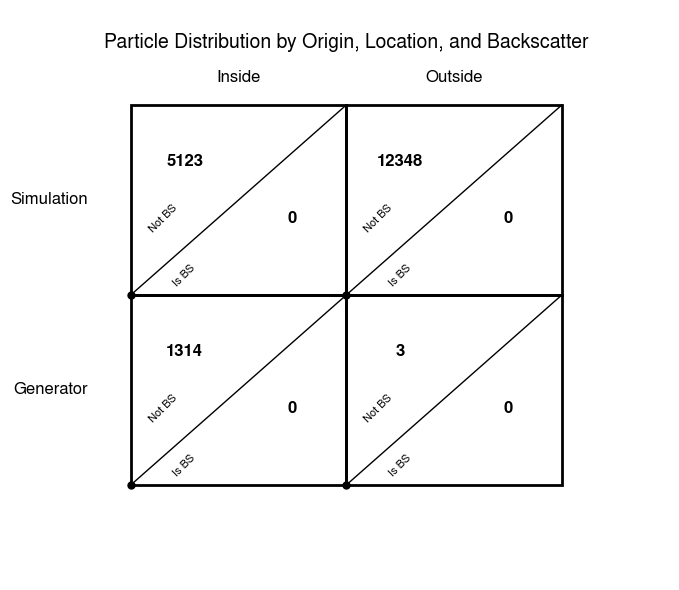

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1314 |          0
Outside   | Generator  |             3 |          0
Inside    | Simulation |          5123 |          0
Outside   | Simulation |         12348 |          0

Totals by Category:
Total particles: 18788
From Generator: 1317
From Simulation: 17471
Inside Tracker: 6437
Outside Tracker: 12351
Backscatter: 0


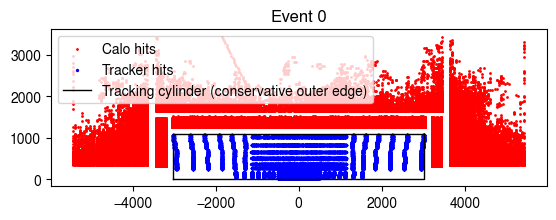

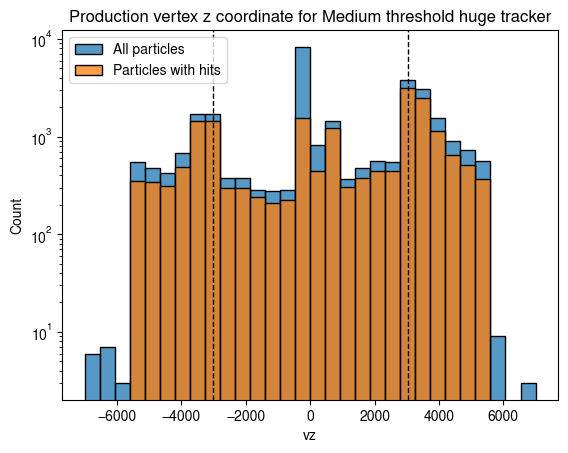

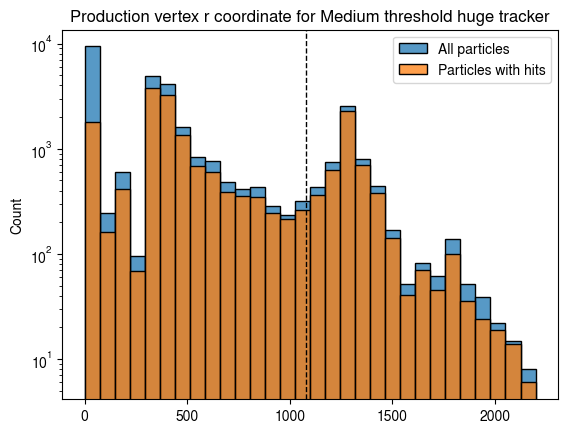

In [73]:
edm4hep_file = f"{base_dir}/medium_threshold_huge_tracker/edm4hep.root"
huge_tracker_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Medium threshold huge tracker", detector_params=detector_params)

This is with both the TC truth handler turned on, and a realistic tracker size.

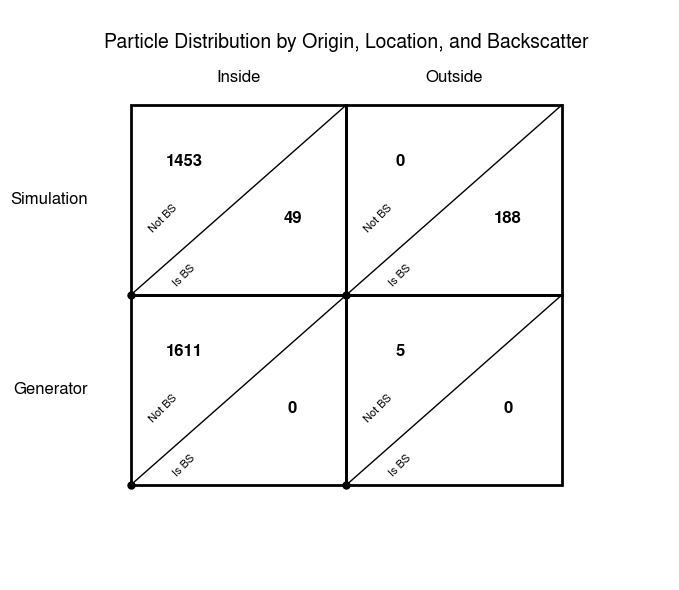

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1611 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |          1453 |         49
Outside   | Simulation |             0 |        188

Totals by Category:
Total particles: 3306
From Generator: 1616
From Simulation: 1690
Inside Tracker: 3113
Outside Tracker: 193
Backscatter: 237


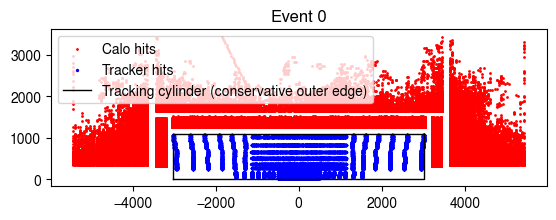

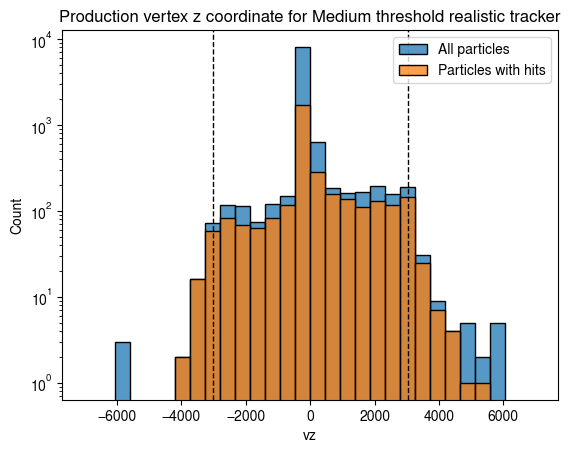

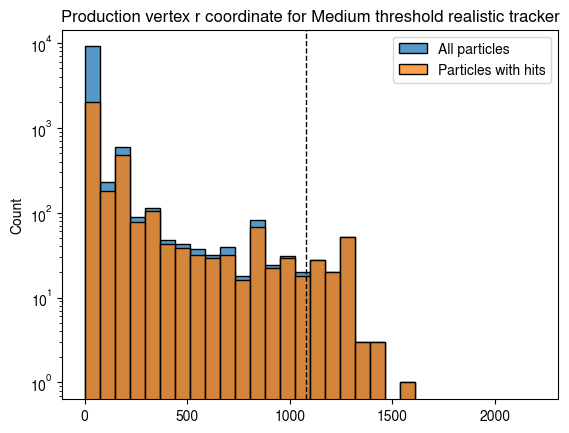

In [74]:
edm4hep_file = f"{base_dir}/medium_threshold_realistic_tracker/edm4hep.root"
event = event_diagnostics(edm4hep_file, event_num=event_num, label="Medium threshold realistic tracker", detector_params=detector_params)

## Postprocessed Version

In [75]:
unprocessed_event = huge_tracker_event.copy()

In [76]:
full_particles_df, full_daughters_df, full_parents_df = unprocessed_event["particles_df"], unprocessed_event["daughters_df"], unprocessed_event["parents_df"]
full_tracker_df, full_calo_hit_df, full_calo_contrib_df = unprocessed_event["tracker_df"], unprocessed_event["calo_hits_df"], unprocessed_event["calo_contrib_df"]

In [77]:
particles_df, daughters_df, parents_df = event["particles_df"], event["daughters_df"], event["parents_df"]
tracker_df, calo_hit_df, calo_contrib_df = event["tracker_df"], event["calo_hits_df"], event["calo_contrib_df"]

In [78]:
particles_with_hits = np.concatenate([full_calo_contrib_df.particle_id.unique(), full_tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits = full_particles_df.loc[particles_with_hits]
print(len(particles_with_hits))

18788


In [79]:
%%time
G = build_decay_tree(full_particles_df, full_daughters_df)
print(f"Built graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Creating nodes...
Created 49857 edges
Built graph with 30397 nodes and 49857 edges
CPU times: user 222 ms, sys: 23.1 ms, total: 246 ms
Wall time: 250 ms


In [105]:
%%time
skimmed_G = build_decay_tree(particles_df, daughters_df)
print(f"Built graph with {skimmed_G.number_of_nodes()} nodes and {skimmed_G.number_of_edges()} edges")

Creating nodes...
Created 30023 edges
Built graph with 10563 nodes and 30023 edges
CPU times: user 84.2 ms, sys: 36.4 ms, total: 121 ms
Wall time: 120 ms


In [80]:
%%time
processed_G = process_decay_tree(G, detector_params)

Finding root nodes...
Found 22 root nodes
Processing nodes in topological order...


100%|██████████| 30397/30397 [00:00<00:00, 92483.51it/s]

CPU times: user 320 ms, sys: 6.84 ms, total: 326 ms
Wall time: 335 ms


In [81]:
%%time
# Convert the graph nodes to a pandas dataframe
node_df = pd.DataFrame.from_dict(dict(processed_G.nodes(data=True)), orient="index")

CPU times: user 72.9 ms, sys: 4.76 ms, total: 77.7 ms
Wall time: 79.3 ms


In [82]:
node_df

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID
0,6999.999937,0.000000,0.000000,0.000000,0,0,0
1,2607.457556,0.003543,-0.005813,-105.372111,1,1,1
2,376.885189,0.003543,-0.005813,-105.372111,2,2,2
3,267.841489,0.003543,-0.005813,-105.372111,3,3,3
4,155.382063,0.003543,-0.005813,-105.372111,4,4,4
...,...,...,...,...,...,...,...
30392,0.184257,-256.810462,1259.268982,2897.654381,30392,30392,1773
30393,0.143103,-256.810462,1259.268982,2897.654381,30393,30393,1773
30394,0.164575,-256.981303,1261.157314,2902.621089,30394,30394,1773
30395,0.149162,-256.992234,1263.273587,2908.342965,30395,30395,1773


In [83]:
node_df[node_df.particleID != node_df.collapsedParticleID]

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID
1370,0.061046,-1057.864047,753.35696,1686.353161,1370,1249,1249


In [84]:
print(f"""
{(node_df.collapsedParticleID == node_df.particleID).all()}
If true, then indeed the energy threshold of the postprocessing matches that of the simulation
""")



False
If true, then indeed the energy threshold of the postprocessing matches that of the simulation



Now... We need:
- Merge event and processed_event particle lists (get Venn diagram)
- Map trimmed Ids to processed_event incidentParentIds
- Look at hit Ids in tracker
- Look at hit Ids in calo contributions
- Venn diagram of each

In [85]:
full_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30392,11,0,1224736768,-1.000000,18.987364,0.000511,-256.810462,1259.268982,2897.654381,-0.014434,...,1259.642684,2913.530223,49852,49853,49855,49856,0.072863,0.184257,1.579285,1.770208
30393,-11,0,1224736768,1.000000,18.987364,0.000511,-256.810462,1259.268982,2897.654381,-0.011995,...,1260.790231,2910.989339,49853,49854,49856,49856,0.055590,0.143103,1.598637,1.788277
30394,22,0,1493172224,0.000000,19.005100,0.000000,-256.981303,1261.157314,2902.621089,-0.000295,...,1263.273587,2908.342965,49854,49855,49856,49857,0.057090,0.164575,1.720342,1.575962
30395,-11,0,1224736768,1.000000,19.025450,0.000511,-256.992234,1263.273587,2908.342965,-0.000120,...,1270.008773,2933.174926,49855,49856,49857,49857,0.052210,0.149162,1.710773,1.573097


In [86]:
particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10558,11,0,1157627904,-1.000000,9.625705,0.000511,-26.683532,169.692869,321.268177,-0.113812,...,989.223140,3215.626910,30018,30019,30021,30022,0.733771,1.964268,1.640957,1.726531
10559,-11,0,1157627904,1.000000,9.625705,0.000511,-26.683532,169.692869,321.268177,-0.052301,...,749.550259,3220.364346,30019,30020,30022,30022,0.333114,0.892749,1.642188,1.728456
10560,22,0,1426063360,0.000000,13.125437,0.000000,-147.006679,540.895008,1294.536630,-0.103569,...,1095.819261,2844.425126,30020,30021,30022,30023,0.228714,0.613751,1.643585,2.040738
10561,11,0,2030043136,-1.000000,19.328438,0.000511,-454.786562,1165.726570,3018.535546,0.000587,...,907.034224,2643.817965,30021,30022,30023,30023,0.003817,0.012957,1.892916,1.416392


In [87]:
full_to_processed_id_map = dict(zip(node_df.particleID, node_df.incidentParentID))

In [89]:
# Add the index in as particle_id
particles_df["particle_id"] = particles_df.index
full_particles_df["particle_id"] = full_particles_df.index

In [90]:
skimmed_to_full_id_map = particles_df.merge(full_particles_df.drop_duplicates(subset=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"]), on=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"])[["particle_id_x", "particle_id_y"]].rename(columns={"particle_id_x": "particle_id", "particle_id_y": "full_particle_id"})
skimmed_to_full_id_map = dict(zip(skimmed_to_full_id_map.particle_id, skimmed_to_full_id_map.full_particle_id))

In [91]:
# Map processed tracker hits to full tracker hits
full_tracker_df["processed_id"] = full_tracker_df.particle_id.map(full_to_processed_id_map)

In [92]:
full_tracker_df["skimmed_id"] = tracker_df.particle_id.map(skimmed_to_full_id_map)

In [102]:
full_calo_contrib_df["processed_id"] = full_calo_contrib_df.particle_id.map(full_to_processed_id_map)
full_calo_contrib_df["skimmed_id"] = full_calo_contrib_df.particle_id.map(skimmed_to_full_id_map)

In [93]:
intersection = sum(full_tracker_df.processed_id == full_tracker_df.skimmed_id)
print(f"""
Accuracy of tracker hit mapping: {intersection/len(full_tracker_df)}
Accuracy (removing nans): {sum(full_tracker_df.processed_id[full_tracker_df.skimmed_id.notna()] == full_tracker_df.skimmed_id[full_tracker_df.skimmed_id.notna()])/len(full_tracker_df[full_tracker_df.skimmed_id.notna()])}
""")


Accuracy of tracker hit mapping: 0.9336055305525913
Accuracy (removing nans): 0.9644825768106217



In [103]:
intersection = sum(full_calo_contrib_df.processed_id == full_calo_contrib_df.skimmed_id)
print(f"""
Accuracy of calo contrib mapping: {intersection/len(full_calo_contrib_df)}
Accuracy (removing nans): {sum(full_calo_contrib_df.processed_id[full_calo_contrib_df.skimmed_id.notna()] == full_calo_contrib_df.skimmed_id[full_calo_contrib_df.skimmed_id.notna()])/len(full_calo_contrib_df[full_calo_contrib_df.skimmed_id.notna()])}
""")


Accuracy of calo contrib mapping: 0.09793590884861765
Accuracy (removing nans): 0.5533798649571353



### Pick Sample Issue

In [94]:
full_tracker_df[full_tracker_df.processed_id != full_tracker_df.skimmed_id]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
552,12350234294822182,148.712708,0.101626,1073741824,-21.534116,-111.558619,216.371585,-0.012387,-0.009709,-0.003543,...,7244,113.617972,244.388433,-1.761481,0.483530,1.400036,0.015738,PixelBarrelReadout,7244,NaN
579,10151284053772294,-2.627604,1.120210,0,-31.389120,-6.616740,282.606544,-0.709885,-0.138601,6.428625,...,7785,32.078935,284.421372,-2.933837,0.113027,2.872209,0.723289,PixelBarrelReadout,7537,7785.0
580,61185107667126534,-2.584414,1.178199,0,-32.790967,-6.891852,295.311516,-0.709537,-0.139762,6.427799,...,7785,33.507390,297.206388,-2.934433,0.112981,2.872615,0.723171,PixelBarrelReadout,7537,7785.0
657,5295750510936326,-3.469396,0.145143,0,26.968872,17.234747,-21.197205,0.417272,0.278389,-0.292564,...,7778,32.005571,38.388515,0.568647,2.155768,-0.621506,0.501614,PixelBarrelReadout,7537,7778.0
658,4942798688485894,-3.462085,0.152146,0,28.495906,18.257832,-22.268789,0.416706,0.279171,-0.292415,...,7778,33.843243,40.512518,0.569822,2.152774,-0.617918,0.501578,PixelBarrelReadout,7537,7778.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21511,17076791075150,22.577486,0.436168,0,-227.381587,914.216530,2620.500000,-0.039647,-0.224271,-0.161023,...,30055,942.069132,2784.692891,1.814568,0.345113,1.747037,0.227749,LongStripEndcapReadout,29919,30055.0
21512,16630113443902,31.272888,0.421721,0,-612.505381,657.814807,2245.500000,-0.180357,0.043959,-0.134087,...,30055,898.823210,2418.709038,2.320542,0.380746,1.646587,0.185637,LongStripEndcapReadout,29919,30055.0
21549,15749646188894,20.597553,0.124870,1073741824,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,...,30332,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout,30322,NaN
21550,16333760692558,22.928253,0.125527,1073741824,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,...,30332,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout,30322,NaN


#### Particle 7244, hit 552: Skimmed particle not in full event

In [120]:
full_tracker_df[full_tracker_df.particle_id == 7244]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
548,68398445110951942,-3.452035,0.167514,0,32.175966,0.091193,25.828119,0.773505,0.011725,0.682427,...,7244,32.176095,41.260064,0.002834,0.894404,0.734784,0.773594,PixelBarrelReadout,7244,7244.0
549,7511992290443286,-3.290689,0.167435,0,68.035659,1.254802,57.611820,0.770547,0.036018,0.683539,...,7244,68.047229,89.160233,0.018441,0.868253,0.768679,0.771388,PixelBarrelReadout,7244,7244.0
550,68310840663080998,-3.085041,0.167075,0,113.681392,4.192837,98.108907,0.768690,0.063213,0.682396,...,7244,113.758687,150.221159,0.036866,0.859130,0.780679,0.771285,PixelBarrelReadout,7244,7244.0
551,60534424416616758,-2.829100,0.167216,0,170.345711,10.198739,148.441685,0.764359,0.098234,0.680590,...,7244,170.650741,226.178269,0.059799,0.854887,0.786293,0.770645,PixelBarrelReadout,7244,7244.0
552,12350234294822182,148.712708,0.101626,1073741824,-21.534116,-111.558619,216.371585,-0.012387,-0.009709,-0.003543,...,7244,113.617972,244.388433,-1.761481,0.483530,1.400036,0.015738,PixelBarrelReadout,7244,NaN
8324,333310937792777,-2.434792,0.271629,0,256.915407,24.226264,225.990696,0.754689,0.145992,0.678952,...,7244,258.055107,343.022204,0.094019,0.851544,0.790730,0.768681,ShortStripBarrelReadout,7244,7244.0
8325,71776565738668313,-1.968193,0.279828,0,358.029879,48.067583,317.704407,0.740880,0.207925,0.676505,...,7244,361.242145,481.073775,0.133458,0.849436,0.793535,0.769504,ShortStripBarrelReadout,7244,7244.0
8326,335063284580905,-1.326649,0.287030,0,493.367433,94.402767,443.520193,0.710858,0.291509,0.676447,...,7244,502.317933,670.099595,0.189059,0.847483,0.796138,0.768308,ShortStripBarrelReadout,7244,7244.0
8327,1548382955832377,-0.596858,0.291779,0,639.614648,165.650416,586.671572,0.668027,0.379689,0.674669,...,7244,660.717003,883.589549,0.253417,0.844689,0.799870,0.768390,ShortStripBarrelReadout,7244,7244.0
16847,71723381158904588,0.136110,0.375913,0,776.186351,255.355219,730.365414,0.613511,0.462101,0.674820,...,7244,817.111706,1095.949441,0.317834,0.841396,0.804280,0.768071,LongStripBarrelReadout,7244,7244.0


In [130]:
full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244]

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector,processed_id,skimmed_id
9849,0,0.000060,1605.156128,0.0,0.0,0.0,7244,2283,-1262.500000,-81.599998,1351.500000,ECalBarrelCollection,7244,7244.0
9850,0,0.000035,1597.757935,0.0,0.0,0.0,7244,2284,112.199997,-1262.500000,2641.800049,ECalBarrelCollection,7244,7244.0
9851,0,0.000232,1597.762695,0.0,0.0,0.0,7244,2285,112.199997,-1262.500000,2646.899902,ECalBarrelCollection,7244,7244.0
9852,0,0.000019,1597.762939,0.0,0.0,0.0,7244,2285,112.199997,-1262.500000,2646.899902,ECalBarrelCollection,7244,7244.0
9853,0,0.000048,5082.255859,0.0,0.0,0.0,7244,2286,1313.000000,-112.199997,1428.000000,ECalBarrelCollection,7244,7244.0
9854,0,0.000011,5082.255859,0.0,0.0,0.0,7244,2286,1313.000000,-112.199997,1428.000000,ECalBarrelCollection,7244,7244.0
9855,0,0.000109,5082.256348,0.0,0.0,0.0,7244,2286,1313.000000,-112.199997,1428.000000,ECalBarrelCollection,7244,7244.0
9856,0,0.000015,5082.256348,0.0,0.0,0.0,7244,2286,1313.000000,-112.199997,1428.000000,ECalBarrelCollection,7244,7244.0
9857,0,0.000015,5082.256348,0.0,0.0,0.0,7244,2286,1313.000000,-112.199997,1428.000000,ECalBarrelCollection,7244,7244.0
9858,0,0.000014,5082.259277,0.0,0.0,0.0,7244,2286,1313.000000,-112.199997,1428.000000,ECalBarrelCollection,7244,7244.0


In [129]:
full_tracker_df[full_tracker_df.particle_id == 7244].time

548        -3.452035
549        -3.290689
550        -3.085041
551        -2.829100
552       148.712708
8324       -2.434792
8325       -1.968193
8326       -1.326649
8327       -0.596858
16847       0.136110
16848       0.169570
16849       1.101802
16850       1.136993
16851    5094.410645
Name: time, dtype: float32

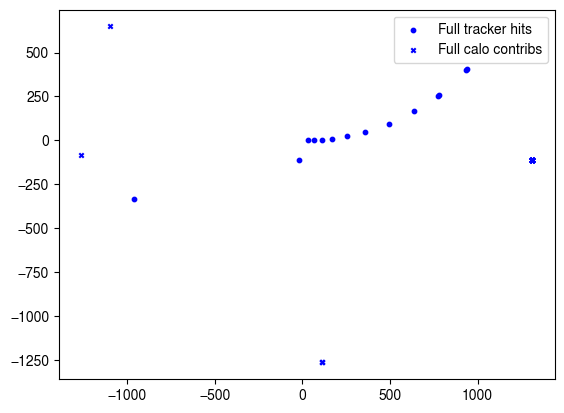

In [131]:
plt.scatter(full_tracker_df[full_tracker_df.particle_id == 7244].x, full_tracker_df[full_tracker_df.particle_id == 7244].y, c="blue", s=10, label="Full tracker hits")
plt.scatter(full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244].x, full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244].y, c="blue", marker="x", s=10, label="Full calo contribs")
# plt.scatter(full_tracker_df[tracker_df.particle_id == 8749].x, full_tracker_df[tracker_df.particle_id == 8749].y, c="red", s=1, label="Skimmed tracker hits")
plt.legend()
plt.show()

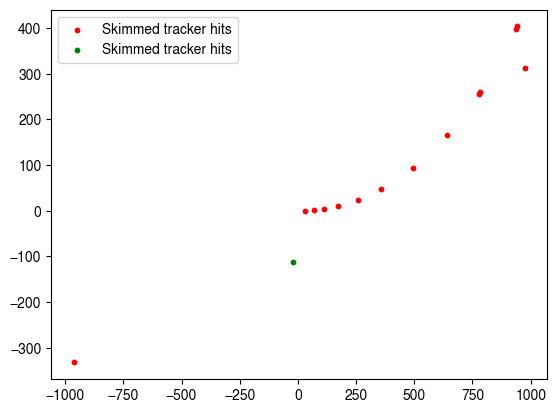

In [119]:
plt.scatter(full_tracker_df[tracker_df.particle_id == 7244].x, full_tracker_df[tracker_df.particle_id == 7244].y, c="red", s=10, label="Skimmed tracker hits")
plt.scatter(full_tracker_df[tracker_df.particle_id == 8749].x, full_tracker_df[tracker_df.particle_id == 8749].y, c="green", s=10, label="Skimmed tracker hits")
plt.legend()
plt.show()

In [101]:
tracker_df.loc[552].particle_id, full_tracker_df.loc[552].particle_id

(np.int32(8749), np.int32(7244))

In [109]:
skimmed_to_full_id_map[8749]

KeyError: 8749

In [121]:
full_ancestors = list(nx.ancestors(G, 7244))
full_descendants = list(nx.descendants(G, 7244))
skimmed_ancestors = list(nx.ancestors(skimmed_G, 8749))
skimmed_descendants = list(nx.descendants(skimmed_G, 8749))

In [107]:
full_ancestors

[np.int64(6918),
 np.int64(6919),
 np.int64(6927),
 np.int64(6930),
 np.int64(6932),
 np.int64(6933),
 np.int64(6947),
 np.int64(6955),
 np.int64(6958),
 np.int64(6960),
 np.int64(6974),
 np.int64(6984),
 np.int64(6989),
 np.int64(6990),
 np.int64(6992),
 np.int64(6993),
 np.int64(6995),
 np.int64(6996),
 np.int64(6998),
 np.int64(7000),
 np.int64(7001),
 np.int64(7002),
 np.int64(7003),
 np.int64(7004),
 np.int64(7005),
 np.int64(7006),
 np.int64(7007),
 np.int64(7008),
 np.int64(7009),
 np.int64(7010),
 np.int64(7011),
 np.int64(7012),
 np.int64(7013),
 np.int64(7014),
 np.int64(7015),
 np.int64(7016),
 np.int64(7017),
 np.int64(7018),
 np.int64(7019),
 np.int64(7020),
 np.int64(7021),
 np.int64(7022),
 np.int64(7027)]

In [108]:
skimmed_ancestors

[np.int64(6918),
 np.int64(6919),
 np.int64(6927),
 np.int64(6930),
 np.int64(6932),
 np.int64(6933),
 np.int64(6947),
 np.int64(6955),
 np.int64(6958),
 np.int64(6960),
 np.int64(6974),
 np.int64(6984),
 np.int64(7244),
 np.int64(6989),
 np.int64(6990),
 np.int64(6992),
 np.int64(6993),
 np.int64(6995),
 np.int64(6996),
 np.int64(6998),
 np.int64(7000),
 np.int64(7001),
 np.int64(7002),
 np.int64(7003),
 np.int64(7004),
 np.int64(7005),
 np.int64(7006),
 np.int64(7007),
 np.int64(7008),
 np.int64(7009),
 np.int64(7010),
 np.int64(7011),
 np.int64(7012),
 np.int64(7013),
 np.int64(7014),
 np.int64(7015),
 np.int64(7016),
 np.int64(7017),
 np.int64(7018),
 np.int64(7019),
 np.int64(7020),
 np.int64(7021),
 np.int64(7022),
 np.int64(7027)]

In [122]:
full_descendants

[np.int64(10452),
 np.int64(10453),
 np.int64(10454),
 np.int64(10455),
 np.int64(10456)]

In [124]:
full_particles_df.iloc[10452:10457]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi,particle_id
10452,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,0.446525,...,1221.201398,29912,29913,33489,33490,0.689975,0.831864,0.630807,0.866941,10452
10453,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,-0.379689,...,2195.945842,29913,29914,33490,33490,0.468677,0.633692,0.816296,2.515170,10453
10454,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,0.435368,...,1016.248028,29914,29915,33490,33490,0.514944,0.522165,-0.167270,-0.563359,10454
10455,2112,0,1224736768,0.0,3.205688,0.939565,1189.700345,688.873067,1221.201398,-0.092400,...,1233.959549,29915,29916,33490,33491,0.479266,0.556852,0.561597,1.764806,10455
10456,2112,0,1224736768,0.0,3.369621,0.939565,1185.542528,710.034446,1233.959549,-0.201264,...,1370.470362,29916,29917,33491,33491,0.202826,0.475478,1.496167,3.017401,10456


In [123]:
skimmed_descendants

[]

In [125]:
list(nx.descendants(skimmed_G, 7244))

[np.int64(8749)]

In [126]:
particles_df.loc[7244]

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    8.388608e+07
charge            -1.000000e+00
time              -3.596635e+00
mass               1.395700e-01
vx                 2.814718e-02
vy                 3.564536e-03
vz                -2.539741e+00
px                 7.736642e-01
py                -7.548373e-03
pz                 6.827099e-01
endpoint_x         1.042386e+03
endpoint_y         5.216395e+02
endpoint_z         1.062809e+03
parents_begin      2.374600e+04
parents_end        2.374700e+04
daughters_begin    2.478300e+04
daughters_end      2.478400e+04
pt                 7.737010e-01
p                  1.031846e+00
eta                7.957238e-01
phi               -9.756344e-03
particle_id        7.244000e+03
Name: 7244, dtype: float64

In [128]:
daughters_df.iloc[24783]

particle_id           8749
collectionID    2714477136
parent_id             7244
Name: 24783, dtype: int64

In [98]:
particles_df.loc[8749]

PDG                2.112000e+03
generatorStatus    0.000000e+00
simulatorStatus    2.013266e+09
charge             0.000000e+00
time               2.519624e+00
mass               9.395654e-01
vx                 1.052720e+03
vy                 5.229406e+02
vz                 1.070684e+03
px                -2.867418e-02
py                 7.706964e-03
pz                -4.261910e-02
endpoint_x        -4.706979e+02
endpoint_y         6.591991e+02
endpoint_z         4.823788e+02
parents_begin      2.820900e+04
parents_end        2.821000e+04
daughters_begin    2.915600e+04
daughters_end      2.915600e+04
pt                 2.969185e-02
p                  5.194222e-02
eta               -1.158376e+00
phi                2.879021e+00
particle_id        8.749000e+03
Name: 8749, dtype: float64

In [110]:
particles_df.loc[7244]

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    8.388608e+07
charge            -1.000000e+00
time              -3.596635e+00
mass               1.395700e-01
vx                 2.814718e-02
vy                 3.564536e-03
vz                -2.539741e+00
px                 7.736642e-01
py                -7.548373e-03
pz                 6.827099e-01
endpoint_x         1.042386e+03
endpoint_y         5.216395e+02
endpoint_z         1.062809e+03
parents_begin      2.374600e+04
parents_end        2.374700e+04
daughters_begin    2.478300e+04
daughters_end      2.478400e+04
pt                 7.737010e-01
p                  1.031846e+00
eta                7.957238e-01
phi               -9.756344e-03
particle_id        7.244000e+03
Name: 7244, dtype: float64

In [99]:
full_particles_df.loc[7244]

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    1.509949e+08
charge            -1.000000e+00
time              -3.596635e+00
mass               1.395700e-01
vx                 2.814718e-02
vy                 3.564536e-03
vz                -2.539741e+00
px                 7.736642e-01
py                -7.548373e-03
pz                 6.827099e-01
endpoint_x         1.042386e+03
endpoint_y         5.216395e+02
endpoint_z         1.062809e+03
parents_begin      2.374600e+04
parents_end        2.374700e+04
daughters_begin    2.724700e+04
daughters_end      2.725000e+04
pt                 7.737010e-01
p                  1.031846e+00
eta                7.957238e-01
phi               -9.756344e-03
particle_id        7.244000e+03
Name: 7244, dtype: float64

In [111]:
skimmed_to_full_id_map[7244]

7244

In [95]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,...,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout,8352,8352.0
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,...,8468,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout,8468,8468.0
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,...,8467,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout,8467,8467.0
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,...,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout,8350,8350.0
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,...,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout,8347,8347.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,1073741824,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,...,30324,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout,30313,30313.0
21549,15749646188894,20.597553,0.124870,1073741824,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,...,30332,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout,30322,NaN
21550,16333760692558,22.928253,0.125527,1073741824,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,...,30332,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout,30322,NaN
21551,1554779373662,26.342630,0.032734,1073741824,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,...,30335,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout,30322,30322.0


Directories:
- low_threshold_realistic_tracker: energy threshold of 1 keV, tracker size of 1080 mm x 3030mm
- low_threshold_huge_tracker: energy threshold of 1 keV, tracker size of 10000 mm x 10000 mm

# 1keV Threshold

In [3]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.000001     # in GeV
}

In [4]:
base_dir = "/global/cfs/cdirs/m4958/data/ColliderML/outputs/decay_testing/low_pileup/"
event_num = 0

This is with the TC truth handler turned on, but with a tracker the size of the world volume. That is, we should see energy threshold effects, but not calorimeter decay collapse effects.

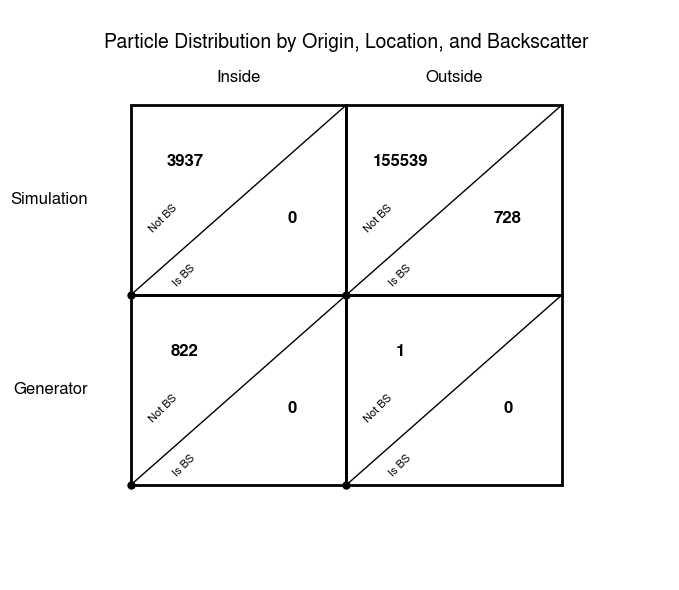

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |           822 |          0
Outside   | Generator  |             1 |          0
Inside    | Simulation |          3937 |          0
Outside   | Simulation |        155539 |        728

Totals by Category:
PARTICLES WITH HITS
Total particles: 161027
From Generator: 823
From Simulation: 160204
Inside Tracker: 4759
Outside Tracker: 156268
Backscatter: 728

ALL PARTICLES
Total particles: 4433848
From Generator: 8448
From Simulation: 4425400
Inside Tracker: 168218
Outside Tracker: 4265630


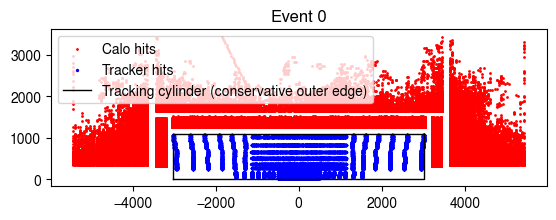

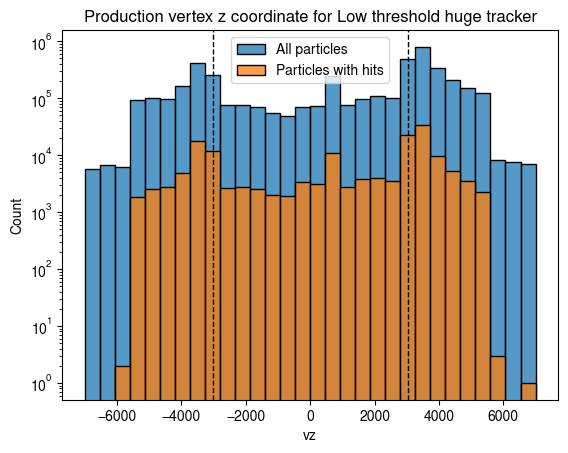

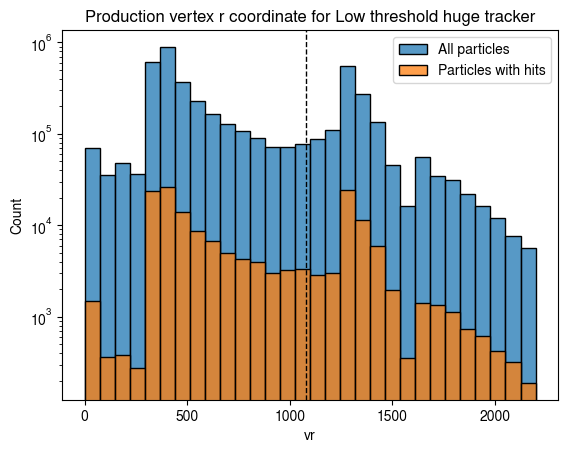

In [9]:
edm4hep_file = f"{base_dir}/low_threshold_huge_tracker/edm4hep.root"
huge_tracker_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold huge tracker", detector_params=detector_params)

This is with both the TC truth handler turned on, and a realistic tracker size.

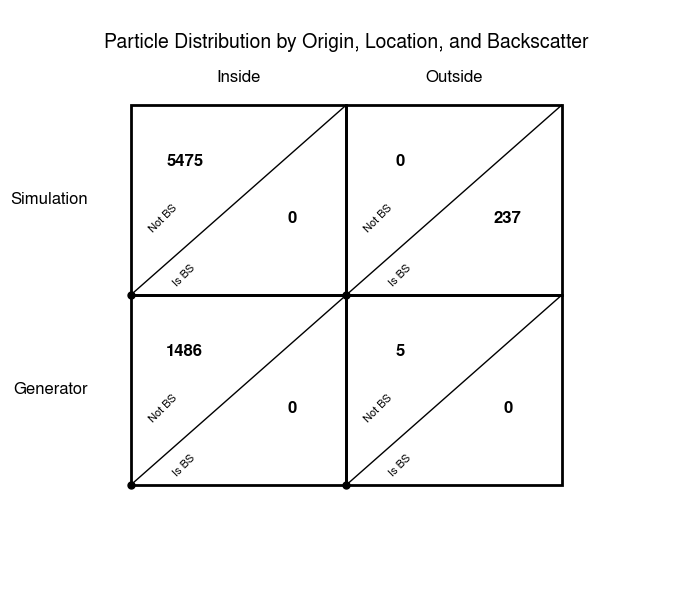

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |          1486 |          0
Outside   | Generator  |             5 |          0
Inside    | Simulation |          5475 |          0
Outside   | Simulation |             0 |        237

Totals by Category:
PARTICLES WITH HITS
Total particles: 7203
From Generator: 1491
From Simulation: 5712
Inside Tracker: 6961
Outside Tracker: 242
Backscatter: 237

ALL PARTICLES
Total particles: 168525
From Generator: 8448
From Simulation: 160077
Inside Tracker: 168218
Outside Tracker: 307


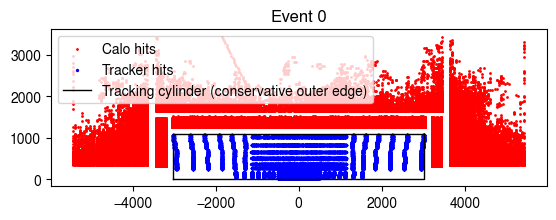

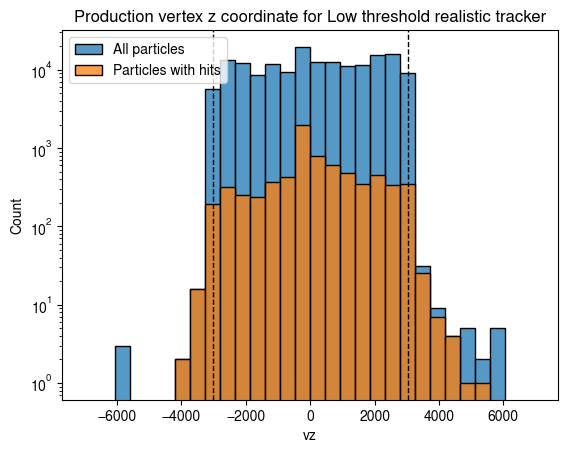

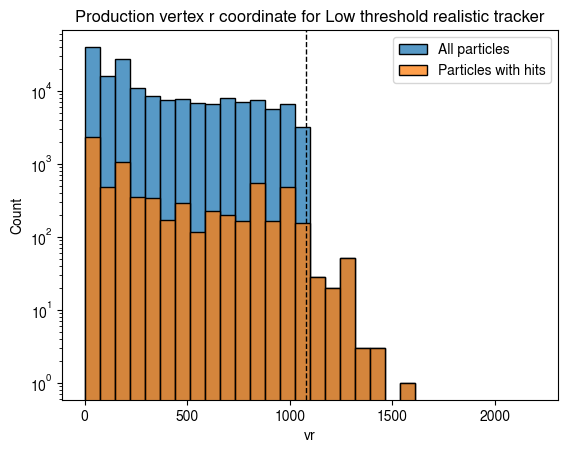

In [8]:
edm4hep_file = f"{base_dir}/low_threshold_realistic_tracker/edm4hep.root"
event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold realistic tracker", detector_params=detector_params)

## Some Questions...

1. Are there virtual particles in the tracker between, e.g. a primary, and a decay product that leaves a hit?

In [10]:
# Want to get a particle that starts and ends in the tracker, which doesn't leave a hit, but has a decay product that does.

In [13]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,0.000621,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,0.000209,11871,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,0.000167,11870,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,0.000387,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,0.000236,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,0,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,0.000069,4420523,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout
21549,15749646188894,20.597553,0.124870,0,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,0.000041,4420748,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout
21550,16333760692558,22.928253,0.125527,0,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,0.000149,4420748,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout
21551,1554779373662,26.342630,0.032734,0,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,0.000058,4421240,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout


In [17]:
full_particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'vr', 'endpoint_r',
       'created_in_simulation', 'created_inside_tracker',
       'ended_inside_tracker', 'backscatter', 'left_tracker_hit'],
      dtype='object')

In [15]:
full_particles_df["left_tracker_hit"] = full_particles_df.index.isin(full_tracker_df.particle_id)

In [23]:
particles_without_hit_with_daughters_mask = ~full_particles_df.left_tracker_hit & (full_particles_df.daughters_begin != full_particles_df.daughters_end) & full_particles_df.created_inside_tracker & full_particles_df.ended_inside_tracker
particles_without_hit_with_daughters = full_particles_df[particles_without_hit_with_daughters_mask]

In [24]:
particles_without_hit_with_daughters

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter,left_tracker_hit
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,6999.999937,inf,0.000000,0.000000,0.006807,0,1,1,False,False
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,2607.457556,7.572637,-0.084146,0.006807,0.006807,0,1,1,False,False
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,376.885189,7.320521,-1.804631,0.006807,0.006807,0,1,1,False,False
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,267.841489,5.740426,-1.800382,0.006807,0.006807,0,1,1,False,False
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,155.382063,4.531422,0.143721,0.006807,0.006807,0,1,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4418820,11,0,1493172224,-1.000000,11.084579,0.000511,-62.257651,328.841160,727.038321,-0.000802,...,0.001803,1.294607,-2.631118,334.682721,334.322265,1,1,1,False,False
4418824,11,0,1493172224,-1.000000,12.360787,0.000511,-110.987173,463.293311,1081.869257,0.000015,...,0.000099,-0.233530,1.417352,476.401978,476.497433,1,1,1,False,False
4418828,11,0,1493172224,-1.000000,13.297421,0.000511,-155.822986,557.987815,1342.374586,-0.000048,...,0.000082,0.257100,-2.214237,579.336866,579.151288,1,1,1,False,False
4420910,11,0,1493172224,-1.000000,23.442286,0.000511,-452.661192,909.383341,2682.700587,0.000087,...,0.000105,0.425643,-0.429950,1015.815049,1015.764855,1,1,1,False,False


In [59]:
# sample = 4

for sample in particles_without_hit_with_daughters.index:
    daughters_indices = full_daughters_df[full_particles_df.loc[sample].daughters_begin:full_particles_df.loc[sample].daughters_end]
    daughters = full_particles_df.loc[daughters_indices.particle_id]
    
    parents_indices = full_parents_df[full_particles_df.loc[sample].parents_begin:full_particles_df.loc[sample].parents_end]
    parents = full_particles_df.loc[parents_indices.particle_id]
    
    # if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0:
    #     break

    if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0 and parents.left_tracker_hit.any():
        print("Found one!")
        break

Found one!


In [60]:
sample

45391

In [61]:
full_particles_df.loc[sample]

PDG                                22
generatorStatus                     0
simulatorStatus            1493172224
charge                            0.0
time                        12.313094
mass                              0.0
vx                        -846.548213
vy                        -306.247474
vz                        1889.617731
px                          -0.000096
py                          -0.000026
pz                           0.000134
endpoint_x                -110.407437
endpoint_y                 174.623777
endpoint_z                  1636.9633
parents_begin                   64851
parents_end                     64852
daughters_begin                153217
daughters_end                  153221
pt                           0.000099
p                            0.000167
eta                          1.109493
phi                         -2.871624
vr                         900.239631
endpoint_r                 206.599288
created_in_simulation               1
created_insi

In [62]:
daughters

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter,left_tracker_hit
45636,11,0,1493172224,-1.0,12.395187,0.000511,-860.656302,-310.151519,1909.402080,-0.000205,...,0.000236,0.482254,-2.906833,914.835087,914.842236,1,1,1,False,True
45637,11,0,1493172224,-1.0,13.088897,0.000511,-663.332557,-269.445030,1960.951589,0.000033,...,0.000089,1.158479,-0.862584,715.968369,715.968346,1,1,1,False,False
45638,11,0,1493172224,-1.0,15.689675,0.000511,-111.131797,175.335553,1636.657297,0.000016,...,0.000140,-0.549036,1.441764,207.588132,207.588300,1,1,1,False,False
45639,11,0,1224736768,-1.0,15.693213,0.000511,-110.407437,174.623777,1636.963300,0.000056,...,0.000296,1.306370,1.189063,206.599288,206.600163,1,1,1,False,False


In [63]:
full_particles_df.loc[32]

PDG                                1
generatorStatus                   41
simulatorStatus                    0
charge                     -0.333333
time                        8.091558
mass                             0.0
vx                          0.003543
vy                         -0.005813
vz                       -105.372111
px                              -0.0
py                               0.0
pz                        155.361861
endpoint_x                  0.003543
endpoint_y                 -0.005813
endpoint_z               -105.372111
parents_begin                     30
parents_end                       31
daughters_begin                   58
daughters_end                     60
pt                               0.0
p                         155.361861
eta                        42.822278
phi                         2.356194
vr                          0.006807
endpoint_r                  0.006807
created_in_simulation              0
created_inside_tracker             1
e

In [64]:
ancestors = list(nx.ancestors(G, sample))
descendants = list(nx.descendants(G, sample))

In [65]:
ancestors

[np.int64(8291),
 np.int64(8294),
 np.int64(44873),
 np.int64(45388),
 np.int64(8366),
 np.int64(45390),
 np.int64(8279),
 np.int64(8312),
 np.int64(8281),
 np.int64(8282),
 np.int64(8280),
 np.int64(8284),
 np.int64(8287),
 np.int64(44895)]

In [66]:
descendants

[np.int64(45636), np.int64(45637), np.int64(45638), np.int64(45639)]

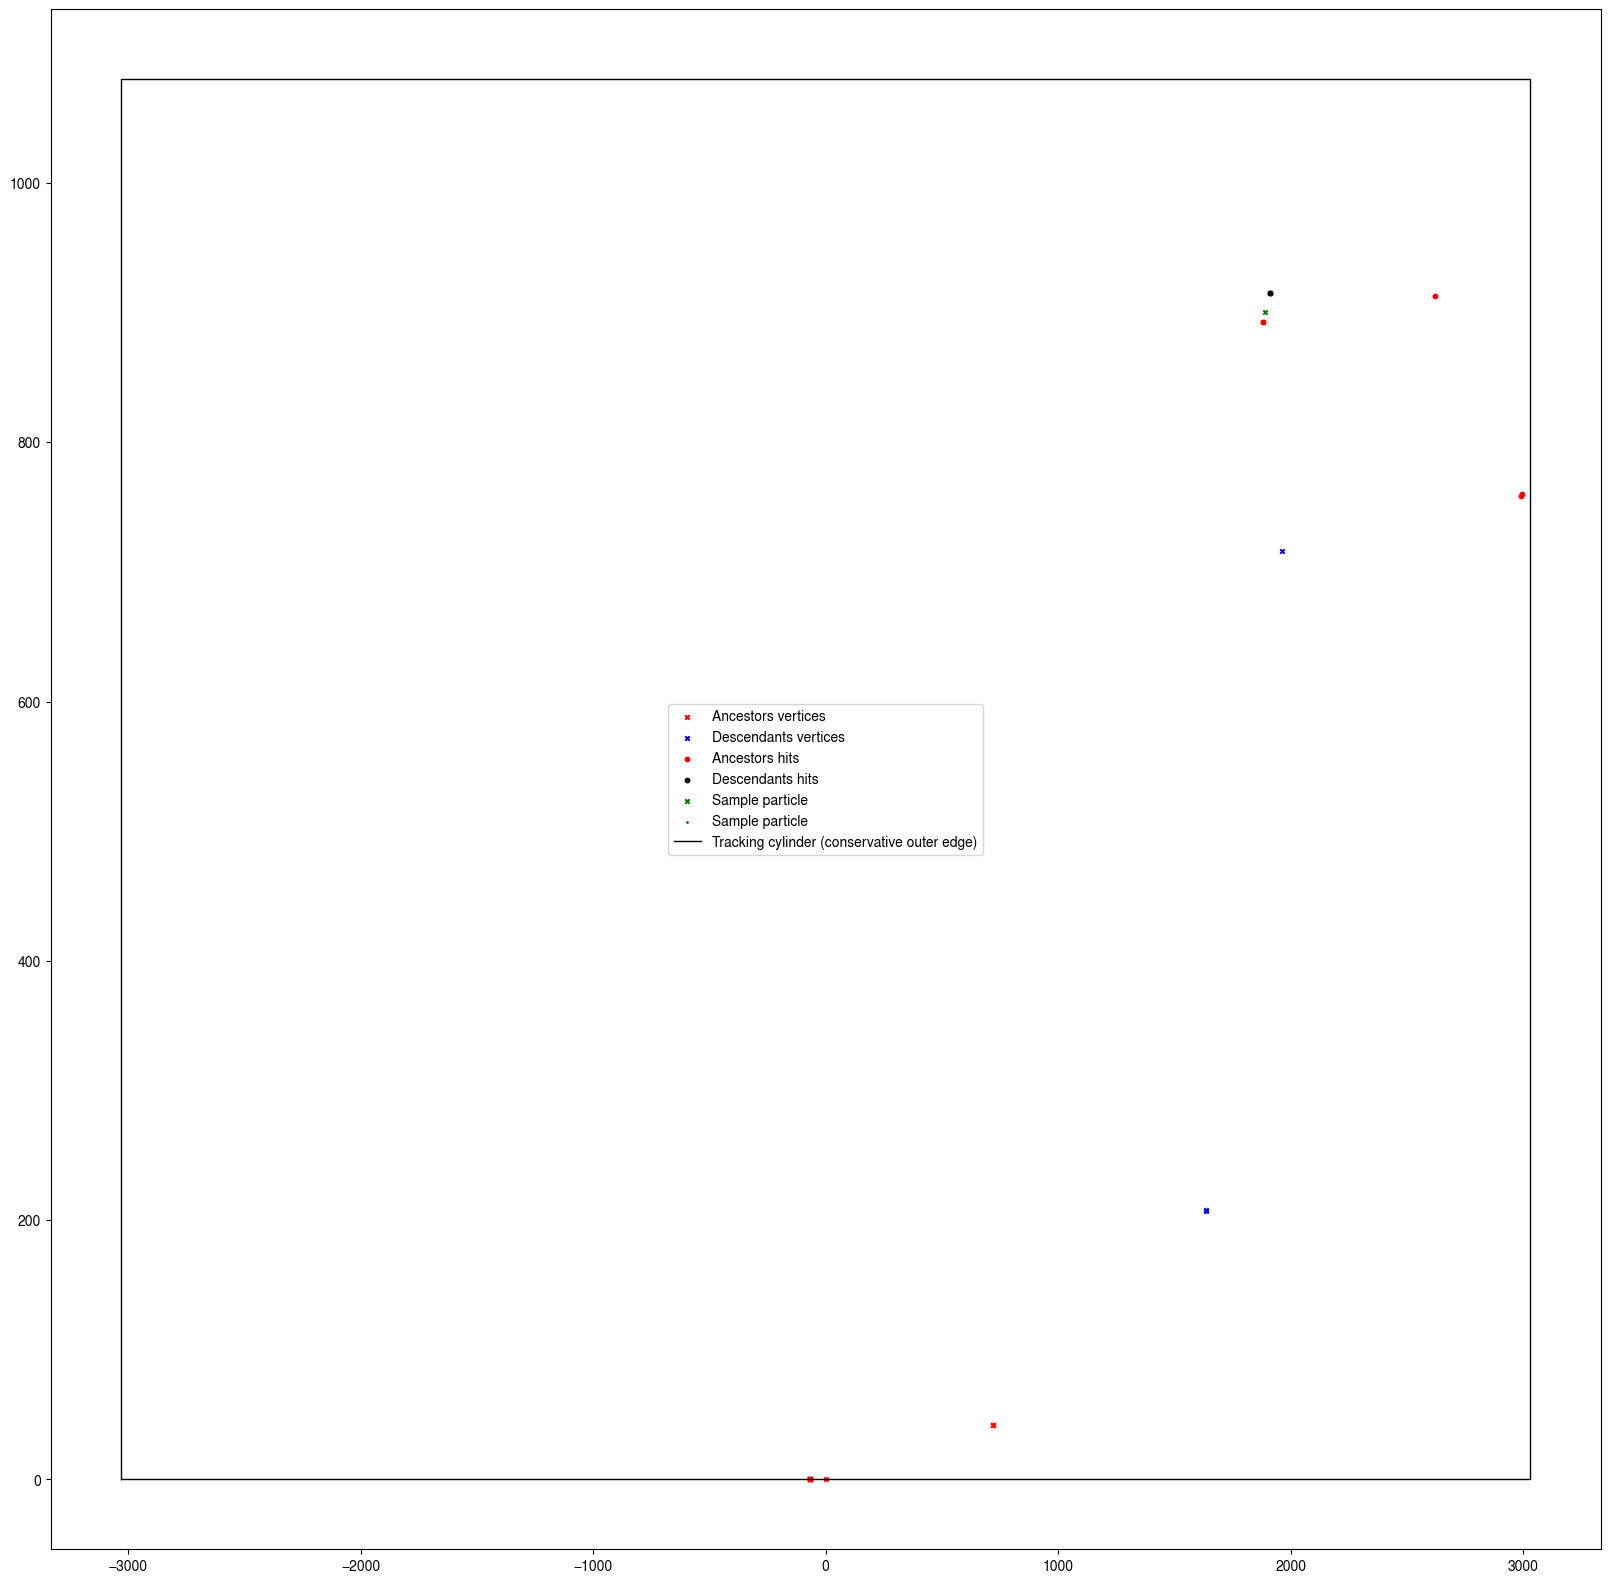

In [68]:
plt.figure(figsize=(20, 20))
plt.scatter(full_particles_df.loc[ancestors].vz, full_particles_df.loc[ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(full_particles_df.loc[descendants].vz, full_particles_df.loc[descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")

plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].z, full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].r, c="red", s=10, label="Ancestors hits")
plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(descendants)].z, full_tracker_df[full_tracker_df.particle_id.isin(descendants)].r, c="black", s=10, label="Descendants hits")

plt.scatter(full_particles_df.loc[sample].vz, full_particles_df.loc[sample].vr, c="green", s=10, marker="x", label="Sample particle")
plt.scatter(full_tracker_df[full_tracker_df.particle_id == sample].z, full_tracker_df[full_tracker_df.particle_id == sample].r, c="green", s=1, label="Sample particle")

# add tracker boundaries
tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']
plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
    

plt.legend()
plt.show()


## Postprocessed Version

In [11]:
unprocessed_event = huge_tracker_event.copy()

In [33]:
full_particles_df, full_daughters_df, full_parents_df = unprocessed_event["particles_df"], unprocessed_event["daughters_df"], unprocessed_event["parents_df"]
full_tracker_df, full_calo_hit_df, full_calo_contrib_df = unprocessed_event["tracker_df"], unprocessed_event["calo_hits_df"], unprocessed_event["calo_contrib_df"]

In [140]:
particles_df, daughters_df, parents_df = event["particles_df"], event["daughters_df"], event["parents_df"]
tracker_df, calo_hit_df, calo_contrib_df = event["tracker_df"], event["calo_hits_df"], event["calo_contrib_df"]

In [141]:
particles_with_hits = np.concatenate([full_calo_contrib_df.particle_id.unique(), full_tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits = full_particles_df.loc[particles_with_hits]
print(len(particles_with_hits))

161027


In [34]:
%%time
G = build_decay_tree(full_particles_df, full_daughters_df)
print(f"Built graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Creating nodes...
Created 4453308 edges
Built graph with 4433848 nodes and 4453308 edges
CPU times: user 33.5 s, sys: 5.62 s, total: 39.1 s
Wall time: 39.1 s


In [143]:
%%time
skimmed_G = build_decay_tree(particles_df, daughters_df)
print(f"Built graph with {skimmed_G.number_of_nodes()} nodes and {skimmed_G.number_of_edges()} edges")

Creating nodes...
Created 187985 edges
Built graph with 168525 nodes and 187985 edges
CPU times: user 947 ms, sys: 48.3 ms, total: 995 ms
Wall time: 994 ms


In [144]:
%%time
processed_G = process_decay_tree(G, detector_params)

Finding root nodes...
Found 22 root nodes
Processing nodes in topological order...


100%|██████████| 4433848/4433848 [03:38<00:00, 20311.13it/s] 

CPU times: user 3min 34s, sys: 4.22 s, total: 3min 39s
Wall time: 3min 38s


In [145]:
%%time
# Convert the graph nodes to a pandas dataframe
node_df = pd.DataFrame.from_dict(dict(processed_G.nodes(data=True)), orient="index")

CPU times: user 11.7 s, sys: 3.14 s, total: 14.9 s
Wall time: 14.9 s


In [146]:
node_df

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID
0,6999.999937,0.000000,0.000000,0.000000,0,0,0
1,2607.457556,0.003543,-0.005813,-105.372111,1,1,1
2,376.885189,0.003543,-0.005813,-105.372111,2,2,2
3,267.841489,0.003543,-0.005813,-105.372111,3,3,3
4,155.382063,0.003543,-0.005813,-105.372111,4,4,4
...,...,...,...,...,...,...,...
4433843,0.000287,-255.871216,1252.989330,2879.464782,4433843,4433843,1773
4433844,0.000220,-255.866251,1253.050537,2879.551732,4433844,4433844,1773
4433845,0.000299,-254.646333,1248.344870,2871.269025,4433845,4433845,1773
4433846,0.001579,-257.298637,1262.368788,2904.671209,4433846,4433846,1773


In [147]:
node_df[node_df.particleID != node_df.collapsedParticleID]

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID


In [148]:
print(f"""
{(node_df.collapsedParticleID == node_df.particleID).all()}
If true, then indeed the energy threshold of the postprocessing matches that of the simulation
""")



True
If true, then indeed the energy threshold of the postprocessing matches that of the simulation



Now... We need:
- Merge event and processed_event particle lists (get Venn diagram)
- Map trimmed Ids to processed_event incidentParentIds
- Look at hit Ids in tracker
- Look at hit Ids in calo contributions
- Venn diagram of each

In [149]:
full_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433843,11,0,1493172224,-1.000000,18.925810,0.000511,-255.871216,1252.989330,2879.464782,0.000008,...,1252.988631,2879.464389,4453303,4453304,4453308,4453308,0.000250,0.000287,-0.536763,-1.538830
4433844,11,0,1224736768,-1.000000,18.926165,0.000511,-255.866251,1253.050537,2879.551732,0.000016,...,1253.050413,2879.552078,4453304,4453305,4453308,4453308,0.000076,0.000220,1.726098,-1.358289
4433845,11,0,1224736768,-1.000000,18.891832,0.000511,-254.646333,1248.344870,2871.269025,0.000120,...,1248.345275,2871.269754,4453305,4453306,4453308,4453308,0.000179,0.000299,1.101693,0.837016
4433846,11,0,1493172224,-1.000000,19.012995,0.000511,-257.298637,1262.368788,2904.671209,-0.000298,...,1262.899639,2905.412243,4453306,4453307,4453308,4453308,0.000621,0.001579,1.584800,2.070882


In [150]:
particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168520,11,0,1493172224,-1.000000,32.152187,0.000511,503.010356,388.724010,729.956826,0.000003,...,388.723929,729.956873,187980,187981,187985,187985,0.000046,0.000053,0.560052,-1.508830
168521,11,0,1493172224,-1.000000,34.482018,0.000511,-152.872164,615.397612,809.277036,-0.000085,...,615.397685,809.277937,187981,187982,187985,187985,0.000085,0.000114,0.794611,3.066754
168522,11,0,1493172224,-1.000000,36.742622,0.000511,-72.794961,812.655510,165.871887,0.000001,...,812.655283,165.871494,187982,187983,187985,187985,0.000042,0.000083,-1.315809,-1.542408
168523,11,0,1493172224,-1.000000,37.413502,0.000511,-50.269409,1011.484669,186.145084,-0.000008,...,1011.484915,186.144943,187983,187984,187985,187985,0.000078,0.000089,-0.542863,1.670005


In [151]:
full_to_processed_id_map = dict(zip(node_df.particleID, node_df.incidentParentID))

In [152]:
# Add the index in as particle_id
particles_df["particle_id"] = particles_df.index
full_particles_df["particle_id"] = full_particles_df.index

In [153]:
skimmed_to_full_id_map = particles_df.merge(full_particles_df.drop_duplicates(subset=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"]), on=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"])[["particle_id_x", "particle_id_y"]].rename(columns={"particle_id_x": "particle_id", "particle_id_y": "full_particle_id"})
skimmed_to_full_id_map = dict(zip(skimmed_to_full_id_map.particle_id, skimmed_to_full_id_map.full_particle_id))

In [154]:
# Map processed tracker hits to full tracker hits
full_tracker_df["processed_id"] = full_tracker_df.particle_id.map(full_to_processed_id_map)

In [155]:
full_tracker_df["skimmed_id"] = tracker_df.particle_id.map(skimmed_to_full_id_map)

In [156]:
full_calo_contrib_df["processed_id"] = full_calo_contrib_df.particle_id.map(full_to_processed_id_map)
full_calo_contrib_df["skimmed_id"] = full_calo_contrib_df.particle_id.map(skimmed_to_full_id_map)

In [157]:
intersection = sum(full_tracker_df.processed_id == full_tracker_df.skimmed_id)
print(f"""
Accuracy of tracker hit mapping: {intersection/len(full_tracker_df)}
Accuracy (removing nans): {sum(full_tracker_df.processed_id[full_tracker_df.skimmed_id.notna()] == full_tracker_df.skimmed_id[full_tracker_df.skimmed_id.notna()])/len(full_tracker_df[full_tracker_df.skimmed_id.notna()])}
""")


Accuracy of tracker hit mapping: 0.8837284832737902
Accuracy (removing nans): 0.8837284832737902



In [158]:
intersection = sum(full_calo_contrib_df.processed_id == full_calo_contrib_df.skimmed_id)
print(f"""
Accuracy of calo contrib mapping: {intersection/len(full_calo_contrib_df)}
Accuracy (removing nans): {sum(full_calo_contrib_df.processed_id[full_calo_contrib_df.skimmed_id.notna()] == full_calo_contrib_df.skimmed_id[full_calo_contrib_df.skimmed_id.notna()])/len(full_calo_contrib_df[full_calo_contrib_df.skimmed_id.notna()])}
""")


Accuracy of calo contrib mapping: 0.013077634693595316
Accuracy (removing nans): 0.2701203616395807



### Pick Sample Issue

In [159]:
full_tracker_df[full_tracker_df.processed_id != full_tracker_df.skimmed_id]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
65,5471818400204566,7.146686,0.046224,0,6.015014,67.437297,-93.197122,0.000127,-0.000027,-0.000056,...,74525,67.705018,115.194066,1.481838,2.513321,-1.124257,0.000130,PixelBarrelReadout,7428,74525
552,12350234294822182,148.712708,0.101626,0,-21.534116,-111.558619,216.371585,-0.012387,-0.009709,-0.003543,...,417098,113.617972,244.388433,-1.761481,0.483530,1.400036,0.015738,PixelBarrelReadout,7244,417098
579,10151284053772294,-2.627604,1.120210,0,-31.389120,-6.616740,282.606544,-0.709885,-0.138601,6.428625,...,7785,32.078935,284.421372,-2.933837,0.113027,2.872209,0.723289,PixelBarrelReadout,7537,7785
580,61185107667126534,-2.584414,1.178199,0,-32.790967,-6.891852,295.311516,-0.709537,-0.139762,6.427799,...,7785,33.507390,297.206388,-2.934433,0.112981,2.872615,0.723171,PixelBarrelReadout,7537,7785
656,4538251424241702,4.980030,0.000458,0,-110.128574,33.688508,339.122886,0.000023,-0.000027,-0.000007,...,520764,115.166047,358.144594,2.844730,0.327380,1.800794,0.000035,PixelBarrelReadout,8201,520764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,0,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,...,4420523,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout,4417388,4420523
21549,15749646188894,20.597553,0.124870,0,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,...,4420748,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout,4418827,4420748
21550,16333760692558,22.928253,0.125527,0,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,...,4420748,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout,4418827,4420748
21551,1554779373662,26.342630,0.032734,0,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,...,4421240,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout,4418827,4421240


#### Particle 7244, hit 552: Skimmed particle not in full event

In [160]:
full_tracker_df[full_tracker_df.particle_id == 7244]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
548,68398445110951942,-3.452035,0.167514,0,32.175966,0.091193,25.828119,0.773505,0.011725,0.682427,...,7244,32.176095,41.260064,0.002834,0.894404,0.734784,0.773594,PixelBarrelReadout,7244,7244
549,7511992290443286,-3.290689,0.167435,0,68.035659,1.254802,57.611820,0.770547,0.036018,0.683539,...,7244,68.047229,89.160233,0.018441,0.868253,0.768679,0.771388,PixelBarrelReadout,7244,7244
550,68310840663080998,-3.085041,0.167075,0,113.681392,4.192837,98.108907,0.768690,0.063213,0.682396,...,7244,113.758687,150.221159,0.036866,0.859130,0.780679,0.771285,PixelBarrelReadout,7244,7244
551,60534424416616758,-2.829100,0.167216,0,170.345711,10.198739,148.441685,0.764359,0.098234,0.680590,...,7244,170.650741,226.178269,0.059799,0.854887,0.786293,0.770645,PixelBarrelReadout,7244,7244
8324,333310937792777,-2.434792,0.271629,0,256.915407,24.226264,225.990696,0.754689,0.145992,0.678952,...,7244,258.055107,343.022204,0.094019,0.851544,0.790730,0.768681,ShortStripBarrelReadout,7244,7244
8325,71776565738668313,-1.968193,0.279828,0,358.029879,48.067583,317.704407,0.740880,0.207925,0.676505,...,7244,361.242145,481.073775,0.133458,0.849436,0.793535,0.769504,ShortStripBarrelReadout,7244,7244
8326,335063284580905,-1.326649,0.287030,0,493.367433,94.402767,443.520193,0.710858,0.291509,0.676447,...,7244,502.317933,670.099595,0.189059,0.847483,0.796138,0.768308,ShortStripBarrelReadout,7244,7244
8327,1548382955832377,-0.596858,0.291779,0,639.614648,165.650416,586.671572,0.668027,0.379689,0.674669,...,7244,660.717003,883.589549,0.253417,0.844689,0.799870,0.768390,ShortStripBarrelReadout,7244,7244
16847,71723381158904588,0.136110,0.375913,0,776.186351,255.355219,730.365414,0.613511,0.462101,0.674820,...,7244,817.111706,1095.949441,0.317834,0.841396,0.804280,0.768071,LongStripBarrelReadout,7244,7244
16848,71793883063845644,0.169570,0.376328,0,782.139887,259.861947,736.924484,0.610834,0.461658,0.674388,...,7244,824.179006,1105.589766,0.320771,0.841233,0.804499,0.765667,LongStripBarrelReadout,7244,7244


In [161]:
full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244]

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector,processed_id,skimmed_id


In [162]:
full_tracker_df[full_tracker_df.particle_id == 7244].time

548     -3.452035
549     -3.290689
550     -3.085041
551     -2.829100
8324    -2.434792
8325    -1.968193
8326    -1.326649
8327    -0.596858
16847    0.136110
16848    0.169570
16849    1.101802
16850    1.136993
Name: time, dtype: float32

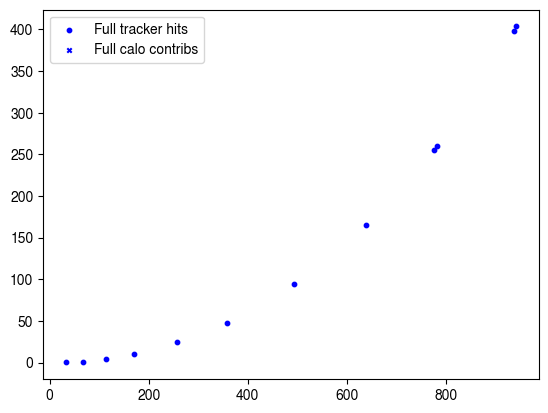

In [163]:
plt.scatter(full_tracker_df[full_tracker_df.particle_id == 7244].x, full_tracker_df[full_tracker_df.particle_id == 7244].y, c="blue", s=10, label="Full tracker hits")
plt.scatter(full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244].x, full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244].y, c="blue", marker="x", s=10, label="Full calo contribs")
# plt.scatter(full_tracker_df[tracker_df.particle_id == 8749].x, full_tracker_df[tracker_df.particle_id == 8749].y, c="red", s=1, label="Skimmed tracker hits")
plt.legend()
plt.show()

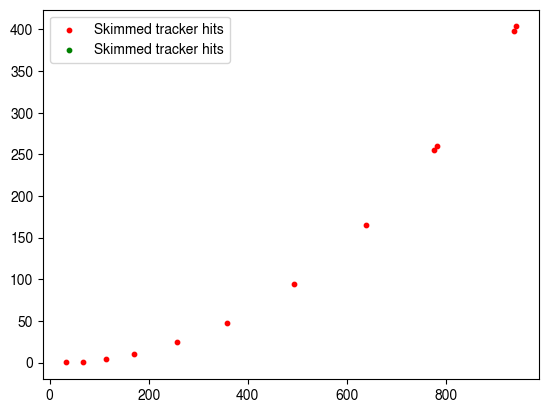

In [164]:
plt.scatter(full_tracker_df[tracker_df.particle_id == 7244].x, full_tracker_df[tracker_df.particle_id == 7244].y, c="red", s=10, label="Skimmed tracker hits")
plt.scatter(full_tracker_df[tracker_df.particle_id == 8749].x, full_tracker_df[tracker_df.particle_id == 8749].y, c="green", s=10, label="Skimmed tracker hits")
plt.legend()
plt.show()

In [ ]:
tracker_df.loc[552].particle_id, full_tracker_df.loc[552].particle_id

(np.int32(8749), np.int32(7244))

In [ ]:
skimmed_to_full_id_map[8749]

KeyError: 8749

In [169]:
full_ancestors = list(nx.ancestors(G, 7244))
full_descendants = list(nx.descendants(G, 7244))
skimmed_ancestors = list(nx.ancestors(skimmed_G, 7244))
skimmed_descendants = list(nx.descendants(skimmed_G, 7244))

In [170]:
full_ancestors

[np.int64(6918),
 np.int64(6919),
 np.int64(6927),
 np.int64(6930),
 np.int64(6932),
 np.int64(6933),
 np.int64(6947),
 np.int64(6955),
 np.int64(6958),
 np.int64(6960),
 np.int64(6974),
 np.int64(6984),
 np.int64(6989),
 np.int64(6990),
 np.int64(6992),
 np.int64(6993),
 np.int64(6995),
 np.int64(6996),
 np.int64(6998),
 np.int64(7000),
 np.int64(7001),
 np.int64(7002),
 np.int64(7003),
 np.int64(7004),
 np.int64(7005),
 np.int64(7006),
 np.int64(7007),
 np.int64(7008),
 np.int64(7009),
 np.int64(7010),
 np.int64(7011),
 np.int64(7012),
 np.int64(7013),
 np.int64(7014),
 np.int64(7015),
 np.int64(7016),
 np.int64(7017),
 np.int64(7018),
 np.int64(7019),
 np.int64(7020),
 np.int64(7021),
 np.int64(7022),
 np.int64(7027)]

In [171]:
skimmed_ancestors

[np.int64(6918),
 np.int64(6919),
 np.int64(6927),
 np.int64(6930),
 np.int64(6932),
 np.int64(6933),
 np.int64(6947),
 np.int64(6955),
 np.int64(6958),
 np.int64(6960),
 np.int64(6974),
 np.int64(6984),
 np.int64(6989),
 np.int64(6990),
 np.int64(6992),
 np.int64(6993),
 np.int64(6995),
 np.int64(6996),
 np.int64(6998),
 np.int64(7000),
 np.int64(7001),
 np.int64(7002),
 np.int64(7003),
 np.int64(7004),
 np.int64(7005),
 np.int64(7006),
 np.int64(7007),
 np.int64(7008),
 np.int64(7009),
 np.int64(7010),
 np.int64(7011),
 np.int64(7012),
 np.int64(7013),
 np.int64(7014),
 np.int64(7015),
 np.int64(7016),
 np.int64(7017),
 np.int64(7018),
 np.int64(7019),
 np.int64(7020),
 np.int64(7021),
 np.int64(7022),
 np.int64(7027)]

In [172]:
full_descendants

[np.int64(417792),
 np.int64(417793),
 np.int64(417794),
 np.int64(417795),
 np.int64(417796),
 np.int64(417797),
 np.int64(417798),
 np.int64(417799),
 np.int64(417800),
 np.int64(417801),
 np.int64(417802),
 np.int64(417803),
 np.int64(417804),
 np.int64(417805),
 np.int64(417806),
 np.int64(417807),
 np.int64(417808),
 np.int64(417809),
 np.int64(417810),
 np.int64(417811),
 np.int64(417812),
 np.int64(417813),
 np.int64(417814),
 np.int64(417815),
 np.int64(417816),
 np.int64(417817),
 np.int64(417818),
 np.int64(417819),
 np.int64(417820),
 np.int64(417821),
 np.int64(417822),
 np.int64(417823),
 np.int64(417824),
 np.int64(417825),
 np.int64(417826),
 np.int64(417827),
 np.int64(417828),
 np.int64(417829),
 np.int64(417830),
 np.int64(417831),
 np.int64(417832),
 np.int64(417833),
 np.int64(417834),
 np.int64(417835),
 np.int64(417836),
 np.int64(417837),
 np.int64(417838),
 np.int64(417839),
 np.int64(417840),
 np.int64(417841),
 np.int64(417842),
 np.int64(417843),
 np.int64(41

In [173]:
skimmed_descendants

[np.int64(33709),
 np.int64(33710),
 np.int64(33711),
 np.int64(33712),
 np.int64(33713),
 np.int64(33714),
 np.int64(33715),
 np.int64(33716),
 np.int64(33717),
 np.int64(33718),
 np.int64(33719),
 np.int64(33720),
 np.int64(33721),
 np.int64(33722),
 np.int64(33723),
 np.int64(33724),
 np.int64(33725),
 np.int64(33726),
 np.int64(33727),
 np.int64(33728),
 np.int64(33729),
 np.int64(33730),
 np.int64(33731),
 np.int64(33732),
 np.int64(33733),
 np.int64(33734),
 np.int64(33735),
 np.int64(33736),
 np.int64(33737),
 np.int64(33738),
 np.int64(33739),
 np.int64(33740),
 np.int64(33741),
 np.int64(33742),
 np.int64(33743),
 np.int64(33744),
 np.int64(33745),
 np.int64(33746),
 np.int64(33747),
 np.int64(33748),
 np.int64(33749),
 np.int64(33750),
 np.int64(33751),
 np.int64(33752),
 np.int64(33753)]

In [ ]:
full_particles_df.iloc[10452:10457]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi,particle_id
10452,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,0.446525,...,1221.201398,29912,29913,33489,33490,0.689975,0.831864,0.630807,0.866941,10452
10453,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,-0.379689,...,2195.945842,29913,29914,33490,33490,0.468677,0.633692,0.816296,2.515170,10453
10454,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,0.435368,...,1016.248028,29914,29915,33490,33490,0.514944,0.522165,-0.167270,-0.563359,10454
10455,2112,0,1224736768,0.0,3.205688,0.939565,1189.700345,688.873067,1221.201398,-0.092400,...,1233.959549,29915,29916,33490,33491,0.479266,0.556852,0.561597,1.764806,10455
10456,2112,0,1224736768,0.0,3.369621,0.939565,1185.542528,710.034446,1233.959549,-0.201264,...,1370.470362,29916,29917,33491,33491,0.202826,0.475478,1.496167,3.017401,10456


In [ ]:
skimmed_descendants

[]

In [ ]:
list(nx.descendants(skimmed_G, 7244))

[np.int64(8749)]

In [178]:
full_particles_df.loc[417098]

PDG                2.112000e+03
generatorStatus    0.000000e+00
simulatorStatus    1.207960e+09
charge             0.000000e+00
time               2.519624e+00
mass               9.395654e-01
vx                 1.052720e+03
vy                 5.229406e+02
vz                 1.070684e+03
px                -2.867418e-02
py                 7.706964e-03
pz                -4.261910e-02
endpoint_x        -4.706979e+02
endpoint_y         6.591991e+02
endpoint_z         4.823788e+02
parents_begin      4.365580e+05
parents_end        4.365590e+05
daughters_begin    5.125450e+05
daughters_end      5.125500e+05
pt                 2.969185e-02
p                  5.194222e-02
eta               -1.158376e+00
phi                2.879021e+00
particle_id        4.170980e+05
Name: 417098, dtype: float64

In [ ]:
daughters_df.iloc[24783]

particle_id           8749
collectionID    2714477136
parent_id             7244
Name: 24783, dtype: int64

In [ ]:
particles_df.loc[8749]

PDG                2.112000e+03
generatorStatus    0.000000e+00
simulatorStatus    2.013266e+09
charge             0.000000e+00
time               2.519624e+00
mass               9.395654e-01
vx                 1.052720e+03
vy                 5.229406e+02
vz                 1.070684e+03
px                -2.867418e-02
py                 7.706964e-03
pz                -4.261910e-02
endpoint_x        -4.706979e+02
endpoint_y         6.591991e+02
endpoint_z         4.823788e+02
parents_begin      2.820900e+04
parents_end        2.821000e+04
daughters_begin    2.915600e+04
daughters_end      2.915600e+04
pt                 2.969185e-02
p                  5.194222e-02
eta               -1.158376e+00
phi                2.879021e+00
particle_id        8.749000e+03
Name: 8749, dtype: float64

In [ ]:
particles_df.loc[7244]

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    8.388608e+07
charge            -1.000000e+00
time              -3.596635e+00
mass               1.395700e-01
vx                 2.814718e-02
vy                 3.564536e-03
vz                -2.539741e+00
px                 7.736642e-01
py                -7.548373e-03
pz                 6.827099e-01
endpoint_x         1.042386e+03
endpoint_y         5.216395e+02
endpoint_z         1.062809e+03
parents_begin      2.374600e+04
parents_end        2.374700e+04
daughters_begin    2.478300e+04
daughters_end      2.478400e+04
pt                 7.737010e-01
p                  1.031846e+00
eta                7.957238e-01
phi               -9.756344e-03
particle_id        7.244000e+03
Name: 7244, dtype: float64

In [ ]:
full_particles_df.loc[7244]

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    1.509949e+08
charge            -1.000000e+00
time              -3.596635e+00
mass               1.395700e-01
vx                 2.814718e-02
vy                 3.564536e-03
vz                -2.539741e+00
px                 7.736642e-01
py                -7.548373e-03
pz                 6.827099e-01
endpoint_x         1.042386e+03
endpoint_y         5.216395e+02
endpoint_z         1.062809e+03
parents_begin      2.374600e+04
parents_end        2.374700e+04
daughters_begin    2.724700e+04
daughters_end      2.725000e+04
pt                 7.737010e-01
p                  1.031846e+00
eta                7.957238e-01
phi               -9.756344e-03
particle_id        7.244000e+03
Name: 7244, dtype: float64

In [ ]:
skimmed_to_full_id_map[7244]

7244

In [ ]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,...,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout,8352,8352.0
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,...,8468,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout,8468,8468.0
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,...,8467,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout,8467,8467.0
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,...,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout,8350,8350.0
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,...,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout,8347,8347.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,1073741824,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,...,30324,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout,30313,30313.0
21549,15749646188894,20.597553,0.124870,1073741824,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,...,30332,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout,30322,NaN
21550,16333760692558,22.928253,0.125527,1073741824,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,...,30332,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout,30322,NaN
21551,1554779373662,26.342630,0.032734,1073741824,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,...,30335,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout,30322,30322.0


In [37]:
duplicates = full_particles_df[full_particles_df.duplicated(subset=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"], keep=False)]


In [41]:
# Check if duplicates left hits
full_tracker_df[full_tracker_df.particle_id.isin(duplicates.index)]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector,processed_id


In [42]:
# Check if duplicates left hits
full_calo_contrib_df[full_calo_contrib_df.particle_id.isin(duplicates.index)]

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector


In [ ]:
full_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30392,11,0,1224736768,-1.000000,18.987364,0.000511,-256.810462,1259.268982,2897.654381,-0.014434,...,1259.642684,2913.530223,49852,49853,49855,49856,0.072863,0.184257,1.579285,1.770208
30393,-11,0,1224736768,1.000000,18.987364,0.000511,-256.810462,1259.268982,2897.654381,-0.011995,...,1260.790231,2910.989339,49853,49854,49856,49856,0.055590,0.143103,1.598637,1.788277
30394,22,0,1493172224,0.000000,19.005100,0.000000,-256.981303,1261.157314,2902.621089,-0.000295,...,1263.273587,2908.342965,49854,49855,49856,49857,0.057090,0.164575,1.720342,1.575962
30395,-11,0,1224736768,1.000000,19.025450,0.000511,-256.992234,1263.273587,2908.342965,-0.000120,...,1270.008773,2933.174926,49855,49856,49857,49857,0.052210,0.149162,1.710773,1.573097


Now, let's look to see if the incidentParentID lines up with the particles in event.
Start by getting all the hits in a particle with hits in the tracker AND calo.

In [75]:
particles_df = event["particles_df"]
calo_df = event["calo_contrib_df"]
tracker_df = event["tracker_df"]
particles_with_calo_hits = calo_df.particle_id.unique()
particles_with_tracker_hits = tracker_df.particle_id.unique()
particles_with_hits = np.intersect1d(particles_with_calo_hits, particles_with_tracker_hits)
sample_particle = np.random.choice(particles_with_hits)
sample_particle_df = particles_df.loc[sample_particle]


In [76]:
sample_particle_df

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    8.388608e+07
charge            -1.000000e+00
time              -8.515367e+00
mass               1.395700e-01
vx                -2.742718e-02
vy                 2.047749e-02
vz                -8.378056e+00
px                 3.823615e-01
py                -9.209523e-02
pz                 4.229099e-01
endpoint_x         5.922598e+02
endpoint_y         1.188056e+03
endpoint_z         1.825446e+03
parents_begin      1.327900e+04
parents_end        1.328000e+04
daughters_begin    1.361700e+04
daughters_end      1.361700e+04
pt                 3.932962e-01
p                  5.775246e-01
eta                9.336267e-01
phi               -2.363571e-01
Name: 3939, dtype: float64

In [77]:
sample_particle_calo_hits = calo_df[calo_df.particle_id == sample_particle]

In [78]:
sample_particle_tracker_hits = tracker_df[tracker_df.particle_id == sample_particle]

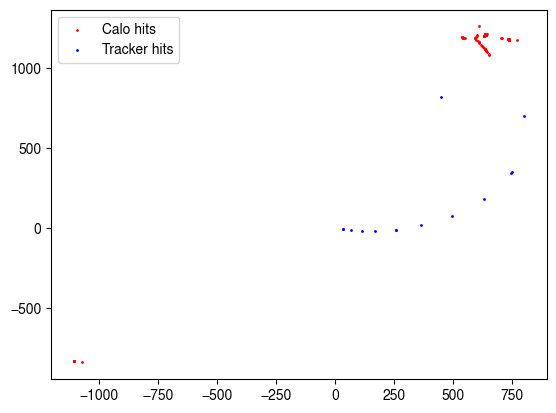

In [79]:
plt.scatter(sample_particle_calo_hits.x, sample_particle_calo_hits.y, c="red", s=1, label="Calo hits")
plt.scatter(sample_particle_tracker_hits.x, sample_particle_tracker_hits.y, c="blue", s=1, label="Tracker hits")
plt.legend()
plt.show()

In [88]:
full_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761748,11,0,1493172224,-1.000000,18.976517,0.000511,-258.027782,1258.587714,2894.249881,-0.000801,...,1258.624261,2894.282049,781208,781209,781213,781213,0.000825,0.001543,1.237925,2.897669
761749,11,0,1224736768,-1.000000,19.009468,0.000511,-253.705155,1264.753188,2900.644315,0.000872,...,1264.782095,2900.667475,781209,781210,781213,781213,0.001294,0.001504,0.561900,0.831355
761750,11,0,1493172224,-1.000000,18.923120,0.000511,-256.154790,1252.674619,2879.452487,-0.000060,...,1252.947183,2879.439595,781210,781211,781213,781213,0.003275,0.004671,0.893106,1.589054
761751,11,0,1493172224,-1.000000,18.925692,0.000511,-256.377062,1252.815231,2880.177064,-0.001575,...,1252.836941,2880.923638,781211,781212,781213,781213,0.001690,0.004967,1.740621,2.770165


I guess because this is a generator particle, it's very similar between the full and trimmed event.

In [90]:
full_particles_df.loc[sample_particle] == sample_particle_df

PDG                 True
generatorStatus     True
simulatorStatus    False
charge              True
time                True
mass                True
vx                  True
vy                  True
vz                  True
px                  True
py                  True
pz                  True
endpoint_x          True
endpoint_y          True
endpoint_z          True
parents_begin       True
parents_end         True
daughters_begin    False
daughters_end      False
pt                  True
p                   True
eta                 True
phi                 True
Name: 3939, dtype: bool

In [97]:
descendants = list(nx.descendants(G, sample_particle))

In [100]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,0.000621,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,0.000209,8893,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,0.000167,8892,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,0.000387,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,0.000236,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,1073741824,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,0.000069,759109,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout
21549,15749646188894,20.597553,0.124870,0,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,0.000041,759149,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout
21550,16333760692558,22.928253,0.125527,0,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,0.000149,759149,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout
21551,1554779373662,26.342630,0.032734,1073741824,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,0.000058,759241,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout


In [101]:
full_calo_hit_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
0,18428729469050290192,6.279467e-07,737.476990,-1083.676514,-331.500000,0,1,1310.811523,1352.079590,-0.973256,1.818499,-0.250276,ECalBarrelCollection
1,18300095628031993872,2.059417e-04,-1205.247070,-521.310486,-2657.100098,1,2,1313.158447,2963.876953,-2.733358,2.682590,-1.454070,ECalBarrelCollection
2,18300658513560807440,1.595900e-05,-1220.525635,-444.836060,-2652.000000,2,3,1299.062012,2953.077393,-2.792092,2.686104,-1.462030,ECalBarrelCollection
3,28710275835123728,2.549791e-04,719.923035,1204.970337,515.099976,3,14,1403.653320,1495.182495,1.032246,1.219083,0.359197,ECalBarrelCollection
4,28710280130091024,6.176600e-05,715.211243,1206.921997,515.099976,14,17,1402.921143,1494.495239,1.035842,1.218915,0.359377,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173370,19421781989294356,7.089448e-05,-344.989838,2041.930908,3647.500000,744773,744774,2070.869141,4194.372070,1.738168,0.516369,1.331509,HCalEndcapCollection
173371,16044086563733780,1.605069e-05,-245.333771,1694.700928,3647.500000,744774,744776,1712.366821,4029.448486,1.714563,0.438921,1.500346,HCalEndcapCollection
173372,16044095153701140,1.264276e-03,-186.486664,1706.406372,3698.500000,744776,744779,1716.566284,4077.438232,1.679651,0.434538,1.510708,HCalEndcapCollection
173373,15199674518503700,1.098509e-04,-139.504974,1623.988403,3647.500000,744779,744780,1629.969360,3995.129150,1.656489,0.420251,1.545180,HCalEndcapCollection


In [104]:
sample_tracker_hits = full_tracker_df[full_tracker_df.particle_id == sample_particle]
sample_calo_contribs = full_calo_contrib_df[full_calo_contrib_df.particle_id == sample_particle]
descendant_tracker_hits = full_tracker_df[full_tracker_df.particle_id.isin(descendants)]
descendant_calo_contribs = full_calo_contrib_df[full_calo_contrib_df.particle_id.isin(descendants)]


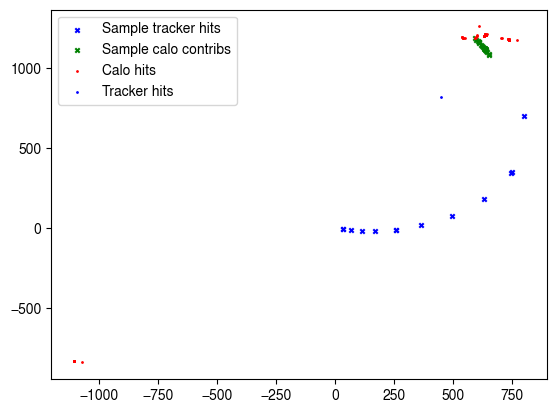

In [110]:
plt.scatter(sample_tracker_hits.x, sample_tracker_hits.y, c="blue", label="Sample tracker hits", marker="x", s=10)
plt.scatter(sample_calo_contribs.x, sample_calo_contribs.y, c="green", label="Sample calo contribs", marker="x", s=10)
plt.scatter(descendant_calo_contribs.x, descendant_calo_contribs.y, c="red", s=1, label="Calo hits")
plt.scatter(descendant_tracker_hits.x, descendant_tracker_hits.y, c="blue", s=1, label="Tracker hits")
plt.legend()
plt.show()

In [111]:
descendants

[np.int64(302080),
 np.int64(302081),
 np.int64(302082),
 np.int64(302083),
 np.int64(302084),
 np.int64(302085),
 np.int64(302086),
 np.int64(302087),
 np.int64(302088),
 np.int64(302089),
 np.int64(302090),
 np.int64(302091),
 np.int64(302092),
 np.int64(302093),
 np.int64(302094),
 np.int64(302095),
 np.int64(302096),
 np.int64(302097),
 np.int64(302098),
 np.int64(302099),
 np.int64(302100),
 np.int64(302101),
 np.int64(302102),
 np.int64(302103),
 np.int64(302104),
 np.int64(302105),
 np.int64(302106),
 np.int64(302107),
 np.int64(302108),
 np.int64(302109),
 np.int64(302110),
 np.int64(302111),
 np.int64(302112),
 np.int64(302113),
 np.int64(302114),
 np.int64(302115),
 np.int64(302116),
 np.int64(302117),
 np.int64(302118),
 np.int64(302119),
 np.int64(302120),
 np.int64(302121),
 np.int64(302122),
 np.int64(302123),
 np.int64(302124),
 np.int64(302125),
 np.int64(302126),
 np.int64(302127),
 np.int64(302128),
 np.int64(302129),
 np.int64(302130),
 np.int64(302131),
 np.int64(30

In [112]:
node_df[node_df.incidentParentID == sample_particle]

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID
3939,0.577525,-0.027427,0.020477,-8.378056,3939,3939,3939
302041,0.008427,735.423969,922.254939,1546.146848,302041,302041,3939
302042,0.001697,724.253363,948.519865,1574.368613,302042,302042,3939
302043,0.001453,718.347217,960.063721,1587.487310,302043,302043,3939
302044,0.002825,653.894903,1084.095956,1725.208386,302044,302044,3939
...,...,...,...,...,...,...,...
302147,0.009045,612.431216,1259.753189,1961.972472,302147,302147,3939
302148,0.001447,613.243529,1259.540283,1965.410309,302148,302148,3939
302149,0.002694,594.971185,1199.586193,1848.224244,302149,302149,3939
302150,0.007338,595.585024,1194.737306,1840.918523,302150,302150,3939


In [113]:
list(node_df[node_df.incidentParentID == sample_particle].particleID)

[3939,
 302041,
 302042,
 302043,
 302044,
 302045,
 302046,
 302047,
 302048,
 302049,
 302050,
 302051,
 302052,
 302053,
 302054,
 302055,
 302056,
 302057,
 302058,
 302059,
 302060,
 302061,
 302062,
 302063,
 302064,
 302065,
 302066,
 302067,
 302068,
 302069,
 302070,
 302071,
 302072,
 302073,
 302074,
 302075,
 302076,
 302077,
 302078,
 302079,
 302080,
 302081,
 302082,
 302083,
 302084,
 302085,
 302086,
 302087,
 302088,
 302089,
 302090,
 302091,
 302092,
 302093,
 302094,
 302095,
 302096,
 302097,
 302098,
 302099,
 302100,
 302101,
 302102,
 302103,
 302104,
 302105,
 302106,
 302107,
 302108,
 302109,
 302110,
 302111,
 302112,
 302113,
 302114,
 302115,
 302116,
 302117,
 302118,
 302119,
 302120,
 302121,
 302122,
 302123,
 302124,
 302125,
 302126,
 302127,
 302128,
 302129,
 302130,
 302131,
 302132,
 302133,
 302134,
 302135,
 302136,
 302137,
 302138,
 302139,
 302140,
 302141,
 302142,
 302143,
 302144,
 302145,
 302146,
 302147,
 302148,
 302149,
 302150,
 30

In [117]:
# Check that there is overlap between the descendant list and the node_df - ADD in the original particle to descendants!
len(np.intersect1d(descendants+[sample_particle], list(node_df[node_df.incidentParentID == sample_particle].particleID)))


112

In [116]:
len(descendants), len(list(node_df[node_df.incidentParentID == sample_particle].particleID))


(113, 112)

In [118]:
accuracy = len(np.intersect1d(descendants+[sample_particle], list(node_df[node_df.incidentParentID == sample_particle].particleID))) / len(descendants+[sample_particle])

In [119]:
accuracy

0.9824561403508771

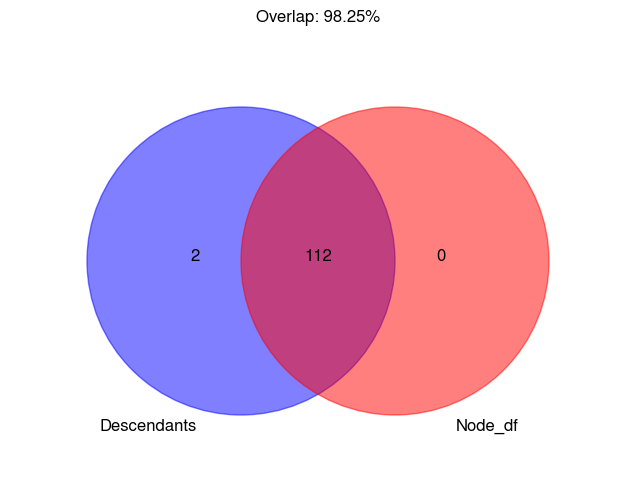

In [122]:
# Make a venn diagram of the overlap between the descendant list and the node_df using matplotlib patches
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Get the sets
set1 = set(descendants+[sample_particle])
set2 = set(node_df[node_df.incidentParentID == sample_particle].particleID)
intersection = set1.intersection(set2)

# Calculate non-intersecting parts
only_in_set1 = set1 - intersection
only_in_set2 = set2 - intersection

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create two circles
circle1 = Circle((-0.5, 0), 1, alpha=0.5, fc=to_rgba('blue', 0.4), ec='blue', label='Descendants')
circle2 = Circle((0.5, 0), 1, alpha=0.5, fc=to_rgba('red', 0.4), ec='red', label='Node_df')

# Add circles to the plot
ax.add_patch(circle1)
ax.add_patch(circle2)

# Add text labels with counts of non-intersecting and intersecting parts
ax.text(-0.8, 0, f"{len(only_in_set1)}", fontsize=12, ha='center')
ax.text(0.8, 0, f"{len(only_in_set2)}", fontsize=12, ha='center')
ax.text(0, 0, f"{len(intersection)}", fontsize=12, ha='center')

# Add set labels
ax.text(-1.1, -1.1, "Descendants", fontsize=12, ha='center')
ax.text(1.1, -1.1, "Node_df", fontsize=12, ha='center')

# Set axis limits and remove ticks
ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')

# Add title showing overlap percentage
ax.set_title(f"Overlap: {len(intersection)/len(set1):.2%}")

plt.show()


# Single Particle - No Energy Threshold

In [2]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [3]:
base_dir = "/global/cfs/projectdirs/m4958/data/ColliderML/outputs/single_particle_tests/"
event_num = 0

This is with the TC truth handler turned on, but with a tracker the size of the world volume. That is, we should see energy threshold effects, but not calorimeter decay collapse effects.

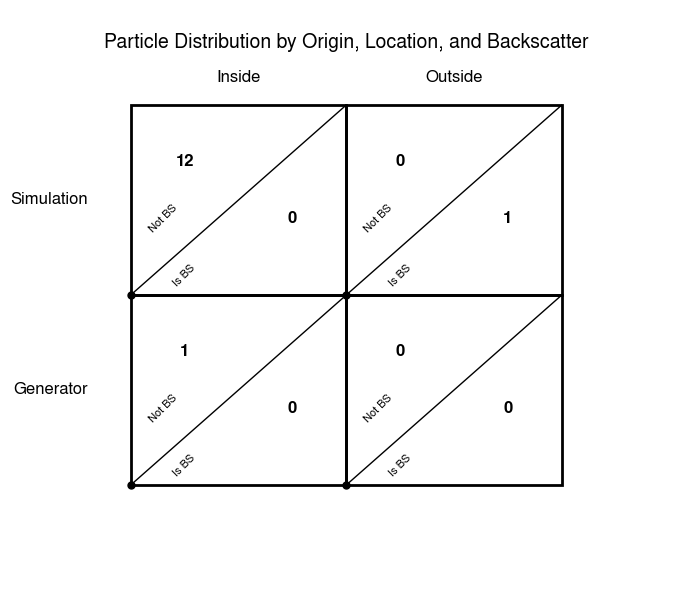

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            12 |          0
Outside   | Simulation |             0 |          1

Totals by Category:
PARTICLES WITH HITS
Total particles: 14
From Generator: 1
From Simulation: 13
Inside Tracker: 13
Outside Tracker: 1
Backscatter: 1

ALL PARTICLES
Total particles: 116
From Generator: 1
From Simulation: 115
Inside Tracker: 115
Outside Tracker: 1


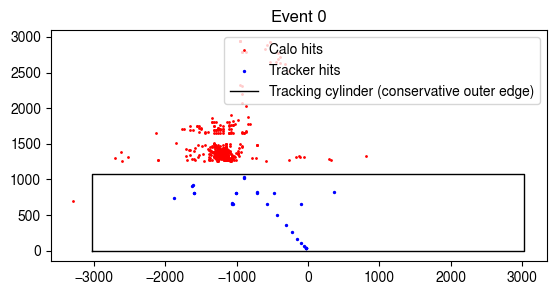

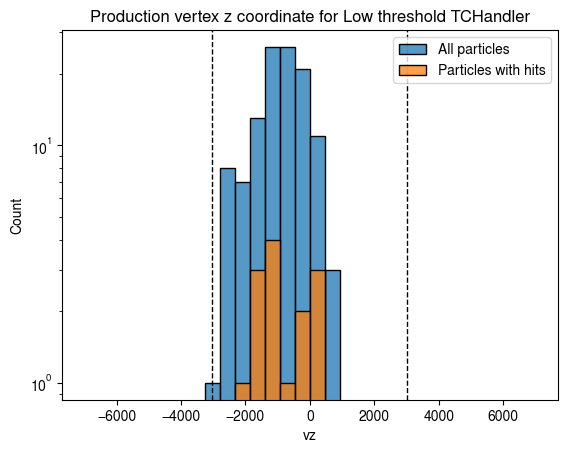

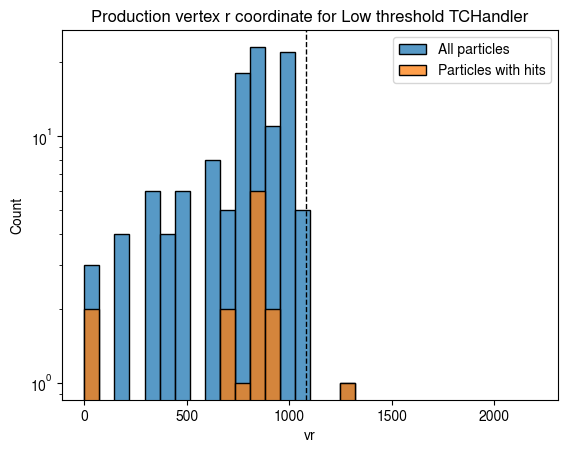

In [4]:
edm4hep_file = f"{base_dir}/single_run_test_TC_low_threshold/edm4hep.root"
TC_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold TCHandler", detector_params=detector_params)

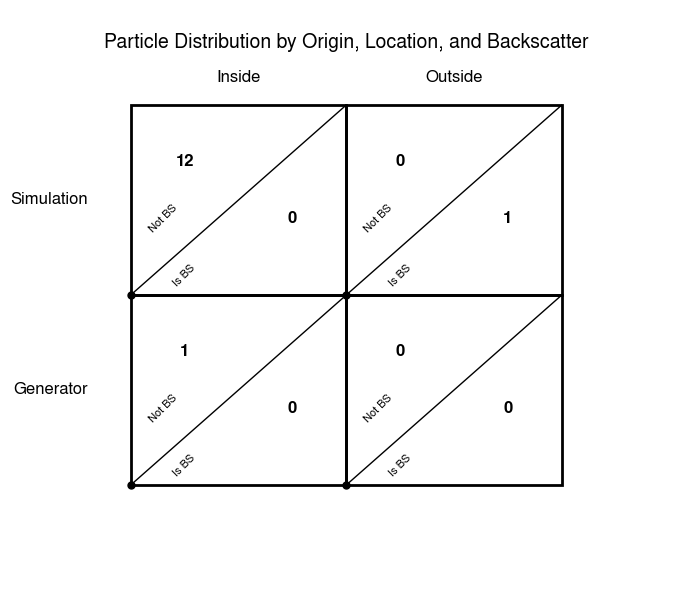

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            12 |          0
Outside   | Simulation |             0 |          1

Totals by Category:
PARTICLES WITH HITS
Total particles: 14
From Generator: 1
From Simulation: 13
Inside Tracker: 13
Outside Tracker: 1
Backscatter: 1

ALL PARTICLES
Total particles: 116
From Generator: 1
From Simulation: 115
Inside Tracker: 115
Outside Tracker: 1


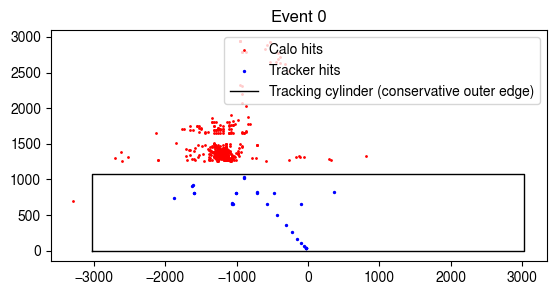

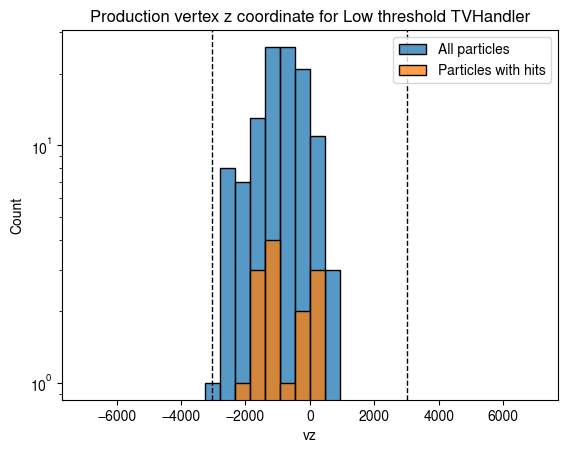

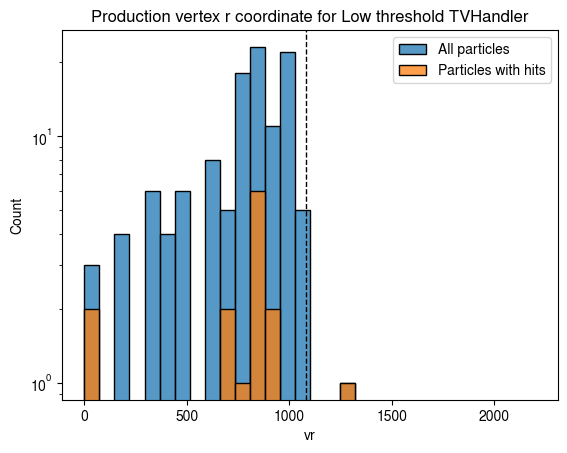

In [5]:
edm4hep_file = f"{base_dir}/single_run_test_TV_low_threshold/edm4hep.root"
TV_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold TVHandler", detector_params=detector_params)

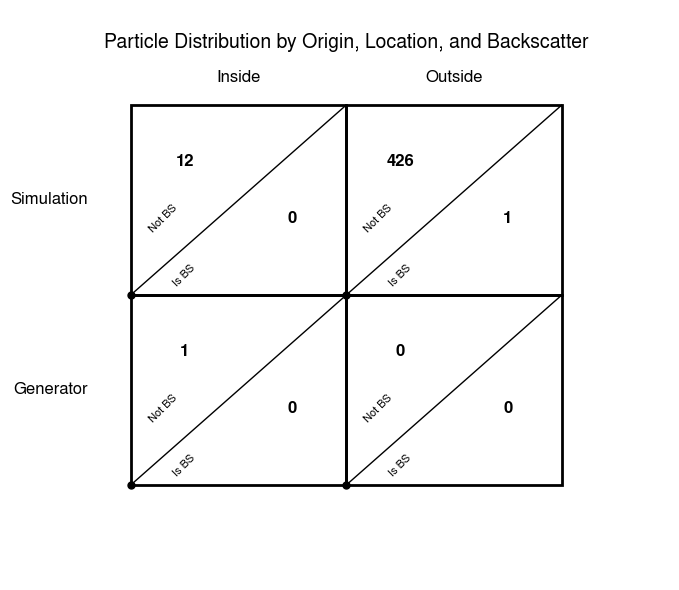

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            12 |          0
Outside   | Simulation |           426 |          1

Totals by Category:
PARTICLES WITH HITS
Total particles: 440
From Generator: 1
From Simulation: 439
Inside Tracker: 13
Outside Tracker: 427
Backscatter: 1

ALL PARTICLES
Total particles: 542
From Generator: 1
From Simulation: 541
Inside Tracker: 115
Outside Tracker: 427


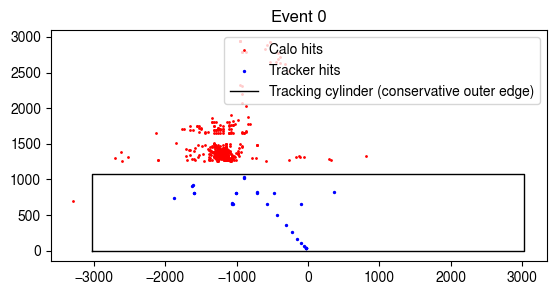

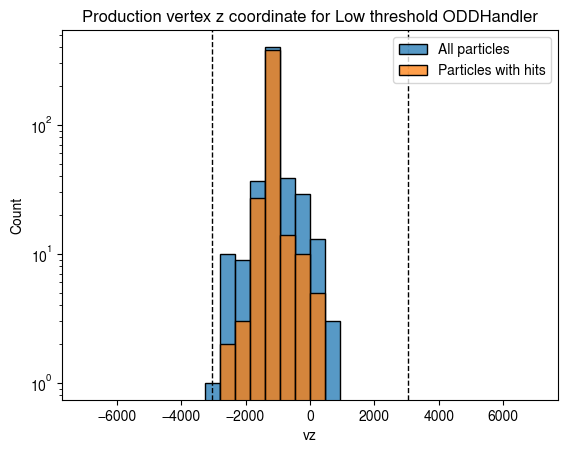

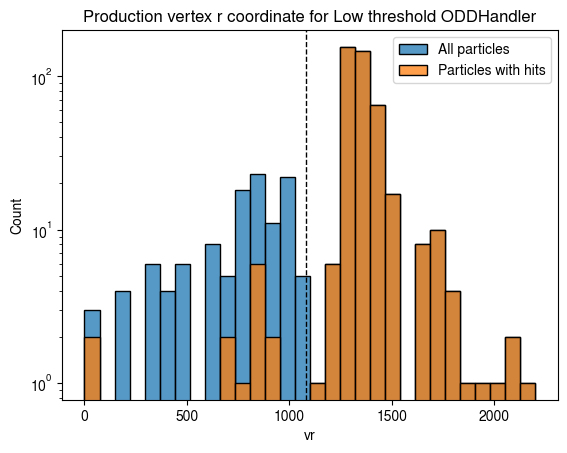

In [5]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_low_threshold/edm4hep.root"
ODD_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold ODDHandler", detector_params=detector_params)

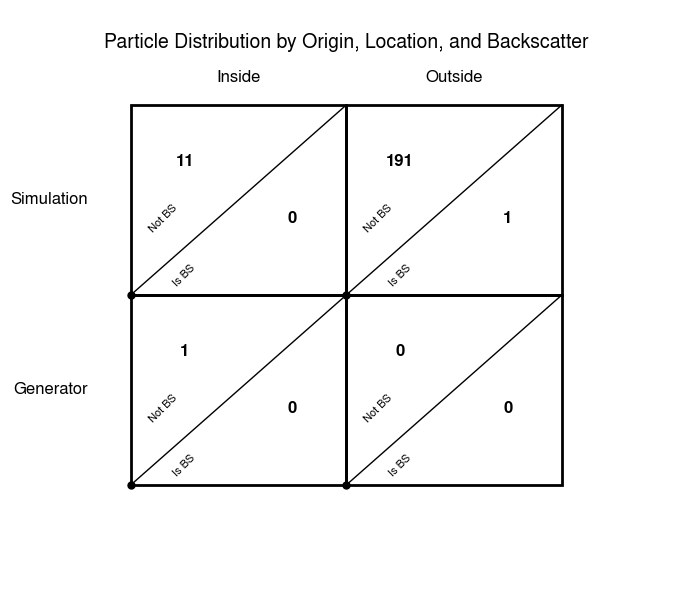

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            11 |          0
Outside   | Simulation |           191 |          1

Totals by Category:
PARTICLES WITH HITS
Total particles: 204
From Generator: 1
From Simulation: 203
Inside Tracker: 12
Outside Tracker: 192
Backscatter: 1

ALL PARTICLES
Total particles: 210
From Generator: 1
From Simulation: 209
Inside Tracker: 18
Outside Tracker: 192


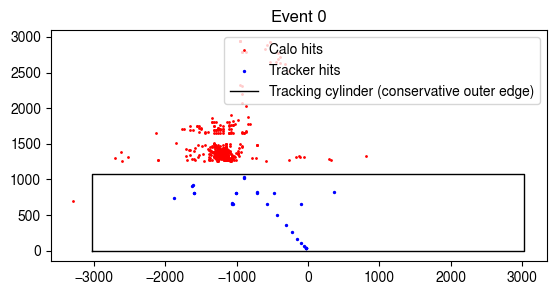

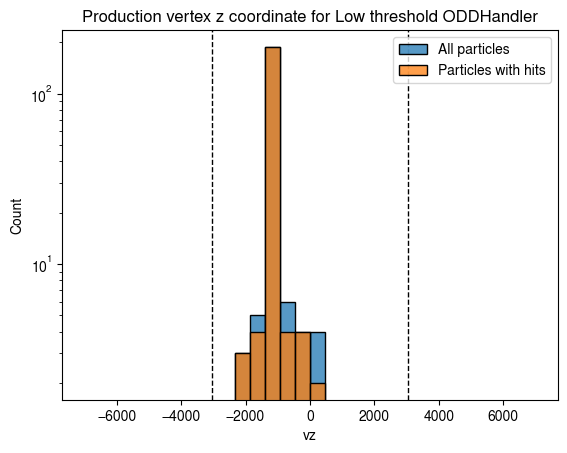

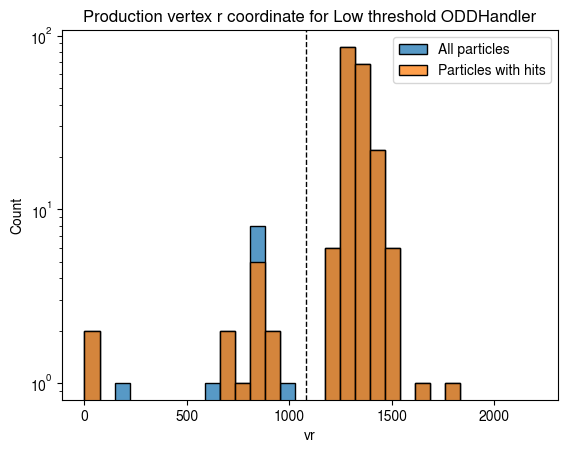

In [16]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_medium_threshold/edm4hep.root"
ODD_medium_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold ODDHandler", detector_params=detector_params)

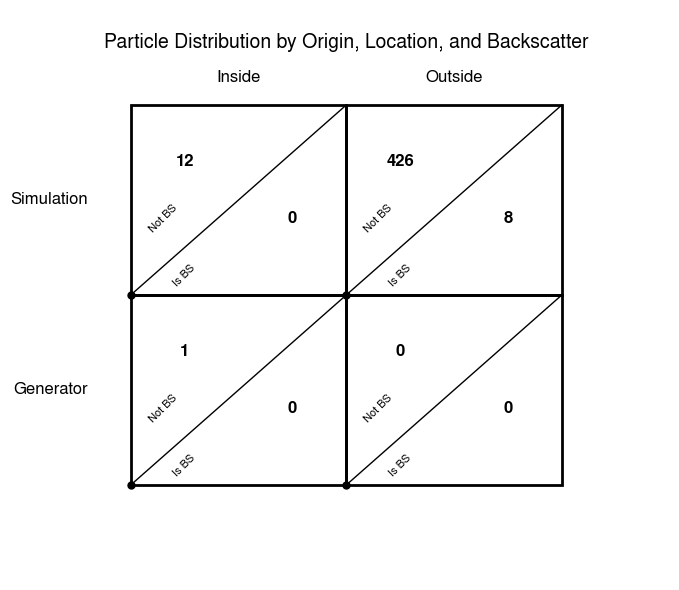

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            12 |          0
Outside   | Simulation |           426 |          8

Totals by Category:
PARTICLES WITH HITS
Total particles: 447
From Generator: 1
From Simulation: 446
Inside Tracker: 13
Outside Tracker: 434
Backscatter: 8

ALL PARTICLES
Total particles: 10776
From Generator: 1
From Simulation: 10775
Inside Tracker: 115
Outside Tracker: 10661


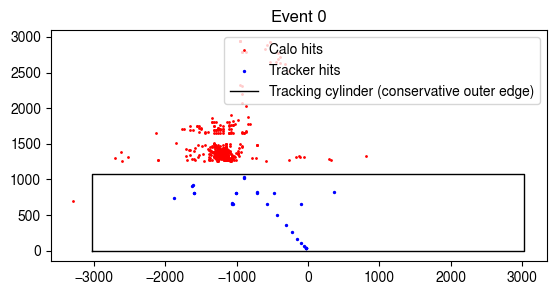

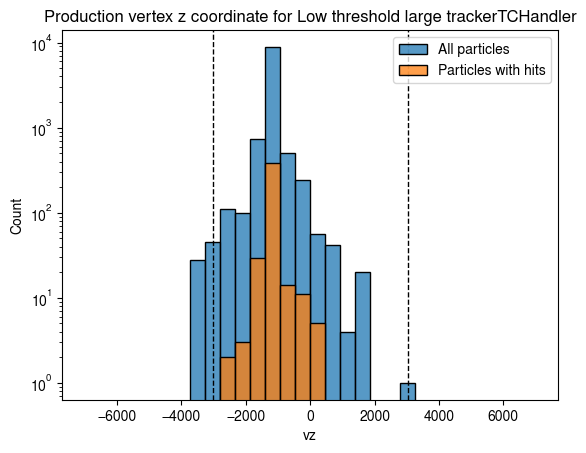

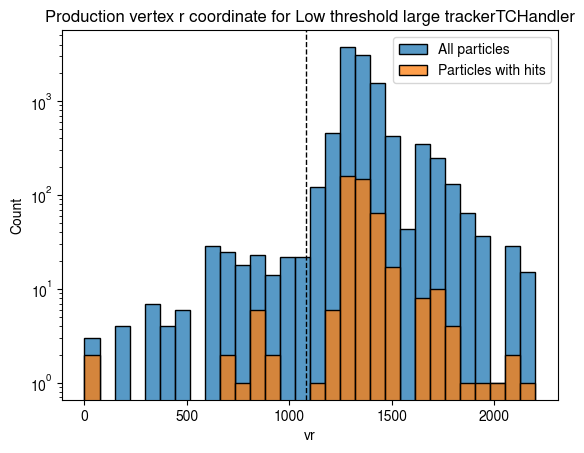

In [7]:
edm4hep_file = f"{base_dir}/single_run_test_TC_large_tracker_low_threshold/edm4hep.root"
large_TC_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold large trackerTCHandler", detector_params=detector_params)

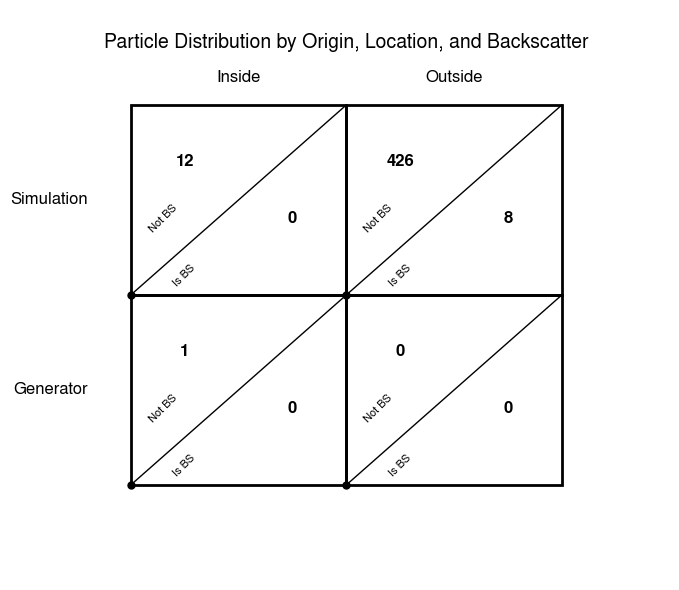

Data Summary:
Location  | Origin     | No Backscatter | Backscatter
-------------------------------------------------------
Inside    | Generator  |             1 |          0
Outside   | Generator  |             0 |          0
Inside    | Simulation |            12 |          0
Outside   | Simulation |           426 |          8

Totals by Category:
PARTICLES WITH HITS
Total particles: 447
From Generator: 1
From Simulation: 446
Inside Tracker: 13
Outside Tracker: 434
Backscatter: 8

ALL PARTICLES
Total particles: 10776
From Generator: 1
From Simulation: 10775
Inside Tracker: 115
Outside Tracker: 10661


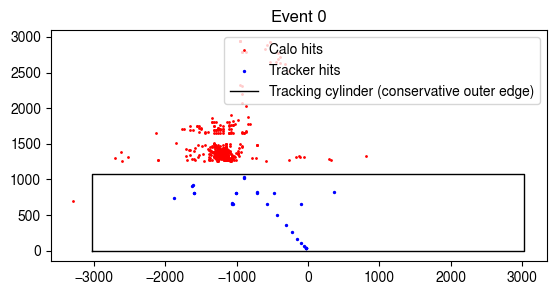

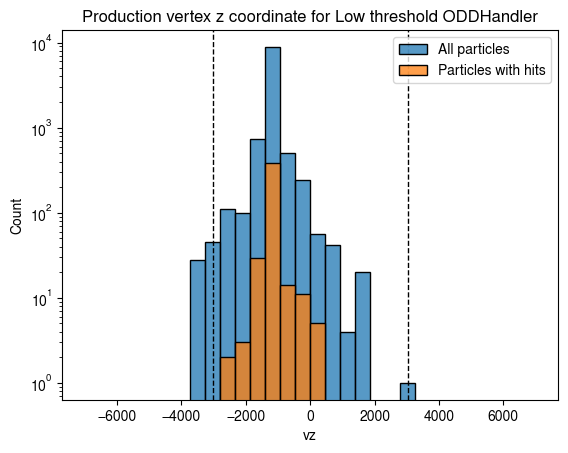

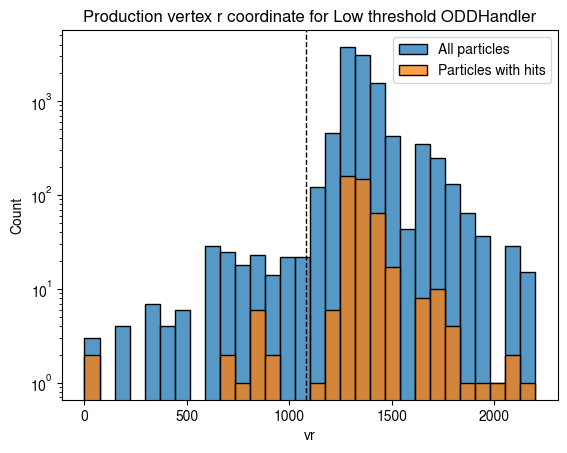

In [7]:
edm4hep_file = f"{base_dir}/single_run_test_ODD_keep_all/edm4hep.root"
ODD_keep_all_event = event_diagnostics(edm4hep_file, event_num=event_num, label="Low threshold ODDHandler", detector_params=detector_params)

## TC Handler vs. Custom Handler

In [9]:
TC_particles_df = large_TC_event["particles_df"]

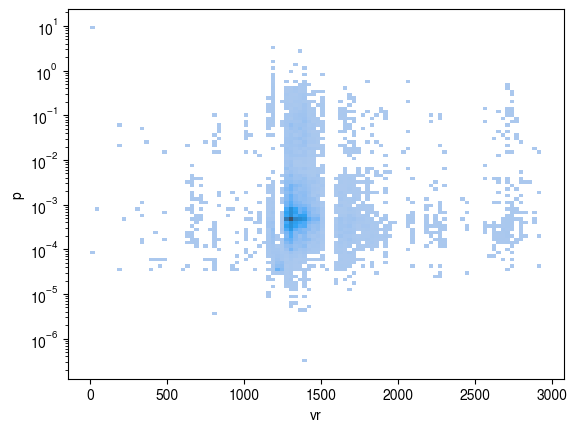

In [10]:
# 2d histogram of particle vr and p
sns.histplot(x=TC_particles_df.vr, y=TC_particles_df.p, bins=100, log_scale=(False, True))

plt.show()

In [22]:
ODD_particles_df = ODD_event["particles_df"]

In [23]:
ODD_particles_df[["vr", "endpoint_r"]]

,vr,endpoint_r
0,0.000000,1198.486097
1,26.933407,26.618292
2,33.261652,34.056235
3,201.915124,201.934549
4,402.726374,402.877922
...,...,...
537,1458.970222,1459.372507
538,1478.799132,1479.283694
539,940.081703,940.146991
540,940.176002,940.159108


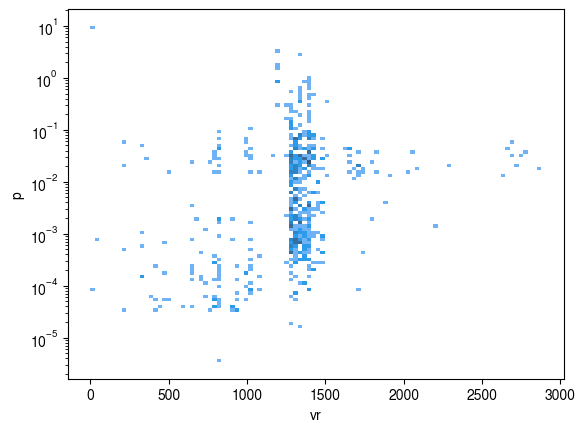

In [24]:
# 2d histogram of particle vr and p
sns.histplot(x=ODD_particles_df.vr, y=ODD_particles_df.p, bins=100, log_scale=(False, True))

plt.show()

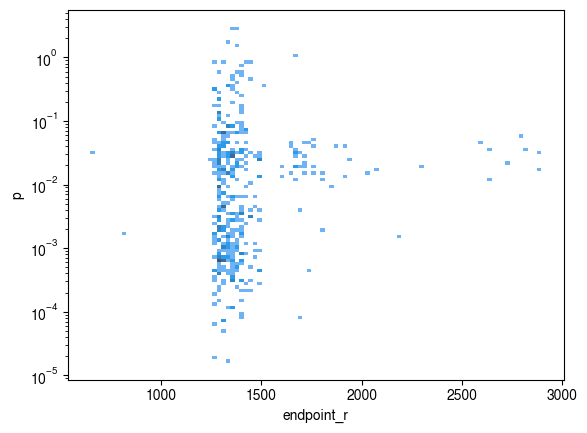

In [25]:
calo_ODD_particles_df = ODD_particles_df[ODD_particles_df.created_inside_tracker == 0]

# 2d histogram of particle vr and p
sns.histplot(x=calo_ODD_particles_df.endpoint_r, y=calo_ODD_particles_df.p, bins=100, log_scale=(False, True))

plt.show()

In [17]:
ODD_medium_particles_df = ODD_medium_event["particles_df"]

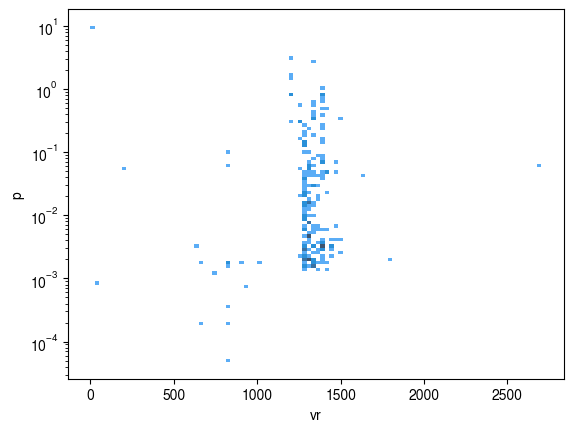

In [18]:
# 2d histogram of particle vr and p
sns.histplot(x=ODD_medium_particles_df.vr, y=ODD_medium_particles_df.p, bins=100, log_scale=(False, True))

plt.show()

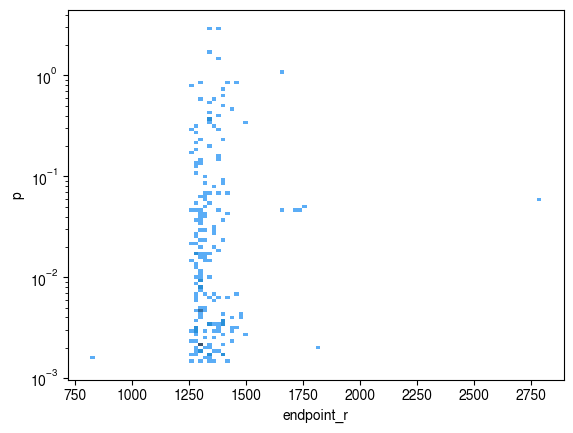

In [19]:
calo_ODD_medium_particles_df = ODD_medium_particles_df[ODD_medium_particles_df.created_inside_tracker == 0]
# 2d histogram of particle vr and p
sns.histplot(x=calo_ODD_medium_particles_df.endpoint_r, y=calo_ODD_medium_particles_df.p, bins=100, log_scale=(False, True))

plt.show()

To diagnose the difference, we need to know:
- Take a particle produced in the tracker in low threshold that doesn't appear in high threshold, which is above 0.001 GeV

In [83]:
ODD_tracker_hits_df = ODD_event["tracker_df"]
ODD_medium_tracker_hits_df = ODD_medium_event["tracker_df"]
ODD_calo_hits_df = ODD_event["calo_contrib_df"]
ODD_medium_calo_hits_df = ODD_medium_event["calo_contrib_df"]
ODD_daughters_df = ODD_event["daughters_df"]
ODD_medium_daughters_df = ODD_medium_event["daughters_df"]

In [33]:
ODD_particles_df[(ODD_particles_df.created_inside_tracker == 1) & (ODD_particles_df.p > 0.001) & (ODD_particles_df.index.isin(ODD_tracker_hits_df.particle_id))]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
24,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
52,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False
184,1000140280,0,1493172224,14.0,120.285950,26.053194,160.881786,-799.384374,-484.063377,-0.090028,...,0.090222,0.096420,0.368570,3.076014,815.412979,815.412906,1,1,1,False
344,11,0,1493172224,-1.0,18.112108,0.000511,-180.292770,-716.912659,-1878.730636,-0.000665,...,0.001169,0.001210,-0.265605,-2.175534,739.235581,741.978114,1,1,1,False
413,1000140280,0,1493172224,14.0,79.946289,26.053194,-414.187350,712.111119,357.858223,-0.053050,...,0.053537,0.064229,0.621922,3.006580,823.804229,823.804284,1,1,1,False


In [41]:
ODD_particles_df[(ODD_particles_df.created_inside_tracker == 1) & (ODD_particles_df.p > 0.001)]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
10,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314568,-558.626150,0.002685,...,0.003212,0.003374,-0.316664,0.580828,635.488577,635.362217,1,1,1,False
22,1000060120,0,1493172224,6.0,82.184448,11.174863,779.981444,267.446657,-26.821603,-0.047077,...,0.047526,0.049225,-0.266636,-3.004059,824.559741,824.559120,1,1,1,False
24,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
25,2212,0,1493172224,1.0,53.086212,0.938272,954.525790,346.810214,108.060701,-0.027864,...,0.029728,0.029930,0.116326,-2.785515,1015.577081,1015.571365,1,1,1,False
26,2212,0,1493172224,1.0,56.786720,0.938272,954.524149,353.535477,128.394769,-0.006559,...,0.006592,0.015282,1.483760,-3.040772,1017.891785,1017.891148,1,1,1,False
33,2212,0,1493172224,1.0,150.397507,0.938272,144.944373,141.346661,-1840.468981,-0.008285,...,0.053781,0.056390,-0.310231,1.725463,202.454315,202.476218,1,1,1,False
34,2212,0,1493172224,1.0,161.036743,0.938272,86.421445,183.071480,-1894.598043,-0.013551,...,0.013662,0.022103,-1.061157,-3.014415,202.444642,202.443753,1,1,1,False
45,11,0,1493172224,-1.0,8.111740,0.000511,816.725718,75.020770,-696.730784,-0.001326,...,0.001362,0.001547,0.515469,-2.912612,820.164017,819.170412,1,1,1,False
52,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False


In [34]:
ODD_medium_particles_df[(ODD_medium_particles_df.created_inside_tracker == 1) & (ODD_medium_particles_df.p > 0.001) & (ODD_medium_particles_df.index.isin(ODD_medium_tracker_hits_df.particle_id))]


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
9,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
23,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False
68,1000140280,0,1493172224,14.0,120.285950,26.053194,160.881786,-799.384374,-484.063377,-0.090028,...,0.090222,0.096420,0.368570,3.076014,815.412979,815.412906,1,1,1,False
137,11,0,1493172224,-1.0,18.112108,0.000511,-180.292770,-716.912659,-1878.730636,-0.000665,...,0.001169,0.001210,-0.265605,-2.175534,739.235581,741.978114,1,1,1,False
159,1000140280,0,1493172224,14.0,79.946289,26.053194,-414.187350,712.111119,357.858223,-0.053050,...,0.053537,0.064229,0.621922,3.006580,823.804229,823.804284,1,1,1,False


In [44]:
ODD_medium_particles_df[(ODD_medium_particles_df.created_inside_tracker == 1) & (ODD_medium_particles_df.pt > 0.001)]


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
0,211,1,16777216,1.0,0.000000,0.139570,0.000000,0.000000,0.000000,7.314463,...,7.509689,10.000000,-0.793412,0.228517,0.000000,1198.486097,0,1,0,False
2,11,0,1493172224,-1.0,2.822778,0.000511,622.399472,128.314568,-558.626150,0.002685,...,0.003212,0.003374,-0.316664,0.580828,635.488577,635.362217,1,1,1,False
9,11,0,1493172224,-1.0,4671.243164,0.000511,887.201488,-226.843413,-1609.568058,-0.001318,...,0.001675,0.001865,0.471396,-2.476157,915.742548,915.024852,1,1,1,False
12,2212,0,1493172224,1.0,150.397507,0.938272,144.944373,141.346661,-1840.468981,-0.008285,...,0.053781,0.056390,-0.310231,1.725463,202.454315,202.476218,1,1,1,False
18,11,0,1493172224,-1.0,8.111740,0.000511,816.725718,75.020770,-696.730784,-0.001326,...,0.001362,0.001547,0.515469,-2.912612,820.164017,819.170412,1,1,1,False
23,11,0,1493172224,-1.0,9.227405,0.000511,314.501088,584.036079,-1066.465255,-0.001554,...,0.001740,0.001870,0.383977,2.675096,663.331800,662.264360,1,1,1,False
29,11,0,1493172224,-1.0,6.880608,0.000511,969.061636,314.895717,-1133.440404,-0.001720,...,0.001721,0.001748,0.176152,3.108573,1018.940511,1018.883078,1,1,1,False
68,1000140280,0,1493172224,14.0,120.285950,26.053194,160.881786,-799.384374,-484.063377,-0.090028,...,0.090222,0.096420,0.368570,3.076014,815.412979,815.412906,1,1,1,False
137,11,0,1493172224,-1.0,18.112108,0.000511,-180.292770,-716.912659,-1878.730636,-0.000665,...,0.001169,0.001210,-0.265605,-2.175534,739.235581,741.978114,1,1,1,False
157,22,0,1426063360,0.0,79.946289,0.000000,-414.187350,712.111119,357.858223,0.000338,...,0.001805,0.001860,0.247042,1.382467,823.804229,1317.000964,1,1,0,False


In [50]:
G

In [57]:
sample_particle = 17

In [56]:
full_particles_df.loc[17]

PDG                               211
generatorStatus                     0
simulatorStatus            1157627904
charge                            1.0
time                          5.32532
mass                          0.13957
vx                        1178.951708
vy                         215.503585
vz                       -1053.953215
px                           0.249553
py                           0.079074
pz                          -0.162467
endpoint_x                1336.337123
endpoint_y                 267.790471
endpoint_z               -1145.693797
parents_begin                      16
parents_end                        17
daughters_begin                   155
daughters_end                     165
pt                           0.261781
p                            0.308099
eta                         -0.586428
phi                          0.306855
vr                        1198.486097
endpoint_r                1362.904488
created_in_simulation               1
created_insi

In [72]:
sample_medium_particle = ODD_medium_particles_df[ODD_medium_particles_df.p == full_particles_df.loc[17].p]
sample_medium_particle


,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
5,211,0,1157627904,1.0,5.32532,0.13957,1178.951708,215.503585,-1053.953215,0.249553,...,0.261781,0.308099,-0.586428,0.306855,1198.486097,1362.904488,1,0,0,False


In [73]:
sample_medium_particle[["daughters_begin", "daughters_end"]]

,daughters_begin,daughters_end
5,61,64


In [85]:
ODD_medium_daughters_df.iloc[61:64]

,particle_id,collectionID
61,122,2714477136
62,123,2714477136
63,124,2714477136


In [87]:
ODD_medium_particles_df.iloc[122:125]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
122,11,0,1426063360,-1.0,341.038116,0.000511,1311.744785,330.314511,-1141.721344,-0.002753,...,0.003474,0.003481,0.062853,2.485515,1352.694370,1351.671725,1,0,0,False
123,11,0,1426063360,-1.0,9.123814,0.000511,1268.154626,222.749064,-1182.772404,-0.000440,...,0.001712,0.001893,-0.455684,-1.830751,1287.568756,1287.260273,1,0,0,False
124,11,0,1426063360,-1.0,347.468140,0.000511,1349.914344,526.744924,-928.061177,-0.000416,...,0.003037,0.003080,-0.167306,1.708255,1449.044151,1451.945232,1,0,0,False


In [103]:
ODD_particles_df.iloc[ODD_daughters_df.iloc[155:165].particle_id]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter
294,1000060120,0,1493172224,6.0,33.828335,11.174863,964.649457,273.681849,-959.198402,-0.048281,...,0.055506,0.057333,-0.255873,2.625684,1002.721462,1002.720916,1,1,1,False
295,2212,0,1493172224,1.0,34.851292,0.938272,965.524845,258.320685,-957.264826,0.019342,...,0.028034,0.030574,-0.422599,-0.809381,999.483768,999.486445,1,1,1,False
296,2212,0,1493172224,1.0,148.128433,0.938272,363.949961,-710.695347,-302.311091,-0.016046,...,0.033899,0.035305,0.287044,-2.063875,798.465686,798.470713,1,1,1,False
297,2212,0,1493172224,1.0,52.442951,0.938272,802.316092,197.734062,-669.525182,-0.038026,...,0.039581,0.041000,0.266989,2.860396,826.323103,826.310979,1,1,1,False
298,2212,0,1493172224,1.0,139.401184,0.938272,357.071640,-341.750220,-584.690253,-0.015396,...,0.015410,0.015851,0.238650,3.099259,494.260426,494.254081,1,1,1,False
299,2112,0,1426063360,0.0,10.091825,0.939565,1311.763829,239.943220,-1129.426218,0.016644,...,0.020474,0.021225,-0.269975,-0.621638,1333.528062,1374.739796,1,0,0,False
301,2112,0,1409286144,0.0,38.049347,0.939565,1401.153129,491.775042,-1365.538120,0.016283,...,0.016354,0.029916,1.212268,-0.092667,1484.948748,1681.162671,1,0,0,False
302,11,0,1426063360,-1.0,9.123814,0.000511,1268.154626,222.749064,-1182.772404,-0.000440,...,0.001712,0.001893,-0.455684,-1.830751,1287.568756,1287.260273,1,0,0,False
303,2112,0,1426063360,0.0,6.206884,0.939565,1333.890963,268.753989,-1149.095338,0.009543,...,0.040008,0.043078,0.389308,1.329942,1360.696075,1340.833977,1,0,0,False
304,11,0,1426063360,-1.0,347.468140,0.000511,1349.914344,526.744924,-928.061177,-0.000416,...,0.003037,0.003080,-0.167306,1.708255,1449.044151,1451.945232,1,0,0,False


In [86]:
ODD_daughters_df.iloc[155:165]

,particle_id,collectionID,parent_id
155,294,2714477136,17
156,295,2714477136,17
157,296,2714477136,17
158,297,2714477136,17
159,298,2714477136,17
160,299,2714477136,17
161,301,2714477136,17
162,302,2714477136,17
163,303,2714477136,17
164,304,2714477136,17


In [93]:
ODD_medium_particles_df[ODD_medium_particles_df.p == ODD_particles_df.loc[295].p]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,pt,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter


In [91]:
ODD_particles_df.loc[295]

PDG                             2212
generatorStatus                    0
simulatorStatus           1493172224
charge                           1.0
time                       34.851292
mass                        0.938272
vx                        965.524845
vy                        258.320685
vz                       -957.264826
px                          0.019342
py                         -0.020292
pz                         -0.012203
endpoint_x                965.528697
endpoint_y                258.316643
endpoint_z               -957.267256
parents_begin                    294
parents_end                      295
daughters_begin                  400
daughters_end                    400
pt                          0.028034
p                           0.030574
eta                        -0.422599
phi                        -0.809381
vr                        999.483768
endpoint_r                999.486445
created_in_simulation              1
created_inside_tracker             1
e

In [94]:
get_simulator_status_bits(ODD_particles_df.loc[295].simulatorStatus)

{'created_in_simulation': '1',
 'backscatter': '0',
 'vertex_not_endpoint': '1',
 'decayed_in_tracker': '1',
 'decayed_in_calorimeter': '0',
 'has_left_detector': '0',
 'stopped': '1',
 'overlay': '0'}

In [97]:
ODD_particles_df.iloc[294:305][["parents_begin", "parents_end"]]

,parents_begin,parents_end
294,293,294
295,294,295
296,295,296
297,296,297
298,297,298
299,298,299
300,299,300
301,300,301
302,301,302
303,302,303


In [101]:
full_parents_df.iloc[293:304]

,particle_id,collectionID
293,17,2714477136
294,17,2714477136
295,17,2714477136
296,17,2714477136
297,17,2714477136
298,17,2714477136
299,299,2714477136
300,17,2714477136
301,17,2714477136
302,17,2714477136


In [102]:
ODD_calo_hits_df[ODD_calo_hits_df.particle_id.isin(ODD_daughters_df.iloc[155:165].particle_id)]

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector
1016,0,3.097946e-05,10.337384,0.0,0.0,0.0,299,249,1313.000000,239.699997,-1132.199951,ECalBarrelCollection
1018,0,3.696365e-05,9.127080,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1019,0,1.948491e-05,9.127319,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1020,0,3.767398e-05,9.127589,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1021,0,3.723178e-05,9.127836,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1022,0,5.768460e-05,9.128127,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1023,0,1.195975e-05,9.128245,0.0,0.0,0.0,302,251,1267.550049,224.399994,-1183.199951,ECalBarrelCollection
1024,0,3.862598e-06,15.465124,0.0,0.0,0.0,303,252,1332.349365,320.028748,-1111.800049,ECalBarrelCollection
1025,0,1.532812e-04,347.471252,0.0,0.0,0.0,304,253,1350.734863,526.371521,-928.200012,ECalBarrelCollection
1026,0,5.899418e-05,347.471802,0.0,0.0,0.0,304,253,1350.734863,526.371521,-928.200012,ECalBarrelCollection


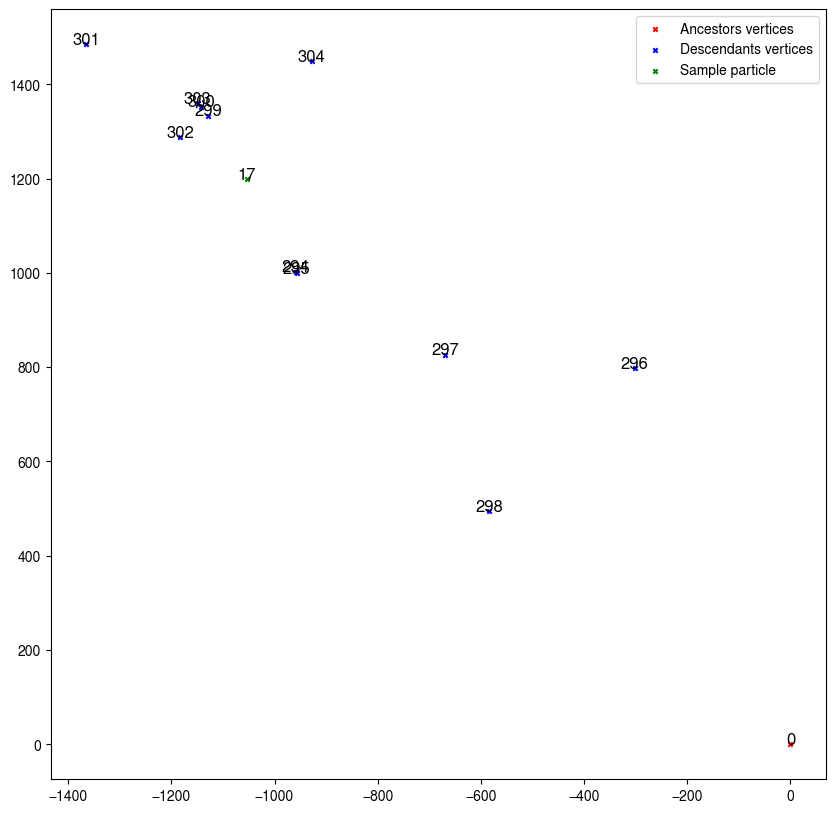

In [58]:
descendants = list(nx.descendants(G, sample_particle))
ancestors = list(nx.ancestors(G, sample_particle))

plt.figure(figsize=(10, 10))
plt.scatter(full_particles_df.loc[ancestors].vz, full_particles_df.loc[ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(full_particles_df.loc[descendants].vz, full_particles_df.loc[descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(full_particles_df.loc[sample_particle].vz, full_particles_df.loc[sample_particle].vr, c="green", s=10, marker="x", label="Sample particle")

# Add text with the particle ID
plt.text(full_particles_df.loc[sample_particle].vz, full_particles_df.loc[sample_particle].vr, f"{sample_particle}", fontsize=12, ha='center')

for ancestor in ancestors:
    plt.text(full_particles_df.loc[ancestor].vz, full_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in descendants:
    plt.text(full_particles_df.loc[descendant].vz, full_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')

plt.legend()
plt.show()


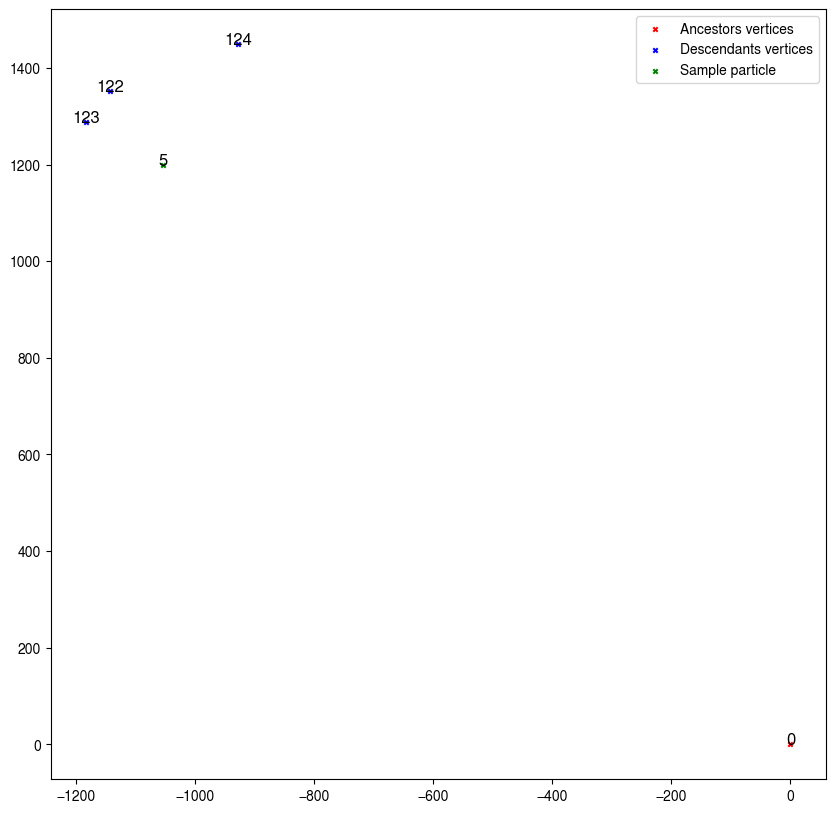

In [96]:
medium_sample_particle = 5
medium_descendants = list(nx.descendants(medium_G, medium_sample_particle))
medium_ancestors = list(nx.ancestors(medium_G, medium_sample_particle))

plt.figure(figsize=(10, 10))
plt.scatter(ODD_medium_particles_df.loc[medium_ancestors].vz, ODD_medium_particles_df.loc[medium_ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(ODD_medium_particles_df.loc[medium_descendants].vz, ODD_medium_particles_df.loc[medium_descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")
plt.scatter(ODD_medium_particles_df.loc[medium_sample_particle].vz, ODD_medium_particles_df.loc[medium_sample_particle].vr, c="green", s=10, marker="x", label="Sample particle")

# Add text with the particle ID
plt.text(ODD_medium_particles_df.loc[medium_sample_particle].vz, ODD_medium_particles_df.loc[medium_sample_particle].vr, f"{medium_sample_particle}", fontsize=12, ha='center')

for ancestor in medium_ancestors:
    plt.text(ODD_medium_particles_df.loc[ancestor].vz, ODD_medium_particles_df.loc[ancestor].vr, f"{ancestor}", fontsize=12, ha='center')

for descendant in medium_descendants:
    plt.text(ODD_medium_particles_df.loc[descendant].vz, ODD_medium_particles_df.loc[descendant].vr, f"{descendant}", fontsize=12, ha='center')

plt.legend()
plt.show()


## Some Questions...

1. Are there virtual particles in the tracker between, e.g. a primary, and a decay product that leaves a hit?

In [ ]:
# Want to get a particle that starts and ends in the tracker, which doesn't leave a hit, but has a decay product that does.

In [ ]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,0.000621,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,0.000209,11871,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,0.000167,11870,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,0.000387,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,0.000236,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,0,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,0.000069,4420523,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout
21549,15749646188894,20.597553,0.124870,0,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,0.000041,4420748,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout
21550,16333760692558,22.928253,0.125527,0,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,0.000149,4420748,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout
21551,1554779373662,26.342630,0.032734,0,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,0.000058,4421240,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout


In [ ]:
full_particles_df.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'vr', 'endpoint_r',
       'created_in_simulation', 'created_inside_tracker',
       'ended_inside_tracker', 'backscatter', 'left_tracker_hit'],
      dtype='object')

In [ ]:
full_particles_df["left_tracker_hit"] = full_particles_df.index.isin(full_tracker_df.particle_id)

In [ ]:
particles_without_hit_with_daughters_mask = ~full_particles_df.left_tracker_hit & (full_particles_df.daughters_begin != full_particles_df.daughters_end) & full_particles_df.created_inside_tracker & full_particles_df.ended_inside_tracker
particles_without_hit_with_daughters = full_particles_df[particles_without_hit_with_daughters_mask]

In [ ]:
particles_without_hit_with_daughters

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter,left_tracker_hit
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,6999.999937,inf,0.000000,0.000000,0.006807,0,1,1,False,False
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,2607.457556,7.572637,-0.084146,0.006807,0.006807,0,1,1,False,False
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,376.885189,7.320521,-1.804631,0.006807,0.006807,0,1,1,False,False
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,267.841489,5.740426,-1.800382,0.006807,0.006807,0,1,1,False,False
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,155.382063,4.531422,0.143721,0.006807,0.006807,0,1,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4418820,11,0,1493172224,-1.000000,11.084579,0.000511,-62.257651,328.841160,727.038321,-0.000802,...,0.001803,1.294607,-2.631118,334.682721,334.322265,1,1,1,False,False
4418824,11,0,1493172224,-1.000000,12.360787,0.000511,-110.987173,463.293311,1081.869257,0.000015,...,0.000099,-0.233530,1.417352,476.401978,476.497433,1,1,1,False,False
4418828,11,0,1493172224,-1.000000,13.297421,0.000511,-155.822986,557.987815,1342.374586,-0.000048,...,0.000082,0.257100,-2.214237,579.336866,579.151288,1,1,1,False,False
4420910,11,0,1493172224,-1.000000,23.442286,0.000511,-452.661192,909.383341,2682.700587,0.000087,...,0.000105,0.425643,-0.429950,1015.815049,1015.764855,1,1,1,False,False


In [ ]:
# sample = 4

for sample in particles_without_hit_with_daughters.index:
    daughters_indices = full_daughters_df[full_particles_df.loc[sample].daughters_begin:full_particles_df.loc[sample].daughters_end]
    daughters = full_particles_df.loc[daughters_indices.particle_id]
    
    parents_indices = full_parents_df[full_particles_df.loc[sample].parents_begin:full_particles_df.loc[sample].parents_end]
    parents = full_particles_df.loc[parents_indices.particle_id]
    
    # if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0:
    #     break

    if daughters.left_tracker_hit.any() and full_particles_df.loc[sample].simulatorStatus != 0 and parents.left_tracker_hit.any():
        print("Found one!")
        break

Found one!


In [ ]:
sample

45391

In [ ]:
full_particles_df.loc[sample]

PDG                                22
generatorStatus                     0
simulatorStatus            1493172224
charge                            0.0
time                        12.313094
mass                              0.0
vx                        -846.548213
vy                        -306.247474
vz                        1889.617731
px                          -0.000096
py                          -0.000026
pz                           0.000134
endpoint_x                -110.407437
endpoint_y                 174.623777
endpoint_z                  1636.9633
parents_begin                   64851
parents_end                     64852
daughters_begin                153217
daughters_end                  153221
pt                           0.000099
p                            0.000167
eta                          1.109493
phi                         -2.871624
vr                         900.239631
endpoint_r                 206.599288
created_in_simulation               1
created_insi

In [ ]:
daughters

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,p,eta,phi,vr,endpoint_r,created_in_simulation,created_inside_tracker,ended_inside_tracker,backscatter,left_tracker_hit
45636,11,0,1493172224,-1.0,12.395187,0.000511,-860.656302,-310.151519,1909.402080,-0.000205,...,0.000236,0.482254,-2.906833,914.835087,914.842236,1,1,1,False,True
45637,11,0,1493172224,-1.0,13.088897,0.000511,-663.332557,-269.445030,1960.951589,0.000033,...,0.000089,1.158479,-0.862584,715.968369,715.968346,1,1,1,False,False
45638,11,0,1493172224,-1.0,15.689675,0.000511,-111.131797,175.335553,1636.657297,0.000016,...,0.000140,-0.549036,1.441764,207.588132,207.588300,1,1,1,False,False
45639,11,0,1224736768,-1.0,15.693213,0.000511,-110.407437,174.623777,1636.963300,0.000056,...,0.000296,1.306370,1.189063,206.599288,206.600163,1,1,1,False,False


In [ ]:
full_particles_df.loc[32]

PDG                                1
generatorStatus                   41
simulatorStatus                    0
charge                     -0.333333
time                        8.091558
mass                             0.0
vx                          0.003543
vy                         -0.005813
vz                       -105.372111
px                              -0.0
py                               0.0
pz                        155.361861
endpoint_x                  0.003543
endpoint_y                 -0.005813
endpoint_z               -105.372111
parents_begin                     30
parents_end                       31
daughters_begin                   58
daughters_end                     60
pt                               0.0
p                         155.361861
eta                        42.822278
phi                         2.356194
vr                          0.006807
endpoint_r                  0.006807
created_in_simulation              0
created_inside_tracker             1
e

In [ ]:
ancestors = list(nx.ancestors(G, sample))
descendants = list(nx.descendants(G, sample))

In [ ]:
ancestors

[np.int64(8291),
 np.int64(8294),
 np.int64(44873),
 np.int64(45388),
 np.int64(8366),
 np.int64(45390),
 np.int64(8279),
 np.int64(8312),
 np.int64(8281),
 np.int64(8282),
 np.int64(8280),
 np.int64(8284),
 np.int64(8287),
 np.int64(44895)]

In [ ]:
descendants

[np.int64(45636), np.int64(45637), np.int64(45638), np.int64(45639)]

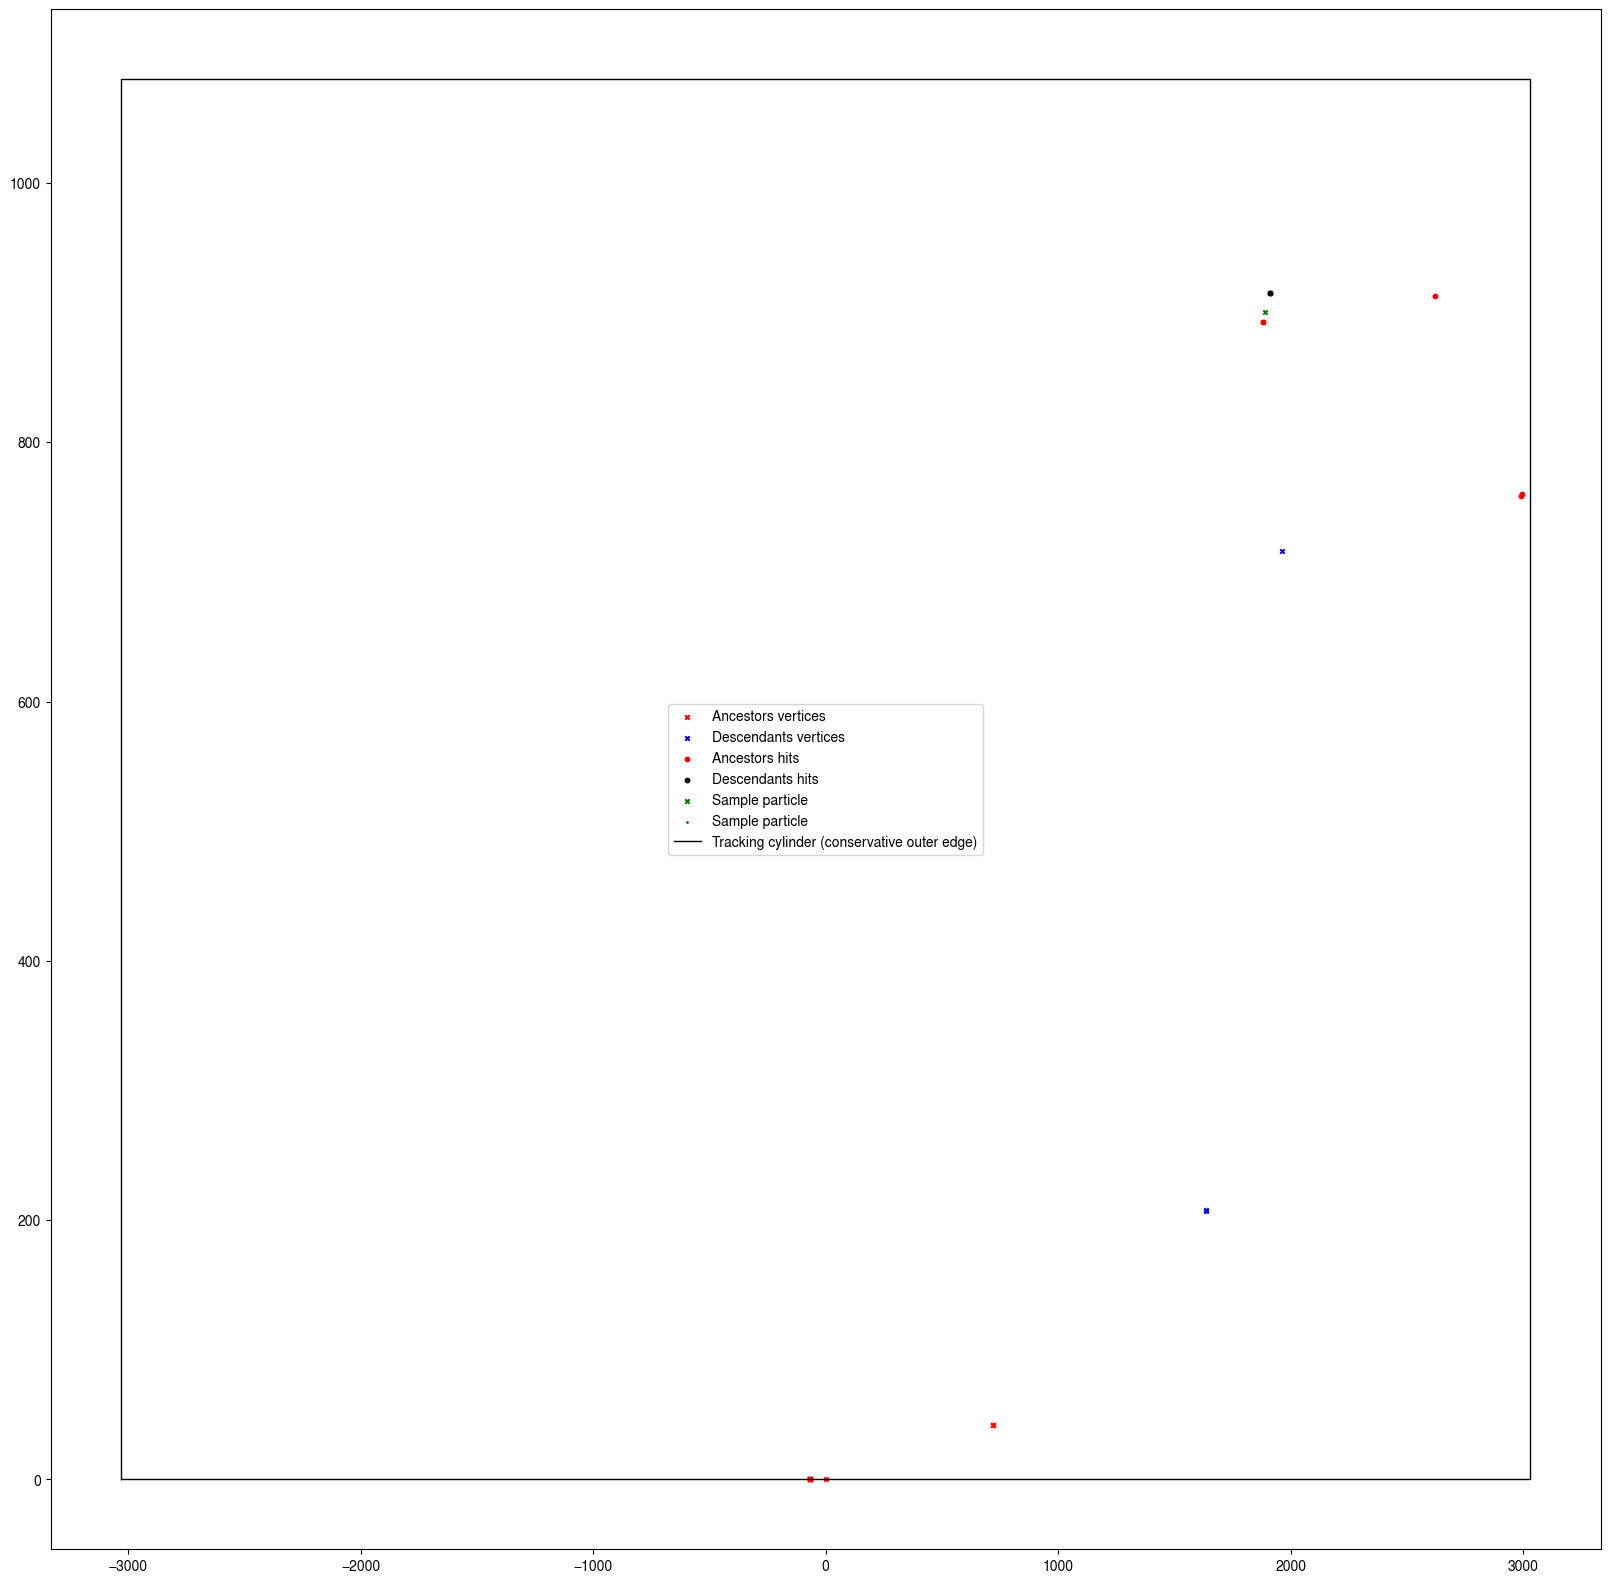

In [ ]:
plt.figure(figsize=(20, 20))
plt.scatter(full_particles_df.loc[ancestors].vz, full_particles_df.loc[ancestors].vr, c="red", s=10, marker="x", label="Ancestors vertices")
plt.scatter(full_particles_df.loc[descendants].vz, full_particles_df.loc[descendants].vr, c="blue", s=10, marker="x", label="Descendants vertices")

plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].z, full_tracker_df[full_tracker_df.particle_id.isin(ancestors)].r, c="red", s=10, label="Ancestors hits")
plt.scatter(full_tracker_df[full_tracker_df.particle_id.isin(descendants)].z, full_tracker_df[full_tracker_df.particle_id.isin(descendants)].r, c="black", s=10, label="Descendants hits")

plt.scatter(full_particles_df.loc[sample].vz, full_particles_df.loc[sample].vr, c="green", s=10, marker="x", label="Sample particle")
plt.scatter(full_tracker_df[full_tracker_df.particle_id == sample].z, full_tracker_df[full_tracker_df.particle_id == sample].r, c="green", s=1, label="Sample particle")

# add tracker boundaries
tracking_radius = detector_params['tracking_radius']
tracking_z_max = detector_params['tracking_z_max']
plt.plot([-tracking_z_max, -tracking_z_max, tracking_z_max, tracking_z_max, -tracking_z_max], [0, tracking_radius, tracking_radius, 0, 0], c="black", lw=1, label="Tracking cylinder (conservative outer edge)")
    

plt.legend()
plt.show()


## Postprocessed Version

In [45]:
unprocessed_event = ODD_event.copy()

In [46]:
full_particles_df, full_daughters_df, full_parents_df = unprocessed_event["particles_df"], unprocessed_event["daughters_df"], unprocessed_event["parents_df"]
full_tracker_df, full_calo_hit_df, full_calo_contrib_df = unprocessed_event["tracker_df"], unprocessed_event["calo_hits_df"], unprocessed_event["calo_contrib_df"]

In [47]:
particles_df, daughters_df, parents_df = event["particles_df"], event["daughters_df"], event["parents_df"]
tracker_df, calo_hit_df, calo_contrib_df = event["tracker_df"], event["calo_hits_df"], event["calo_contrib_df"]

NameError: name 'event' is not defined

In [ ]:
particles_with_hits = np.concatenate([full_calo_contrib_df.particle_id.unique(), full_tracker_df.particle_id.unique()])
particles_with_hits = np.unique(particles_with_hits)
particles_with_hits = full_particles_df.loc[particles_with_hits]
print(len(particles_with_hits))

161027


In [48]:
%%time
G = build_decay_tree(full_particles_df, full_daughters_df)
print(f"Built graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Creating nodes...
Created 541 edges
Built graph with 542 nodes and 541 edges
CPU times: user 11.3 ms, sys: 266 μs, total: 11.6 ms
Wall time: 59.2 ms


In [95]:
%%time
medium_G = build_decay_tree(ODD_medium_particles_df, ODD_medium_daughters_df)
print(f"Built graph with {medium_G.number_of_nodes()} nodes and {medium_G.number_of_edges()} edges")

Creating nodes...
Created 209 edges
Built graph with 210 nodes and 209 edges
CPU times: user 4.39 ms, sys: 4.66 ms, total: 9.05 ms
Wall time: 8.62 ms


In [ ]:
%%time
skimmed_G = build_decay_tree(particles_df, daughters_df)
print(f"Built graph with {skimmed_G.number_of_nodes()} nodes and {skimmed_G.number_of_edges()} edges")

Creating nodes...
Created 187985 edges
Built graph with 168525 nodes and 187985 edges
CPU times: user 947 ms, sys: 48.3 ms, total: 995 ms
Wall time: 994 ms


In [ ]:
%%time
processed_G = process_decay_tree(G, detector_params)

Finding root nodes...
Found 22 root nodes
Processing nodes in topological order...


100%|██████████| 4433848/4433848 [03:38<00:00, 20311.13it/s] 

CPU times: user 3min 34s, sys: 4.22 s, total: 3min 39s
Wall time: 3min 38s


In [49]:
%%time
# Convert the graph nodes to a pandas dataframe
node_df = pd.DataFrame.from_dict(dict(processed_G.nodes(data=True)), orient="index")

NameError: name 'processed_G' is not defined

In [ ]:
node_df

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID
0,6999.999937,0.000000,0.000000,0.000000,0,0,0
1,2607.457556,0.003543,-0.005813,-105.372111,1,1,1
2,376.885189,0.003543,-0.005813,-105.372111,2,2,2
3,267.841489,0.003543,-0.005813,-105.372111,3,3,3
4,155.382063,0.003543,-0.005813,-105.372111,4,4,4
...,...,...,...,...,...,...,...
4433843,0.000287,-255.871216,1252.989330,2879.464782,4433843,4433843,1773
4433844,0.000220,-255.866251,1253.050537,2879.551732,4433844,4433844,1773
4433845,0.000299,-254.646333,1248.344870,2871.269025,4433845,4433845,1773
4433846,0.001579,-257.298637,1262.368788,2904.671209,4433846,4433846,1773


In [ ]:
node_df[node_df.particleID != node_df.collapsedParticleID]

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID


In [ ]:
print(f"""
{(node_df.collapsedParticleID == node_df.particleID).all()}
If true, then indeed the energy threshold of the postprocessing matches that of the simulation
""")



True
If true, then indeed the energy threshold of the postprocessing matches that of the simulation



Now... We need:
- Merge event and processed_event particle lists (get Venn diagram)
- Map trimmed Ids to processed_event incidentParentIds
- Look at hit Ids in tracker
- Look at hit Ids in calo contributions
- Venn diagram of each

In [ ]:
full_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4433843,11,0,1493172224,-1.000000,18.925810,0.000511,-255.871216,1252.989330,2879.464782,0.000008,...,1252.988631,2879.464389,4453303,4453304,4453308,4453308,0.000250,0.000287,-0.536763,-1.538830
4433844,11,0,1224736768,-1.000000,18.926165,0.000511,-255.866251,1253.050537,2879.551732,0.000016,...,1253.050413,2879.552078,4453304,4453305,4453308,4453308,0.000076,0.000220,1.726098,-1.358289
4433845,11,0,1224736768,-1.000000,18.891832,0.000511,-254.646333,1248.344870,2871.269025,0.000120,...,1248.345275,2871.269754,4453305,4453306,4453308,4453308,0.000179,0.000299,1.101693,0.837016
4433846,11,0,1493172224,-1.000000,19.012995,0.000511,-257.298637,1262.368788,2904.671209,-0.000298,...,1262.899639,2905.412243,4453306,4453307,4453308,4453308,0.000621,0.001579,1.584800,2.070882


In [ ]:
particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168520,11,0,1493172224,-1.000000,32.152187,0.000511,503.010356,388.724010,729.956826,0.000003,...,388.723929,729.956873,187980,187981,187985,187985,0.000046,0.000053,0.560052,-1.508830
168521,11,0,1493172224,-1.000000,34.482018,0.000511,-152.872164,615.397612,809.277036,-0.000085,...,615.397685,809.277937,187981,187982,187985,187985,0.000085,0.000114,0.794611,3.066754
168522,11,0,1493172224,-1.000000,36.742622,0.000511,-72.794961,812.655510,165.871887,0.000001,...,812.655283,165.871494,187982,187983,187985,187985,0.000042,0.000083,-1.315809,-1.542408
168523,11,0,1493172224,-1.000000,37.413502,0.000511,-50.269409,1011.484669,186.145084,-0.000008,...,1011.484915,186.144943,187983,187984,187985,187985,0.000078,0.000089,-0.542863,1.670005


In [ ]:
full_to_processed_id_map = dict(zip(node_df.particleID, node_df.incidentParentID))

In [ ]:
# Add the index in as particle_id
particles_df["particle_id"] = particles_df.index
full_particles_df["particle_id"] = full_particles_df.index

In [ ]:
skimmed_to_full_id_map = particles_df.merge(full_particles_df.drop_duplicates(subset=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"]), on=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"])[["particle_id_x", "particle_id_y"]].rename(columns={"particle_id_x": "particle_id", "particle_id_y": "full_particle_id"})
skimmed_to_full_id_map = dict(zip(skimmed_to_full_id_map.particle_id, skimmed_to_full_id_map.full_particle_id))

In [ ]:
# Map processed tracker hits to full tracker hits
full_tracker_df["processed_id"] = full_tracker_df.particle_id.map(full_to_processed_id_map)

In [ ]:
full_tracker_df["skimmed_id"] = tracker_df.particle_id.map(skimmed_to_full_id_map)

In [ ]:
full_calo_contrib_df["processed_id"] = full_calo_contrib_df.particle_id.map(full_to_processed_id_map)
full_calo_contrib_df["skimmed_id"] = full_calo_contrib_df.particle_id.map(skimmed_to_full_id_map)

In [ ]:
intersection = sum(full_tracker_df.processed_id == full_tracker_df.skimmed_id)
print(f"""
Accuracy of tracker hit mapping: {intersection/len(full_tracker_df)}
Accuracy (removing nans): {sum(full_tracker_df.processed_id[full_tracker_df.skimmed_id.notna()] == full_tracker_df.skimmed_id[full_tracker_df.skimmed_id.notna()])/len(full_tracker_df[full_tracker_df.skimmed_id.notna()])}
""")


Accuracy of tracker hit mapping: 0.8837284832737902
Accuracy (removing nans): 0.8837284832737902



In [ ]:
intersection = sum(full_calo_contrib_df.processed_id == full_calo_contrib_df.skimmed_id)
print(f"""
Accuracy of calo contrib mapping: {intersection/len(full_calo_contrib_df)}
Accuracy (removing nans): {sum(full_calo_contrib_df.processed_id[full_calo_contrib_df.skimmed_id.notna()] == full_calo_contrib_df.skimmed_id[full_calo_contrib_df.skimmed_id.notna()])/len(full_calo_contrib_df[full_calo_contrib_df.skimmed_id.notna()])}
""")


Accuracy of calo contrib mapping: 0.013077634693595316
Accuracy (removing nans): 0.2701203616395807



### Pick Sample Issue

In [ ]:
full_tracker_df[full_tracker_df.processed_id != full_tracker_df.skimmed_id]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
65,5471818400204566,7.146686,0.046224,0,6.015014,67.437297,-93.197122,0.000127,-0.000027,-0.000056,...,74525,67.705018,115.194066,1.481838,2.513321,-1.124257,0.000130,PixelBarrelReadout,7428,74525
552,12350234294822182,148.712708,0.101626,0,-21.534116,-111.558619,216.371585,-0.012387,-0.009709,-0.003543,...,417098,113.617972,244.388433,-1.761481,0.483530,1.400036,0.015738,PixelBarrelReadout,7244,417098
579,10151284053772294,-2.627604,1.120210,0,-31.389120,-6.616740,282.606544,-0.709885,-0.138601,6.428625,...,7785,32.078935,284.421372,-2.933837,0.113027,2.872209,0.723289,PixelBarrelReadout,7537,7785
580,61185107667126534,-2.584414,1.178199,0,-32.790967,-6.891852,295.311516,-0.709537,-0.139762,6.427799,...,7785,33.507390,297.206388,-2.934433,0.112981,2.872615,0.723171,PixelBarrelReadout,7537,7785
656,4538251424241702,4.980030,0.000458,0,-110.128574,33.688508,339.122886,0.000023,-0.000027,-0.000007,...,520764,115.166047,358.144594,2.844730,0.327380,1.800794,0.000035,PixelBarrelReadout,8201,520764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,0,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,...,4420523,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout,4417388,4420523
21549,15749646188894,20.597553,0.124870,0,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,...,4420748,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout,4418827,4420748
21550,16333760692558,22.928253,0.125527,0,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,...,4420748,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout,4418827,4420748
21551,1554779373662,26.342630,0.032734,0,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,...,4421240,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout,4418827,4421240


#### Particle 7244, hit 552: Skimmed particle not in full event

In [ ]:
full_tracker_df[full_tracker_df.particle_id == 7244]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
548,68398445110951942,-3.452035,0.167514,0,32.175966,0.091193,25.828119,0.773505,0.011725,0.682427,...,7244,32.176095,41.260064,0.002834,0.894404,0.734784,0.773594,PixelBarrelReadout,7244,7244
549,7511992290443286,-3.290689,0.167435,0,68.035659,1.254802,57.611820,0.770547,0.036018,0.683539,...,7244,68.047229,89.160233,0.018441,0.868253,0.768679,0.771388,PixelBarrelReadout,7244,7244
550,68310840663080998,-3.085041,0.167075,0,113.681392,4.192837,98.108907,0.768690,0.063213,0.682396,...,7244,113.758687,150.221159,0.036866,0.859130,0.780679,0.771285,PixelBarrelReadout,7244,7244
551,60534424416616758,-2.829100,0.167216,0,170.345711,10.198739,148.441685,0.764359,0.098234,0.680590,...,7244,170.650741,226.178269,0.059799,0.854887,0.786293,0.770645,PixelBarrelReadout,7244,7244
8324,333310937792777,-2.434792,0.271629,0,256.915407,24.226264,225.990696,0.754689,0.145992,0.678952,...,7244,258.055107,343.022204,0.094019,0.851544,0.790730,0.768681,ShortStripBarrelReadout,7244,7244
8325,71776565738668313,-1.968193,0.279828,0,358.029879,48.067583,317.704407,0.740880,0.207925,0.676505,...,7244,361.242145,481.073775,0.133458,0.849436,0.793535,0.769504,ShortStripBarrelReadout,7244,7244
8326,335063284580905,-1.326649,0.287030,0,493.367433,94.402767,443.520193,0.710858,0.291509,0.676447,...,7244,502.317933,670.099595,0.189059,0.847483,0.796138,0.768308,ShortStripBarrelReadout,7244,7244
8327,1548382955832377,-0.596858,0.291779,0,639.614648,165.650416,586.671572,0.668027,0.379689,0.674669,...,7244,660.717003,883.589549,0.253417,0.844689,0.799870,0.768390,ShortStripBarrelReadout,7244,7244
16847,71723381158904588,0.136110,0.375913,0,776.186351,255.355219,730.365414,0.613511,0.462101,0.674820,...,7244,817.111706,1095.949441,0.317834,0.841396,0.804280,0.768071,LongStripBarrelReadout,7244,7244
16848,71793883063845644,0.169570,0.376328,0,782.139887,259.861947,736.924484,0.610834,0.461658,0.674388,...,7244,824.179006,1105.589766,0.320771,0.841233,0.804499,0.765667,LongStripBarrelReadout,7244,7244


In [ ]:
full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244]

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector,processed_id,skimmed_id


In [ ]:
full_tracker_df[full_tracker_df.particle_id == 7244].time

548     -3.452035
549     -3.290689
550     -3.085041
551     -2.829100
8324    -2.434792
8325    -1.968193
8326    -1.326649
8327    -0.596858
16847    0.136110
16848    0.169570
16849    1.101802
16850    1.136993
Name: time, dtype: float32

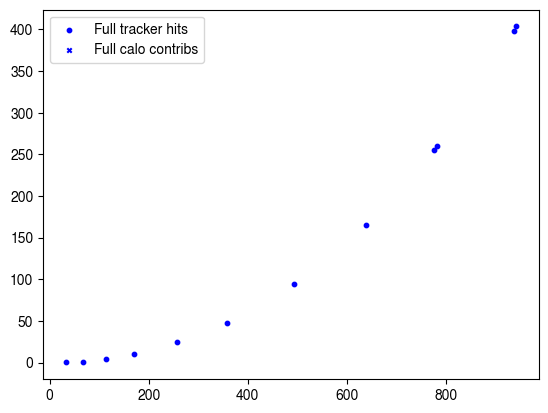

In [ ]:
plt.scatter(full_tracker_df[full_tracker_df.particle_id == 7244].x, full_tracker_df[full_tracker_df.particle_id == 7244].y, c="blue", s=10, label="Full tracker hits")
plt.scatter(full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244].x, full_calo_contrib_df[full_calo_contrib_df.particle_id == 7244].y, c="blue", marker="x", s=10, label="Full calo contribs")
# plt.scatter(full_tracker_df[tracker_df.particle_id == 8749].x, full_tracker_df[tracker_df.particle_id == 8749].y, c="red", s=1, label="Skimmed tracker hits")
plt.legend()
plt.show()

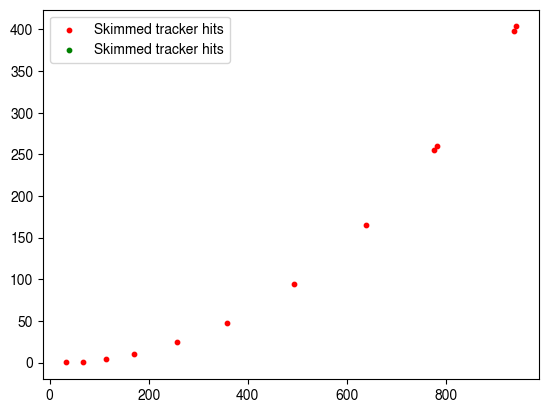

In [ ]:
plt.scatter(full_tracker_df[tracker_df.particle_id == 7244].x, full_tracker_df[tracker_df.particle_id == 7244].y, c="red", s=10, label="Skimmed tracker hits")
plt.scatter(full_tracker_df[tracker_df.particle_id == 8749].x, full_tracker_df[tracker_df.particle_id == 8749].y, c="green", s=10, label="Skimmed tracker hits")
plt.legend()
plt.show()

In [ ]:
tracker_df.loc[552].particle_id, full_tracker_df.loc[552].particle_id

(np.int32(8749), np.int32(7244))

In [ ]:
skimmed_to_full_id_map[8749]

KeyError: 8749

In [ ]:
full_ancestors = list(nx.ancestors(G, 7244))
full_descendants = list(nx.descendants(G, 7244))
skimmed_ancestors = list(nx.ancestors(skimmed_G, 7244))
skimmed_descendants = list(nx.descendants(skimmed_G, 7244))

In [ ]:
full_ancestors

[np.int64(6918),
 np.int64(6919),
 np.int64(6927),
 np.int64(6930),
 np.int64(6932),
 np.int64(6933),
 np.int64(6947),
 np.int64(6955),
 np.int64(6958),
 np.int64(6960),
 np.int64(6974),
 np.int64(6984),
 np.int64(6989),
 np.int64(6990),
 np.int64(6992),
 np.int64(6993),
 np.int64(6995),
 np.int64(6996),
 np.int64(6998),
 np.int64(7000),
 np.int64(7001),
 np.int64(7002),
 np.int64(7003),
 np.int64(7004),
 np.int64(7005),
 np.int64(7006),
 np.int64(7007),
 np.int64(7008),
 np.int64(7009),
 np.int64(7010),
 np.int64(7011),
 np.int64(7012),
 np.int64(7013),
 np.int64(7014),
 np.int64(7015),
 np.int64(7016),
 np.int64(7017),
 np.int64(7018),
 np.int64(7019),
 np.int64(7020),
 np.int64(7021),
 np.int64(7022),
 np.int64(7027)]

In [ ]:
skimmed_ancestors

[np.int64(6918),
 np.int64(6919),
 np.int64(6927),
 np.int64(6930),
 np.int64(6932),
 np.int64(6933),
 np.int64(6947),
 np.int64(6955),
 np.int64(6958),
 np.int64(6960),
 np.int64(6974),
 np.int64(6984),
 np.int64(6989),
 np.int64(6990),
 np.int64(6992),
 np.int64(6993),
 np.int64(6995),
 np.int64(6996),
 np.int64(6998),
 np.int64(7000),
 np.int64(7001),
 np.int64(7002),
 np.int64(7003),
 np.int64(7004),
 np.int64(7005),
 np.int64(7006),
 np.int64(7007),
 np.int64(7008),
 np.int64(7009),
 np.int64(7010),
 np.int64(7011),
 np.int64(7012),
 np.int64(7013),
 np.int64(7014),
 np.int64(7015),
 np.int64(7016),
 np.int64(7017),
 np.int64(7018),
 np.int64(7019),
 np.int64(7020),
 np.int64(7021),
 np.int64(7022),
 np.int64(7027)]

In [ ]:
full_descendants

[np.int64(417792),
 np.int64(417793),
 np.int64(417794),
 np.int64(417795),
 np.int64(417796),
 np.int64(417797),
 np.int64(417798),
 np.int64(417799),
 np.int64(417800),
 np.int64(417801),
 np.int64(417802),
 np.int64(417803),
 np.int64(417804),
 np.int64(417805),
 np.int64(417806),
 np.int64(417807),
 np.int64(417808),
 np.int64(417809),
 np.int64(417810),
 np.int64(417811),
 np.int64(417812),
 np.int64(417813),
 np.int64(417814),
 np.int64(417815),
 np.int64(417816),
 np.int64(417817),
 np.int64(417818),
 np.int64(417819),
 np.int64(417820),
 np.int64(417821),
 np.int64(417822),
 np.int64(417823),
 np.int64(417824),
 np.int64(417825),
 np.int64(417826),
 np.int64(417827),
 np.int64(417828),
 np.int64(417829),
 np.int64(417830),
 np.int64(417831),
 np.int64(417832),
 np.int64(417833),
 np.int64(417834),
 np.int64(417835),
 np.int64(417836),
 np.int64(417837),
 np.int64(417838),
 np.int64(417839),
 np.int64(417840),
 np.int64(417841),
 np.int64(417842),
 np.int64(417843),
 np.int64(41

In [ ]:
skimmed_descendants

[np.int64(33709),
 np.int64(33710),
 np.int64(33711),
 np.int64(33712),
 np.int64(33713),
 np.int64(33714),
 np.int64(33715),
 np.int64(33716),
 np.int64(33717),
 np.int64(33718),
 np.int64(33719),
 np.int64(33720),
 np.int64(33721),
 np.int64(33722),
 np.int64(33723),
 np.int64(33724),
 np.int64(33725),
 np.int64(33726),
 np.int64(33727),
 np.int64(33728),
 np.int64(33729),
 np.int64(33730),
 np.int64(33731),
 np.int64(33732),
 np.int64(33733),
 np.int64(33734),
 np.int64(33735),
 np.int64(33736),
 np.int64(33737),
 np.int64(33738),
 np.int64(33739),
 np.int64(33740),
 np.int64(33741),
 np.int64(33742),
 np.int64(33743),
 np.int64(33744),
 np.int64(33745),
 np.int64(33746),
 np.int64(33747),
 np.int64(33748),
 np.int64(33749),
 np.int64(33750),
 np.int64(33751),
 np.int64(33752),
 np.int64(33753)]

In [ ]:
full_particles_df.iloc[10452:10457]

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi,particle_id
10452,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,0.446525,...,1221.201398,29912,29913,33489,33490,0.689975,0.831864,0.630807,0.866941,10452
10453,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,-0.379689,...,2195.945842,29913,29914,33490,33490,0.468677,0.633692,0.816296,2.515170,10453
10454,2112,0,1224736768,0.0,1.829779,0.939565,1042.386170,521.639485,1062.809105,0.435368,...,1016.248028,29914,29915,33490,33490,0.514944,0.522165,-0.167270,-0.563359,10454
10455,2112,0,1224736768,0.0,3.205688,0.939565,1189.700345,688.873067,1221.201398,-0.092400,...,1233.959549,29915,29916,33490,33491,0.479266,0.556852,0.561597,1.764806,10455
10456,2112,0,1224736768,0.0,3.369621,0.939565,1185.542528,710.034446,1233.959549,-0.201264,...,1370.470362,29916,29917,33491,33491,0.202826,0.475478,1.496167,3.017401,10456


In [ ]:
skimmed_descendants

[]

In [ ]:
list(nx.descendants(skimmed_G, 7244))

[np.int64(8749)]

In [ ]:
full_particles_df.loc[417098]

PDG                2.112000e+03
generatorStatus    0.000000e+00
simulatorStatus    1.207960e+09
charge             0.000000e+00
time               2.519624e+00
mass               9.395654e-01
vx                 1.052720e+03
vy                 5.229406e+02
vz                 1.070684e+03
px                -2.867418e-02
py                 7.706964e-03
pz                -4.261910e-02
endpoint_x        -4.706979e+02
endpoint_y         6.591991e+02
endpoint_z         4.823788e+02
parents_begin      4.365580e+05
parents_end        4.365590e+05
daughters_begin    5.125450e+05
daughters_end      5.125500e+05
pt                 2.969185e-02
p                  5.194222e-02
eta               -1.158376e+00
phi                2.879021e+00
particle_id        4.170980e+05
Name: 417098, dtype: float64

In [ ]:
daughters_df.iloc[24783]

particle_id           8749
collectionID    2714477136
parent_id             7244
Name: 24783, dtype: int64

In [ ]:
particles_df.loc[8749]

PDG                2.112000e+03
generatorStatus    0.000000e+00
simulatorStatus    2.013266e+09
charge             0.000000e+00
time               2.519624e+00
mass               9.395654e-01
vx                 1.052720e+03
vy                 5.229406e+02
vz                 1.070684e+03
px                -2.867418e-02
py                 7.706964e-03
pz                -4.261910e-02
endpoint_x        -4.706979e+02
endpoint_y         6.591991e+02
endpoint_z         4.823788e+02
parents_begin      2.820900e+04
parents_end        2.821000e+04
daughters_begin    2.915600e+04
daughters_end      2.915600e+04
pt                 2.969185e-02
p                  5.194222e-02
eta               -1.158376e+00
phi                2.879021e+00
particle_id        8.749000e+03
Name: 8749, dtype: float64

In [ ]:
particles_df.loc[7244]

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    8.388608e+07
charge            -1.000000e+00
time              -3.596635e+00
mass               1.395700e-01
vx                 2.814718e-02
vy                 3.564536e-03
vz                -2.539741e+00
px                 7.736642e-01
py                -7.548373e-03
pz                 6.827099e-01
endpoint_x         1.042386e+03
endpoint_y         5.216395e+02
endpoint_z         1.062809e+03
parents_begin      2.374600e+04
parents_end        2.374700e+04
daughters_begin    2.478300e+04
daughters_end      2.478400e+04
pt                 7.737010e-01
p                  1.031846e+00
eta                7.957238e-01
phi               -9.756344e-03
particle_id        7.244000e+03
Name: 7244, dtype: float64

In [ ]:
full_particles_df.loc[7244]

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    1.509949e+08
charge            -1.000000e+00
time              -3.596635e+00
mass               1.395700e-01
vx                 2.814718e-02
vy                 3.564536e-03
vz                -2.539741e+00
px                 7.736642e-01
py                -7.548373e-03
pz                 6.827099e-01
endpoint_x         1.042386e+03
endpoint_y         5.216395e+02
endpoint_z         1.062809e+03
parents_begin      2.374600e+04
parents_end        2.374700e+04
daughters_begin    2.724700e+04
daughters_end      2.725000e+04
pt                 7.737010e-01
p                  1.031846e+00
eta                7.957238e-01
phi               -9.756344e-03
particle_id        7.244000e+03
Name: 7244, dtype: float64

In [ ]:
skimmed_to_full_id_map[7244]

7244

In [ ]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,...,particle_id,r,R,phi,theta,eta,pt,detector,processed_id,skimmed_id
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,...,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout,8352,8352.0
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,...,8468,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout,8468,8468.0
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,...,8467,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout,8467,8467.0
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,...,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout,8350,8350.0
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,...,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout,8347,8347.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,1073741824,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,...,30324,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout,30313,30313.0
21549,15749646188894,20.597553,0.124870,1073741824,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,...,30332,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout,30322,NaN
21550,16333760692558,22.928253,0.125527,1073741824,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,...,30332,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout,30322,NaN
21551,1554779373662,26.342630,0.032734,1073741824,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,...,30335,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout,30322,30322.0


In [ ]:
duplicates = full_particles_df[full_particles_df.duplicated(subset=["vx", "vy", "vz", "px", "py", "pz", "mass", "time", "charge", "PDG"], keep=False)]


In [ ]:
# Check if duplicates left hits
full_tracker_df[full_tracker_df.particle_id.isin(duplicates.index)]

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector,processed_id


In [ ]:
# Check if duplicates left hits
full_calo_contrib_df[full_calo_contrib_df.particle_id.isin(duplicates.index)]

,PDG,energy,time,step_x,step_y,step_z,particle_id,cellID,x,y,z,detector


In [ ]:
full_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30392,11,0,1224736768,-1.000000,18.987364,0.000511,-256.810462,1259.268982,2897.654381,-0.014434,...,1259.642684,2913.530223,49852,49853,49855,49856,0.072863,0.184257,1.579285,1.770208
30393,-11,0,1224736768,1.000000,18.987364,0.000511,-256.810462,1259.268982,2897.654381,-0.011995,...,1260.790231,2910.989339,49853,49854,49856,49856,0.055590,0.143103,1.598637,1.788277
30394,22,0,1493172224,0.000000,19.005100,0.000000,-256.981303,1261.157314,2902.621089,-0.000295,...,1263.273587,2908.342965,49854,49855,49856,49857,0.057090,0.164575,1.720342,1.575962
30395,-11,0,1224736768,1.000000,19.025450,0.000511,-256.992234,1263.273587,2908.342965,-0.000120,...,1270.008773,2933.174926,49855,49856,49857,49857,0.052210,0.149162,1.710773,1.573097


Now, let's look to see if the incidentParentID lines up with the particles in event.
Start by getting all the hits in a particle with hits in the tracker AND calo.

In [ ]:
particles_df = event["particles_df"]
calo_df = event["calo_contrib_df"]
tracker_df = event["tracker_df"]
particles_with_calo_hits = calo_df.particle_id.unique()
particles_with_tracker_hits = tracker_df.particle_id.unique()
particles_with_hits = np.intersect1d(particles_with_calo_hits, particles_with_tracker_hits)
sample_particle = np.random.choice(particles_with_hits)
sample_particle_df = particles_df.loc[sample_particle]


In [ ]:
sample_particle_df

PDG               -2.110000e+02
generatorStatus    1.000000e+00
simulatorStatus    8.388608e+07
charge            -1.000000e+00
time              -8.515367e+00
mass               1.395700e-01
vx                -2.742718e-02
vy                 2.047749e-02
vz                -8.378056e+00
px                 3.823615e-01
py                -9.209523e-02
pz                 4.229099e-01
endpoint_x         5.922598e+02
endpoint_y         1.188056e+03
endpoint_z         1.825446e+03
parents_begin      1.327900e+04
parents_end        1.328000e+04
daughters_begin    1.361700e+04
daughters_end      1.361700e+04
pt                 3.932962e-01
p                  5.775246e-01
eta                9.336267e-01
phi               -2.363571e-01
Name: 3939, dtype: float64

In [ ]:
sample_particle_calo_hits = calo_df[calo_df.particle_id == sample_particle]

In [ ]:
sample_particle_tracker_hits = tracker_df[tracker_df.particle_id == sample_particle]

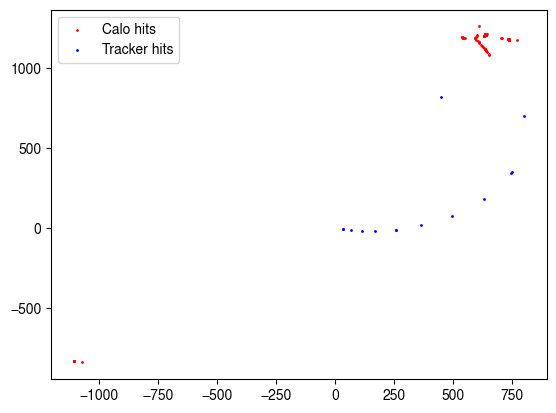

In [ ]:
plt.scatter(sample_particle_calo_hits.x, sample_particle_calo_hits.y, c="red", s=1, label="Calo hits")
plt.scatter(sample_particle_tracker_hits.x, sample_particle_tracker_hits.y, c="blue", s=1, label="Tracker hits")
plt.legend()
plt.show()

In [ ]:
full_particles_df

,PDG,generatorStatus,simulatorStatus,charge,time,mass,vx,vy,vz,px,...,endpoint_y,endpoint_z,parents_begin,parents_end,daughters_begin,daughters_end,pt,p,eta,phi
0,2212,4,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,0.000000,...,-0.005813,-105.372111,0,0,0,15,0.000000,6999.999937,inf,0.000000
1,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,2.672720,...,-0.005813,-105.372111,0,1,15,16,2.682210,2607.457556,7.572637,-0.084146
2,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.115590,...,-0.005813,-105.372111,1,2,16,17,0.498858,376.885189,7.320521,-1.804631
3,21,61,0,0.000000,8.091558,0.000000,0.003543,-0.005813,-105.372111,-0.391733,...,-0.005813,-105.372111,2,3,17,18,1.721345,267.841489,5.740426,-1.800382
4,1,61,0,-0.333333,8.091558,0.000000,0.003543,-0.005813,-105.372111,3.310610,...,-0.005813,-105.372111,3,4,18,19,3.345098,155.382063,4.531422,0.143721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
761748,11,0,1493172224,-1.000000,18.976517,0.000511,-258.027782,1258.587714,2894.249881,-0.000801,...,1258.624261,2894.282049,781208,781209,781213,781213,0.000825,0.001543,1.237925,2.897669
761749,11,0,1224736768,-1.000000,19.009468,0.000511,-253.705155,1264.753188,2900.644315,0.000872,...,1264.782095,2900.667475,781209,781210,781213,781213,0.001294,0.001504,0.561900,0.831355
761750,11,0,1493172224,-1.000000,18.923120,0.000511,-256.154790,1252.674619,2879.452487,-0.000060,...,1252.947183,2879.439595,781210,781211,781213,781213,0.003275,0.004671,0.893106,1.589054
761751,11,0,1493172224,-1.000000,18.925692,0.000511,-256.377062,1252.815231,2880.177064,-0.001575,...,1252.836941,2880.923638,781211,781212,781213,781213,0.001690,0.004967,1.740621,2.770165


I guess because this is a generator particle, it's very similar between the full and trimmed event.

In [ ]:
full_particles_df.loc[sample_particle] == sample_particle_df

PDG                 True
generatorStatus     True
simulatorStatus    False
charge              True
time                True
mass                True
vx                  True
vy                  True
vz                  True
px                  True
py                  True
pz                  True
endpoint_x          True
endpoint_y          True
endpoint_z          True
parents_begin       True
parents_end         True
daughters_begin    False
daughters_end      False
pt                  True
p                   True
eta                 True
phi                 True
Name: 3939, dtype: bool

In [ ]:
descendants = list(nx.descendants(G, sample_particle))

In [ ]:
full_tracker_df

,cellID,time,pathLength,quality,x,y,z,px,py,pz,EDep,particle_id,r,R,phi,theta,eta,pt,detector
0,70438988367857670,5.965323,1.323336,0,-32.387418,1.662442,-403.378270,-0.327436,0.026107,-3.389788,0.000621,8352,32.430056,404.679796,3.090308,3.061369,-3.215548,0.328476,PixelBarrelReadout
1,12472937214974998,5.850329,0.600617,0,48.633578,-47.682691,-363.285304,0.021487,-0.041030,-0.198755,0.000209,8893,68.109206,369.614767,-0.775526,2.956263,-2.375897,0.046315,PixelBarrelReadout
2,10167862626950422,5.872139,0.568466,0,54.373627,-42.464137,-369.909179,0.138421,-0.088689,-0.723106,0.000167,8892,68.990537,376.287782,-0.663029,2.957204,-2.381020,0.164396,PixelBarrelReadout
3,65108912478751750,5.773998,1.102025,0,2.459692,-31.890374,-346.003253,0.030565,-0.490668,-4.293781,0.000387,8350,31.985091,347.478485,-1.493819,3.049413,-3.076455,0.491619,PixelBarrelReadout
4,67660045743228678,5.510508,0.788981,0,-31.236043,6.956853,-266.608993,-0.351317,0.089458,-2.260428,0.000236,8347,32.001378,268.522706,2.922451,3.022133,-2.816734,0.362528,PixelBarrelReadout
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21548,16329466777950,21.203285,0.041919,1073741824,-600.486383,712.145458,3009.437093,-0.000046,-0.000026,-0.000127,0.000069,759109,931.522973,3150.308979,2.271334,0.300180,1.888970,0.000052,LongStripEndcapReadout
21549,15749646188894,20.597553,0.124870,0,-454.044896,916.336486,3020.376044,0.000130,-0.000416,-0.000175,0.000041,759149,1022.657970,3188.808675,2.030838,0.326471,1.803625,0.000435,LongStripEndcapReadout
21550,16333760692558,22.928253,0.125527,0,-462.682351,888.891570,2625.625000,-0.000365,0.000189,0.000105,0.000149,759149,1002.099387,2810.357597,2.050722,0.364598,1.690943,0.000411,LongStripEndcapReadout
21551,1554779373662,26.342630,0.032734,1073741824,463.756306,-695.160774,2990.604977,0.000071,-0.000099,-0.000032,0.000058,759241,835.654482,3105.162885,-0.982479,0.272477,1.987135,0.000121,LongStripEndcapReadout


In [ ]:
full_calo_hit_df

,cellID,energy,x,y,z,contribution_begin,contribution_end,r,R,phi,theta,eta,detector
0,18428729469050290192,6.279467e-07,737.476990,-1083.676514,-331.500000,0,1,1310.811523,1352.079590,-0.973256,1.818499,-0.250276,ECalBarrelCollection
1,18300095628031993872,2.059417e-04,-1205.247070,-521.310486,-2657.100098,1,2,1313.158447,2963.876953,-2.733358,2.682590,-1.454070,ECalBarrelCollection
2,18300658513560807440,1.595900e-05,-1220.525635,-444.836060,-2652.000000,2,3,1299.062012,2953.077393,-2.792092,2.686104,-1.462030,ECalBarrelCollection
3,28710275835123728,2.549791e-04,719.923035,1204.970337,515.099976,3,14,1403.653320,1495.182495,1.032246,1.219083,0.359197,ECalBarrelCollection
4,28710280130091024,6.176600e-05,715.211243,1206.921997,515.099976,14,17,1402.921143,1494.495239,1.035842,1.218915,0.359377,ECalBarrelCollection
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173370,19421781989294356,7.089448e-05,-344.989838,2041.930908,3647.500000,744773,744774,2070.869141,4194.372070,1.738168,0.516369,1.331509,HCalEndcapCollection
173371,16044086563733780,1.605069e-05,-245.333771,1694.700928,3647.500000,744774,744776,1712.366821,4029.448486,1.714563,0.438921,1.500346,HCalEndcapCollection
173372,16044095153701140,1.264276e-03,-186.486664,1706.406372,3698.500000,744776,744779,1716.566284,4077.438232,1.679651,0.434538,1.510708,HCalEndcapCollection
173373,15199674518503700,1.098509e-04,-139.504974,1623.988403,3647.500000,744779,744780,1629.969360,3995.129150,1.656489,0.420251,1.545180,HCalEndcapCollection


In [ ]:
sample_tracker_hits = full_tracker_df[full_tracker_df.particle_id == sample_particle]
sample_calo_contribs = full_calo_contrib_df[full_calo_contrib_df.particle_id == sample_particle]
descendant_tracker_hits = full_tracker_df[full_tracker_df.particle_id.isin(descendants)]
descendant_calo_contribs = full_calo_contrib_df[full_calo_contrib_df.particle_id.isin(descendants)]


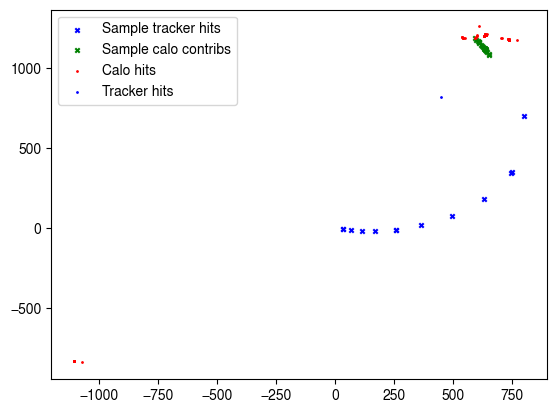

In [ ]:
plt.scatter(sample_tracker_hits.x, sample_tracker_hits.y, c="blue", label="Sample tracker hits", marker="x", s=10)
plt.scatter(sample_calo_contribs.x, sample_calo_contribs.y, c="green", label="Sample calo contribs", marker="x", s=10)
plt.scatter(descendant_calo_contribs.x, descendant_calo_contribs.y, c="red", s=1, label="Calo hits")
plt.scatter(descendant_tracker_hits.x, descendant_tracker_hits.y, c="blue", s=1, label="Tracker hits")
plt.legend()
plt.show()

In [ ]:
descendants

[np.int64(302080),
 np.int64(302081),
 np.int64(302082),
 np.int64(302083),
 np.int64(302084),
 np.int64(302085),
 np.int64(302086),
 np.int64(302087),
 np.int64(302088),
 np.int64(302089),
 np.int64(302090),
 np.int64(302091),
 np.int64(302092),
 np.int64(302093),
 np.int64(302094),
 np.int64(302095),
 np.int64(302096),
 np.int64(302097),
 np.int64(302098),
 np.int64(302099),
 np.int64(302100),
 np.int64(302101),
 np.int64(302102),
 np.int64(302103),
 np.int64(302104),
 np.int64(302105),
 np.int64(302106),
 np.int64(302107),
 np.int64(302108),
 np.int64(302109),
 np.int64(302110),
 np.int64(302111),
 np.int64(302112),
 np.int64(302113),
 np.int64(302114),
 np.int64(302115),
 np.int64(302116),
 np.int64(302117),
 np.int64(302118),
 np.int64(302119),
 np.int64(302120),
 np.int64(302121),
 np.int64(302122),
 np.int64(302123),
 np.int64(302124),
 np.int64(302125),
 np.int64(302126),
 np.int64(302127),
 np.int64(302128),
 np.int64(302129),
 np.int64(302130),
 np.int64(302131),
 np.int64(30

In [ ]:
node_df[node_df.incidentParentID == sample_particle]

,energy,decay_vertex_x,decay_vertex_y,decay_vertex_z,particleID,collapsedParticleID,incidentParentID
3939,0.577525,-0.027427,0.020477,-8.378056,3939,3939,3939
302041,0.008427,735.423969,922.254939,1546.146848,302041,302041,3939
302042,0.001697,724.253363,948.519865,1574.368613,302042,302042,3939
302043,0.001453,718.347217,960.063721,1587.487310,302043,302043,3939
302044,0.002825,653.894903,1084.095956,1725.208386,302044,302044,3939
...,...,...,...,...,...,...,...
302147,0.009045,612.431216,1259.753189,1961.972472,302147,302147,3939
302148,0.001447,613.243529,1259.540283,1965.410309,302148,302148,3939
302149,0.002694,594.971185,1199.586193,1848.224244,302149,302149,3939
302150,0.007338,595.585024,1194.737306,1840.918523,302150,302150,3939


In [ ]:
list(node_df[node_df.incidentParentID == sample_particle].particleID)

[3939,
 302041,
 302042,
 302043,
 302044,
 302045,
 302046,
 302047,
 302048,
 302049,
 302050,
 302051,
 302052,
 302053,
 302054,
 302055,
 302056,
 302057,
 302058,
 302059,
 302060,
 302061,
 302062,
 302063,
 302064,
 302065,
 302066,
 302067,
 302068,
 302069,
 302070,
 302071,
 302072,
 302073,
 302074,
 302075,
 302076,
 302077,
 302078,
 302079,
 302080,
 302081,
 302082,
 302083,
 302084,
 302085,
 302086,
 302087,
 302088,
 302089,
 302090,
 302091,
 302092,
 302093,
 302094,
 302095,
 302096,
 302097,
 302098,
 302099,
 302100,
 302101,
 302102,
 302103,
 302104,
 302105,
 302106,
 302107,
 302108,
 302109,
 302110,
 302111,
 302112,
 302113,
 302114,
 302115,
 302116,
 302117,
 302118,
 302119,
 302120,
 302121,
 302122,
 302123,
 302124,
 302125,
 302126,
 302127,
 302128,
 302129,
 302130,
 302131,
 302132,
 302133,
 302134,
 302135,
 302136,
 302137,
 302138,
 302139,
 302140,
 302141,
 302142,
 302143,
 302144,
 302145,
 302146,
 302147,
 302148,
 302149,
 302150,
 30

In [ ]:
# Check that there is overlap between the descendant list and the node_df - ADD in the original particle to descendants!
len(np.intersect1d(descendants+[sample_particle], list(node_df[node_df.incidentParentID == sample_particle].particleID)))


112

In [ ]:
len(descendants), len(list(node_df[node_df.incidentParentID == sample_particle].particleID))


(113, 112)

In [ ]:
accuracy = len(np.intersect1d(descendants+[sample_particle], list(node_df[node_df.incidentParentID == sample_particle].particleID))) / len(descendants+[sample_particle])

In [ ]:
accuracy

0.9824561403508771

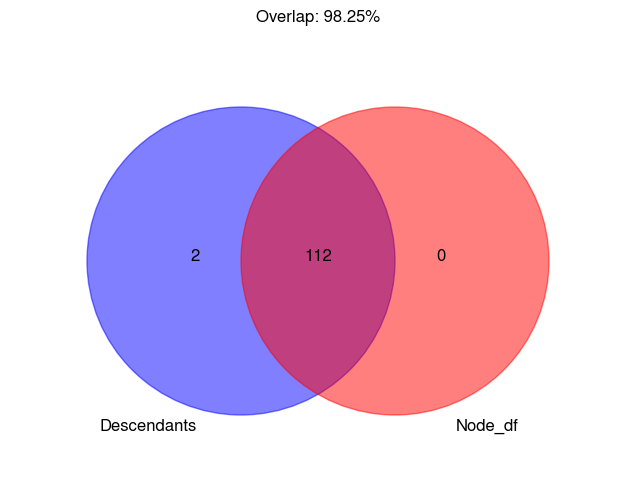

In [ ]:
# Make a venn diagram of the overlap between the descendant list and the node_df using matplotlib patches
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

# Get the sets
set1 = set(descendants+[sample_particle])
set2 = set(node_df[node_df.incidentParentID == sample_particle].particleID)
intersection = set1.intersection(set2)

# Calculate non-intersecting parts
only_in_set1 = set1 - intersection
only_in_set2 = set2 - intersection

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create two circles
circle1 = Circle((-0.5, 0), 1, alpha=0.5, fc=to_rgba('blue', 0.4), ec='blue', label='Descendants')
circle2 = Circle((0.5, 0), 1, alpha=0.5, fc=to_rgba('red', 0.4), ec='red', label='Node_df')

# Add circles to the plot
ax.add_patch(circle1)
ax.add_patch(circle2)

# Add text labels with counts of non-intersecting and intersecting parts
ax.text(-0.8, 0, f"{len(only_in_set1)}", fontsize=12, ha='center')
ax.text(0.8, 0, f"{len(only_in_set2)}", fontsize=12, ha='center')
ax.text(0, 0, f"{len(intersection)}", fontsize=12, ha='center')

# Add set labels
ax.text(-1.1, -1.1, "Descendants", fontsize=12, ha='center')
ax.text(1.1, -1.1, "Node_df", fontsize=12, ha='center')

# Set axis limits and remove ticks
ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.axis('off')

# Add title showing overlap percentage
ax.set_title(f"Overlap: {len(intersection)/len(set1):.2%}")

plt.show()
